# Predicting 30-Day Readmission Risk for Hospitalised Diabetic Patients

**AI for Healthcare (AI4HC) — Group Assignment 1 · Responsible AI Toolbox**
IE University, September 2026

---

# 1. Introduction

## 1.1 The clinical question

> *At the moment of hospital discharge, which adult and paediatric diabetic inpatients are at highest
> risk of being readmitted within 30 days, so that a limited transitional-care team can prioritise
> them for a post-discharge intervention?*

Around one in nine diabetic inpatient stays in this dataset ends with the patient coming back within
30 days. Many of those returns are considered preventable with better discharge planning: medication
reconciliation, diabetes education, an early follow-up call and a timely clinic appointment. The
problem is capacity. A transitional-care team cannot phone every discharged patient, so somebody has
to decide who gets the extra help. Today that decision is made informally. This notebook asks whether
a model can make it more consistent.

## 1.2 The decision context

**Index time (the moment of prediction).** The day of discharge. Only information available at or
before discharge may be used. Every field in this dataset satisfies that rule: the variables describe
the stay that is ending (diagnoses, procedures, medications, length of stay) or the year preceding it
(prior outpatient, emergency and inpatient visits). `discharge_disposition_id` is known at discharge
by definition.

**The user.** A discharge-planning nurse or transitional-care coordinator.

**The workflow.**

`risk score computed at discharge` → `alert if score ≥ locked threshold` → `structured transitional-care review`
→ `medication reconciliation · diabetes education · follow-up call within 7 days · early clinic appointment`

**What the alert is, and is not.** The alert is decision support. It is **not** a diagnosis, and it
must never delay a discharge, deny care, or override clinical judgement. A nurse who believes a
patient needs support gives that support whether or not the model agrees. Accountability stays with
the clinical team. Following the transparency principles that regulators such as the FDA apply to
clinical decision-support software, the basis of each score should be inspectable by the clinician
who acts on it — which is one reason this notebook prefers a model whose coefficients can be read.

**Why it matters.** Thirty-day readmission is a funded quality metric. Strack et al. (2014) chose the
30-day window precisely because funding agencies use it. Readmissions are expensive for hospitals,
disruptive for patients, and partly preventable.

## 1.3 Target population

Inpatient encounters where diabetes was coded as any diagnosis, length of stay between 1 and 14 days,
laboratory tests performed and medication administered — the extraction criteria used by the source
paper. We **exclude** encounters ending in death or hospice transfer, because those patients cannot be
meaningfully readmitted and including them would corrupt the label.

## 1.4 Success criteria — written down *before* any modelling

These are the bars we agreed to judge the model against. They are recorded here so that the results
section cannot quietly move them.

| Dimension | Pre-specified criterion |
| :--- | :--- |
| **Discrimination** | Validation PR-AUC clearly above prevalence (≈ 0.11) and ROC-AUC ≥ 0.65. Published models on this dataset typically reach 0.65–0.70; we set expectations honestly. |
| **Calibration** | Calibrated Brier score below the prevalence-only baseline, and a reliability curve close to the diagonal. |
| **Operating point** | Recall ≥ 50% of readmissions while flagging ≤ 250 patients per 1,000 discharges. |
| **Fairness** | No subgroup (race, sex, age band, payer group) with recall or false-positive rate more than 10 percentage points from the overall value without a documented mitigation. |

## 1.5 Potential harms

- **False negative (a missed readmission).** The patient goes home without extra support. Avoidable
  readmission, possible deterioration, cost to the patient and the system. This is the harm the model
  exists to reduce.
- **False positive (an unnecessary alert).** Wasted nurse time, alert fatigue, and burden on a patient
  who receives calls and appointments they did not need. Low direct clinical harm, but a real capacity
  cost — and alert fatigue degrades the whole tool.
- **Equity harm.** If the model systematically under-flags a group, that group systematically receives
  less transitional care. Payer code is a socioeconomic proxy: using it as an input risks encoding
  access-to-care inequities as if they were clinical risk. We audit this explicitly in Sections 8 and 9.
- **Automation bias.** Clinicians may over-trust a number on a screen. The mitigation is presentation
  (show the reasons, not just the score) and governance (human override always available).



# 2. Dataset characteristics

## 2.1 Source and provenance

| Item | Detail |
| :--- | :--- |
| **Dataset** | Diabetes 130-US Hospitals for Years 1999–2008 |
| **Repository** | UCI Machine Learning Repository |
| **Source system** | Cerner Health Facts electronic health record database |
| **Coverage** | 130 US hospitals and integrated delivery networks, 10 years (1999–2008) |
| **Reference paper** | Strack B. *et al.* (2014), "Impact of HbA1c Measurement on Hospital Readmission Rates", *BioMed Research International*, Article ID 781670 (open access, CC BY) |
| **Local copy** | `docs/Strack2014_description.pdf` |
| **Raw size** | 101,766 encounters × 50 columns, 71,518 unique patients |

Each row is one **inpatient encounter**, not one patient. Many patients appear several times. That
single fact drives the most important design decision in this notebook (Section 5).


## 2.2 The target

`readmitted` takes three values in the raw file: `"<30"`, `">30"` and `"NO"`. We define

```
readmit_30d = 1  if readmitted == "<30"
readmit_30d = 0  if readmitted in {">30", "NO"}
```

This matches the paper and the funders' 30-day metric. Note what it means: a patient readmitted on day
45 is a **negative**. We are not modelling "ever returns", we are modelling "returns inside the window
that the quality metric counts".

## 2.3 Label quality — the caveat that matters most

Readmission is only observed **within the same health network**. A patient discharged from hospital A
who is readmitted to an unrelated hospital B is recorded as *not readmitted*. The label therefore
**under-counts** readmissions, and it under-counts them unevenly: patients with stable insurance and a
regular provider are more likely to return to the same network and be captured. Two consequences
follow, and both are real limitations rather than fixable bugs:

1. Every recall figure in this notebook is recall against *recorded* readmissions, which is an
   optimistic denominator.
2. The under-counting may correlate with payer and race, which means part of any measured subgroup
   gap could be a *measurement* artefact rather than a model failure.

## 2.4 The `"None"` trap in the HbA1c column

`A1Cresult` and `max_glu_serum` use the literal string `"None"` to mean **the test was not performed**.
That is clinically meaningful — it is the exposure variable in the paper's central finding — and it is
*not* a missing value. Pandas converts the string `"None"` to `NaN` by default, silently destroying it.
Every load in this project therefore uses:

```python
pd.read_csv(path, keep_default_na=False, na_values=["?"], low_memory=False)
```

and asserts that `"None"` survived. In this file `"?"` is the genuine missing marker.

In [1]:
   import os
   os.makedirs("data/raw", exist_ok=True)
   os.makedirs("outputs/tables", exist_ok=True)

# 3. Setup

Imports, helper functions and the optional Responsible AI stack. Every helper lives in `utils.py` and
every constant in `config.py`, so this notebook stays readable and nothing is hard-coded twice.

In [2]:
# Reserve names so the later Responsible AI cells have explicit placeholders
train_df_rai = None
test_df_rai = None
feature_metadata = None

import sys
import time
import warnings
from pathlib import Path

# Run from the repository root so `import utils` and `import config` resolve
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import GroupKFold, GridSearchCV, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    confusion_matrix, accuracy_score,
)

import config
import utils
from utils import (
    positive_scores,
    auc_report,
    tradeoff_table,
    pick_threshold_cost,
    pick_threshold_recall_floor,
    pick_threshold_workload,
    summary_at_threshold,
    wilson_interval,
    plot_recall_floor_curves,
    plot_cumulative_recall_at_threshold,
    plot_topk_at_threshold,
    make_thresholded_estimator,
    init_rai_dependencies,
)

# Check which optional Responsible AI components are installed
rai_flags, rai_objects = init_rai_dependencies()
globals().update(rai_flags)
globals().update(rai_objects)

# Fix randomness everywhere it exists
RANDOM_STATE = config.RANDOM_STATE
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.width", 180)
plt.rcParams["figure.dpi"] = 110

print(
    f"Available components: RAI dashboard={_RAI}, interpretability={_INTERPRET}, "
    f"error analysis={_ERRANALYSIS}, fairness metrics={_FAIRLEARN}, "
    f"counterfactuals={_DICE}, causal inference={_ECONML}"
)

Available components: RAI dashboard=True, interpretability=True, error analysis=True, fairness metrics=True, counterfactuals=True, causal inference=True


# 4. Data load, cleaning and cohort construction

## 4.1 Loading the raw file safely

In [3]:
# The safe loader keeps the literal string "None" and treats only "?" as missing
df_raw = utils.load_raw(config.RAW_DATA_PATH)

print(f"Raw data: {df_raw.shape[0]:,} encounters and {df_raw.shape[1]} columns")
print(f"Unique patients: {df_raw['patient_nbr'].nunique():,}")

# Confirm the load did not destroy the clinically meaningful "None"
assert df_raw["A1Cresult"].isna().sum() == 0
assert "None" in set(df_raw["A1Cresult"].unique())
print('Check passed: "None" survived in A1Cresult (it means "test not performed")')

display(df_raw.head(5).iloc[:, :14].style.hide(axis="index"))

Raw data: 101,766 encounters and 50 columns
Unique patients: 71,518
Check passed: "None" survived in A1Cresult (it means "test not performed")


encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures
2278392,8222157,Caucasian,Female,[0-10),nan,6,25,1,1,nan,Pediatrics-Endocrinology,41,0
149190,55629189,Caucasian,Female,[10-20),nan,1,1,7,3,nan,nan,59,0
64410,86047875,AfricanAmerican,Female,[20-30),nan,1,1,7,2,nan,nan,11,5
500364,82442376,Caucasian,Male,[30-40),nan,1,1,7,2,nan,nan,44,1
16680,42519267,Caucasian,Male,[40-50),nan,1,1,7,1,nan,nan,51,0


In [4]:
# Raw target distribution, in counts and in the per-1,000 framing clinicians use
counts = df_raw["readmitted"].value_counts()
labels = {"<30": "Readmitted within 30 days", ">30": "Readmitted after 30 days", "NO": "Not readmitted"}

target_overview = pd.DataFrame({
    "Outcome": [labels[k] for k in counts.index],
    "Encounters": counts.values,
    "% of raw data": (counts.values / counts.sum() * 100),
    "Per 1,000 encounters": (counts.values / counts.sum() * 1000),
})
display(target_overview.style.hide(axis="index").format({
    "Encounters": "{:,.0f}", "% of raw data": "{:.2f}", "Per 1,000 encounters": "{:.1f}",
}))

raw_prevalence = (df_raw["readmitted"] == "<30").mean()
display(Markdown(
    f"In the raw extract **{raw_prevalence*100:.1f}%** of encounters are followed by a readmission "
    f"within 30 days — about **{raw_prevalence*1000:.0f} in every 1,000 discharges**. This is the "
    f"positive class we are trying to find. The other two categories both become negatives: a patient "
    f"who returns on day 45 does not count for the 30-day quality metric."
))

Outcome,Encounters,% of raw data,"Per 1,000 encounters"
Not readmitted,"54,864",53.91,539.1
Readmitted after 30 days,"35,545",34.93,349.3
Readmitted within 30 days,"11,357",11.16,111.6


In the raw extract **11.2%** of encounters are followed by a readmission within 30 days — about **112 in every 1,000 discharges**. This is the positive class we are trying to find. The other two categories both become negatives: a patient who returns on day 45 does not count for the 30-day quality metric.

> **So what?** Roughly **1 in 9** diabetic discharges is followed by a readmission inside 30 days.
> That number sets every expectation that follows. A model that simply predicted "nobody will be
> readmitted" would be right about 89% of the time and would be completely useless, because it would
> identify nobody to help. **Accuracy is the wrong metric here** — we will use precision, recall and
> PR-AUC, and we will translate all of them into alerts and missed patients per 1,000 discharges.

## 4.2 Missingness and how each column is handled

In [5]:
missing_table = utils.missingness_table(df_raw)
display(missing_table.style.hide(axis="index").format({"% missing": "{:.2f}"}))
utils.savetable(missing_table, "missingness_table")

display(Markdown(
    f"Only **{len(missing_table)} of {df_raw.shape[1]} columns** contain any missing values, but the "
    f"pattern matters more than the count: `weight` is **{missing_table.loc[missing_table['Column']=='weight','% missing'].iloc[0]:.1f}%** "
    f"missing and is dropped, while `payer_code` and `medical_specialty` are missing for a large "
    f"minority of encounters in a way that is almost certainly **not** random."
))

Column,% missing,Handling decision,Reason
weight,96.86,Dropped,96.9% missing - no usable signal
medical_specialty,49.08,"Kept, imputed as 'Missing'",Missingness is itself informative (which service admitted the patient)
payer_code,39.56,"Grouped into payer_group, 'Unknown' level",Not missing at random; used as a socioeconomic proxy and audited
race,2.23,"Kept for fairness audit only, not a model input","2.2% missing; used to measure gaps, not to score patients"
diag_3,1.40,Grouped by ICD-9 chapter; NaN -> 'Missing',Stateless rule-based grouping
diag_2,0.35,Grouped by ICD-9 chapter; NaN -> 'Missing',Stateless rule-based grouping
diag_1,0.02,Grouped by ICD-9 chapter; NaN -> 'Missing',Stateless rule-based grouping


Only **7 of 50 columns** contain any missing values, but the pattern matters more than the count: `weight` is **96.9%** missing and is dropped, while `payer_code` and `medical_specialty` are missing for a large minority of encounters in a way that is almost certainly **not** random.

> **So what?** Missingness here is information, not noise. A blank `medical_specialty` tells you
> something about how the admission was coded; a blank `payer_code` is more common for some kinds of
> patient than others. We therefore **keep** these columns with an explicit `"Missing"` category rather
> than deleting the rows, which would throw away a large and non-random slice of the cohort. Only
> `weight` is dropped, because at 97% missing there is nothing left to learn from.

## 4.3 Cohort construction (CONSORT-style flow)

Two exclusions, both decided before looking at any model output:

1. **Death or hospice discharge** (`discharge_disposition_id` ∈ {11, 13, 14, 19, 20, 21}). These
   patients cannot be readmitted, so leaving them in would add guaranteed negatives and make the model
   look better than it is. The source paper applies the same rule.
2. **Unknown/invalid gender** (3 encounters). Too few to analyse and they break the fairness views.

In [6]:
cohort, flow_table = utils.apply_cohort_rules(df_raw)

display(flow_table.style.hide(axis="index").format({
    "Encounters removed": "{:,.0f}",
    "Encounters remaining": "{:,.0f}",
    "Unique patients remaining": "{:,.0f}",
}))
utils.savetable(flow_table, "cohort_flow_table")

cohort_prevalence = utils.make_target(cohort).mean()
display(Markdown(
    f"**Analysis cohort: {len(cohort):,} encounters from {cohort['patient_nbr'].nunique():,} unique patients.** "
    f"The 30-day readmission rate is **{cohort_prevalence*100:.2f}%** "
    f"({cohort_prevalence*1000:.0f} per 1,000 discharges), slightly above the raw rate because the "
    f"excluded death and hospice encounters were all negatives by construction."
))

Step,Encounters removed,Encounters remaining,Unique patients remaining
All encounters in the UCI extract,0,"101,766","71,518"
Exclude discharge to death or hospice,"2,423","99,343","69,990"
Exclude unknown/invalid gender,3,"99,340","69,987"


**Analysis cohort: 99,340 encounters from 69,987 unique patients.** The 30-day readmission rate is **11.39%** (114 per 1,000 discharges), slightly above the raw rate because the excluded death and hospice encounters were all negatives by construction.

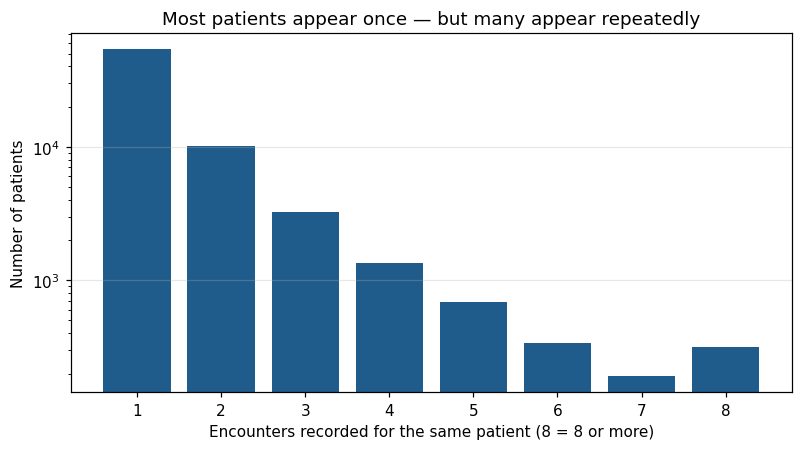

**16,341 patients (23.3%) have more than one encounter**, and the busiest single patient appears **40 times**. Those 29,353 repeat encounters are the single biggest leakage risk in this dataset.

In [7]:
# How often does the same patient appear more than once? This drives the split design.
encounters_per_patient = cohort["patient_nbr"].value_counts()
repeat_share = (encounters_per_patient > 1).sum() / len(encounters_per_patient)

fig, ax = plt.subplots(figsize=(7.4, 4.2))
capped = encounters_per_patient.clip(upper=8)
ax.bar(*np.unique(capped, return_counts=True), color="#1f5c8b")
ax.set_xlabel("Encounters recorded for the same patient (8 = 8 or more)")
ax.set_ylabel("Number of patients")
ax.set_title("Most patients appear once — but many appear repeatedly")
ax.set_yscale("log")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
utils.savefig(fig, "encounters_per_patient")
plt.show()

display(Markdown(
    f"**{(encounters_per_patient > 1).sum():,} patients ({repeat_share*100:.1f}%) have more than one "
    f"encounter**, and the busiest single patient appears **{encounters_per_patient.max()} times**. "
    f"Those {len(cohort) - len(encounters_per_patient):,} repeat encounters are the single biggest "
    f"leakage risk in this dataset."
))

> **So what?** Nearly a quarter of patients come back more than once, and one patient appears 40
> times. If we split the data randomly by encounter, the *same patient* would appear in both the
> training and the test set. The model could then memorise individuals rather than learn risk, and our
> test score would be flattering and wrong. Section 5 splits by **patient**, not by encounter, and
> Section 5.1 measures how much that decision costs us — the honest number.

## 4.4 Stateless feature engineering

The class distinguishes **stateless** from **stateful** transformations, and the distinction decides
where each step is allowed to live:

| | Stateless | Stateful |
| :--- | :--- | :--- |
| **Learns from data?** | No | Yes |
| **Examples** | Mapping ICD-9 `250.83` → `"Diabetes"`, taking the midpoint of an age bracket, `change == "Ch"` → 1 | Median imputation, standard scaling, rare-category grouping, one-hot encoding, model fitting |
| **Safe before splitting?** | **Yes** | **No — must be fit on the training fold only** |

Everything in `engineer_features()` is a pure row-wise rule: the same input always produces the same
output and no statistic is computed from the data. That makes it safe to run now, before the split.
Every stateful step is deferred into the sklearn `Pipeline` in Section 5.2.

In [8]:
df = utils.engineer_features(cohort)

engineered = [
    ("diag_1_group / diag_2_group / diag_3_group", "ICD-9 code → clinical chapter (paper's grouping)"),
    ("age_years", "Midpoint of the age bracket, e.g. [70-80) → 75"),
    ("age_group", "<30 / 30-60 / >60 — the bands the source paper reports"),
    ("admission_group", "Emergency/Urgent, Elective, Other (UCI ID mapping)"),
    ("admission_source_group", "Emergency room, Referral, Transfer, Other"),
    ("discharge_group", "Home, Home with health service, Facility, Left AMA, Other"),
    ("payer_group", "Medicare, Medicaid, Self-pay, Private/Other, Unknown"),
    ("A1C_tested / glu_tested", "Was the test performed at all (the 'None' level)"),
    ("med_change", "Diabetes medication changed during the stay (change == 'Ch')"),
    ("on_diabetes_med", "Any diabetes medication prescribed"),
    ("n_meds_up / n_meds_down", "Count of drugs titrated up / down across retained drug columns"),
    ("n_diabetes_meds_prescribed", "Count of diabetes drugs with any non-'No' value"),
    ("total_prior_visits", "outpatient + emergency + inpatient visits in the prior year"),
    ("any_prior_inpatient", "Had at least one inpatient stay in the prior year"),
    (config.TARGET_COL, "Target: readmitted == '<30'"),
]
display(pd.DataFrame(engineered, columns=["Feature", "Stateless rule"]).style.hide(axis="index"))

print(f"Cohort after stateless engineering: {df.shape[0]:,} rows x {df.shape[1]} columns")

Feature,Stateless rule
diag_1_group / diag_2_group / diag_3_group,ICD-9 code → clinical chapter (paper's grouping)
age_years,"Midpoint of the age bracket, e.g. [70-80) → 75"
age_group,<30 / 30-60 / >60 — the bands the source paper reports
admission_group,"Emergency/Urgent, Elective, Other (UCI ID mapping)"
admission_source_group,"Emergency room, Referral, Transfer, Other"
discharge_group,"Home, Home with health service, Facility, Left AMA, Other"
payer_group,"Medicare, Medicaid, Self-pay, Private/Other, Unknown"
A1C_tested / glu_tested,Was the test performed at all (the 'None' level)
med_change,Diabetes medication changed during the stay (change == 'Ch')
on_diabetes_med,Any diabetes medication prescribed


Cohort after stateless engineering: 99,340 rows x 69 columns


## 4.5 Cohort table ("Table 1")

In [9]:
table_one = utils.build_cohort_table(df, [
    "race", "gender", "age_group", "payer_group",
    "admission_group", "discharge_group", "diag_1_group", "A1Cresult",
])
display(
    table_one.style.hide(axis="index").format({
        "n": "{:,.0f}", "% of cohort": "{:.1f}",
        "Readmitted <30d (n)": "{:,.0f}", "Readmission rate %": "{:.2f}",
    }).background_gradient(subset=["Readmission rate %"], cmap="Reds")
)
utils.savetable(table_one, "table1_cohort")

Variable,Level,n,% of cohort,Readmitted <30d (n),Readmission rate %
race,Caucasian,"74,220",74.7,"8,556",11.53
race,AfricanAmerican,"18,772",18.9,"2,149",11.45
race,nan,"2,232",2.2,188,8.42
race,Hispanic,"2,017",2.0,212,10.51
race,Other,"1,471",1.5,144,9.79
race,Asian,628,0.6,65,10.35
gender,Female,"53,454",53.8,"6,128",11.46
gender,Male,"45,886",46.2,"5,186",11.30
age_group,>60,"66,410",66.9,"7,920",11.93
age_group,30-60,"30,431",30.6,"3,115",10.24


PosixPath('/home/claude/proj/outputs/tables/table1_cohort.csv')

> **So what?** Two things stand out in Table 1 and neither is a modelling artefact. First,
> **where the patient goes after discharge matters more than almost anything else** — the readmission
> rate is far higher for patients sent to a skilled nursing or rehabilitation facility than for those
> sent home. Second, **measuring HbA1c is associated with a lower readmission rate**, exactly as the
> source paper reported. Association is not causation — sicker patients and healthier patients get
> tested for different reasons — but it is a strong enough signal to be worth a causal look later.

## 4.6 Exploratory plots

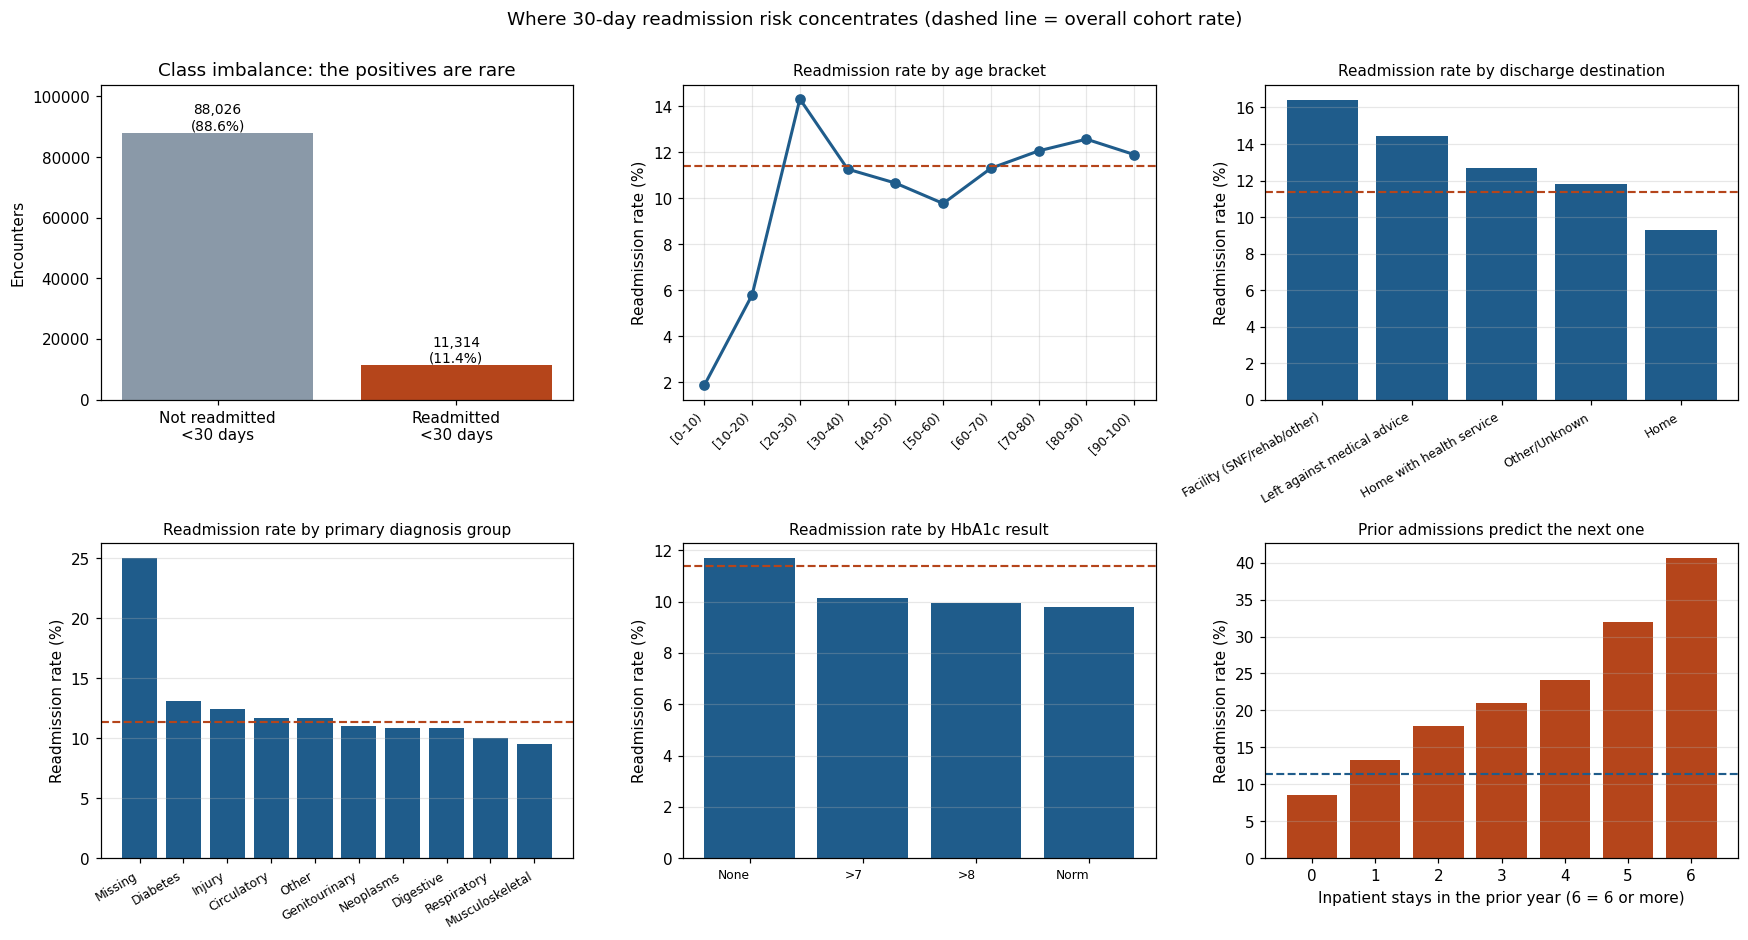

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))

# (1) Class imbalance
counts_t = df[config.TARGET_COL].value_counts().sort_index()
axes[0, 0].bar(["Not readmitted\n<30 days", "Readmitted\n<30 days"], counts_t.values,
               color=["#8a99a8", "#b5451b"])
for i, v in enumerate(counts_t.values):
    axes[0, 0].text(i, v, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0, 0].set_title("Class imbalance: the positives are rare")
axes[0, 0].set_ylabel("Encounters")
axes[0, 0].set_ylim(0, counts_t.max() * 1.18)

def rate_bar(ax, column, title, order=None, rotate=30):
    grouped = df.groupby(column)[config.TARGET_COL].agg(["size", "mean"])
    grouped = grouped.loc[order] if order else grouped.sort_values("mean", ascending=False)
    ax.bar(range(len(grouped)), grouped["mean"].values * 100, color="#1f5c8b")
    ax.axhline(df[config.TARGET_COL].mean() * 100, ls="--", color="#b5451b", lw=1.4)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(i) for i in grouped.index], rotation=rotate, ha="right", fontsize=8)
    ax.set_ylabel("Readmission rate (%)")
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3, axis="y")

# (2) Age brackets  (reproduces the idea of paper Fig. 2)
age_order = sorted(df["age"].unique())
grouped_age = df.groupby("age")[config.TARGET_COL].mean().loc[age_order]
axes[0, 1].plot(range(len(age_order)), grouped_age.values * 100, "o-", color="#1f5c8b", lw=2)
axes[0, 1].axhline(df[config.TARGET_COL].mean() * 100, ls="--", color="#b5451b", lw=1.4)
axes[0, 1].set_xticks(range(len(age_order)))
axes[0, 1].set_xticklabels(age_order, rotation=45, ha="right", fontsize=8)
axes[0, 1].set_ylabel("Readmission rate (%)")
axes[0, 1].set_title("Readmission rate by age bracket", fontsize=10)
axes[0, 1].grid(alpha=0.3)

rate_bar(axes[0, 2], "discharge_group", "Readmission rate by discharge destination")
rate_bar(axes[1, 0], "diag_1_group", "Readmission rate by primary diagnosis group")
rate_bar(axes[1, 1], "A1Cresult", "Readmission rate by HbA1c result", rotate=0)

# (6) Prior inpatient stays by outcome
capped_prior = df["number_inpatient"].clip(upper=6)
tab = pd.crosstab(capped_prior, df[config.TARGET_COL], normalize="index") * 100
axes[1, 2].bar(tab.index.astype(int), tab[1].values, color="#b5451b")
axes[1, 2].axhline(df[config.TARGET_COL].mean() * 100, ls="--", color="#1f5c8b", lw=1.4)
axes[1, 2].set_xlabel("Inpatient stays in the prior year (6 = 6 or more)")
axes[1, 2].set_ylabel("Readmission rate (%)")
axes[1, 2].set_title("Prior admissions predict the next one", fontsize=10)
axes[1, 2].grid(alpha=0.3, axis="y")

fig.suptitle("Where 30-day readmission risk concentrates (dashed line = overall cohort rate)",
             fontsize=12, y=1.00)
fig.tight_layout()
utils.savefig(fig, "eda_overview")
plt.show()

In [11]:
prior_yes = df.loc[df["any_prior_inpatient"] == 1, config.TARGET_COL].mean()
prior_no = df.loc[df["any_prior_inpatient"] == 0, config.TARGET_COL].mean()
facility = df.loc[df["discharge_group"] == "Facility (SNF/rehab/other)", config.TARGET_COL].mean()
home = df.loc[df["discharge_group"] == "Home", config.TARGET_COL].mean()

display(Markdown(f"""
**The three strongest raw signals in the cohort**

| Contrast | Readmission rate | Per 1,000 discharges |
| :--- | ---: | ---: |
| At least one inpatient stay in the prior year | **{prior_yes*100:.2f}%** | {prior_yes*1000:.0f} |
| No inpatient stay in the prior year | **{prior_no*100:.2f}%** | {prior_no*1000:.0f} |
| Discharged to a nursing / rehabilitation facility | **{facility*100:.2f}%** | {facility*1000:.0f} |
| Discharged home | **{home*100:.2f}%** | {home*1000:.0f} |

A patient with a prior-year admission is **{prior_yes/prior_no:.1f}x** as likely to be readmitted as one
without, and a patient discharged to a facility is **{facility/home:.1f}x** as likely as one sent home.
"""))


**The three strongest raw signals in the cohort**

| Contrast | Readmission rate | Per 1,000 discharges |
| :--- | ---: | ---: |
| At least one inpatient stay in the prior year | **16.99%** | 170 |
| No inpatient stay in the prior year | **8.59%** | 86 |
| Discharged to a nursing / rehabilitation facility | **16.43%** | 164 |
| Discharged home | **9.30%** | 93 |

A patient with a prior-year admission is **2.0x** as likely to be readmitted as one
without, and a patient discharged to a facility is **1.8x** as likely as one sent home.


> **So what?** Past use of the hospital is the clearest predictor of future use, and the discharge
> destination is the second. Clinically that is reassuring rather than surprising — it says the model
> is picking up recognisable frailty and care-complexity, not a spurious artefact. It also carries a
> warning for later: because the model leans on prior-year utilisation, it will be **weakest exactly
> where that history is absent**, i.e. for first-time admissions. Section 8.3 measures that cost.

## 4.7 Representativeness, sampling bias and external validity

| Concern | What it means for this project |
| :--- | :--- |
| **Geography** | 130 **US** hospitals only. Care pathways, insurance and discharge norms differ elsewhere; nothing here transfers to another health system without revalidation. |
| **Voluntary participation** | Hospitals are Cerner Health Facts clients who agreed to contribute data — a self-selected group, typically larger and better resourced. This is **selection bias at the site level**, and we cannot measure it because the site identifier is not released. |
| **Era (1999–2008)** | Predates the 2009 inpatient glycaemic-control guidelines, the HITECH Act and modern transitional-care programmes. Baseline readmission rates and practice have both moved since. |
| **In-network outcome only** | Readmissions to unaffiliated hospitals are invisible, so the label **under-counts** positives, probably unevenly across payer and race (Section 2.4). |
| **Coarse race categories** | Five broad categories with 2.2% missing. Adequate to detect gross disparity, far too coarse to describe real populations. |
| **Payer missing 40%** | `payer_code` is missing for a large minority and not at random. "Unknown" is treated as its own level and audited, never imputed away. |
| **No dates, no site ID** | The file contains no admission date and no hospital identifier, so neither a temporal nor a site-based split is possible (Section 5). |
| **Encounter-level rows** | One row per stay, not per patient — handled by the patient-grouped split. |

> **So what?** This cohort is large and real, which is its strength, but it is a **convenience sample
> of one country, one vendor's client hospitals and one decade**. It is well suited to learning how to
> build and audit a readmission model. It is *not* suited to producing a risk score that any hospital
> should deploy today. Before real use, a hospital would need to refit on its own recent data and
> validate prospectively, on its own patients, against its own outcomes.

# 5. Experimental design and splits

## 5.1 Why the split is grouped by patient

A deployed model scores **every discharge**, including the fourth discharge of a frequently admitted
patient. So the unit of analysis is the encounter, and we keep all eligible encounters rather than
only the first per patient. That choice creates the leakage risk we saw in Section 4.3 — and we
neutralise it by splitting on `patient_nbr`, so that **no patient ever appears in two partitions**.

**Why not a temporal split?** The rubric rightly prefers splits that mirror deployment, and a temporal
split would be ideal. It is **not possible here**: the released file contains no admission or discharge
date, and `encounter_id` is not documented as chronological, so any "time" ordering would be an
assumption we cannot verify. A patient-grouped split is the strongest available proxy, and we state
plainly that it does **not** test robustness to practice drift over time.

**Why not a site split?** Also impossible — the hospital identifier is not released.

**Four partitions, four distinct jobs.** Most tutorials use three. We use four because calibration
needs its own data: fitting a calibrator on the training predictions would calibrate to predictions the
model has already over-fitted, and fitting it on validation would contaminate the data we use to choose
the threshold.

| Partition | Share | Job |
| :--- | ---: | :--- |
| **Train** | 60% | Fit model parameters |
| **Calibration** | 10% | Fit the probability calibrator on a model that has never seen these rows |
| **Validation** | 15% | Compare models, choose and lock the alert threshold |
| **Test** | 15% | Opened **once**, after model and threshold are frozen |

In [12]:
parts, split_summary = utils.grouped_train_cal_val_test_split(
    df, group_col=config.GROUP_COL, target_col=config.TARGET_COL,
    sizes=config.SPLIT_SIZES, seed=RANDOM_STATE,
)

display(split_summary.style.hide(axis="index").format({
    "Encounters": "{:,.0f}", "Unique patients": "{:,.0f}",
    "Readmissions <30d": "{:,.0f}", "Prevalence %": "{:.2f}", "Share of cohort %": "{:.1f}",
}))
utils.savetable(split_summary, "split_summary")

# Hard assertion: no patient may appear in two partitions
utils.assert_no_leakage(parts, config.GROUP_COL)
print("Leakage check passed: no patient_nbr appears in more than one partition")

overall_prev = df[config.TARGET_COL].mean()
gaps = {k: abs(v[config.TARGET_COL].mean() - overall_prev) * 100 for k, v in parts.items()}
print(f"Largest prevalence gap vs overall: {max(gaps.values()):.2f} percentage points "
      f"(in '{max(gaps, key=gaps.get)}') - within the 1 point tolerance")
print(f"\nTest set reserved: {len(parts['test']):,} encounters. Its labels stay closed until Section 8.")

Partition,Role,Encounters,Unique patients,Readmissions <30d,Prevalence %,Share of cohort %
train,Fit the model,"59,607","41,992","6,749",11.32,60.0
cal,Fit the probability calibrator,"9,886","6,998","1,135",11.48,10.0
val,Model selection and threshold policy,"14,962","10,498","1,732",11.58,15.1
test,"Opened once, after the policy is locked","14,885","10,499","1,698",11.41,15.0
overall,-,"99,340","69,987","11,314",11.39,100.0


Leakage check passed: no patient_nbr appears in more than one partition
Largest prevalence gap vs overall: 0.19 percentage points (in 'val') - within the 1 point tolerance

Test set reserved: 14,885 encounters. Its labels stay closed until Section 8.


## 5.2 The pipeline and its leakage controls

Every **stateful** step lives inside the sklearn `Pipeline`, so each one is fitted on the training fold
and merely *applied* to validation, calibration and test:

- **Numeric:** median imputation → standardisation. The median comes from training data only.
- **Categorical:** constant `"Missing"` imputation → one-hot encoding with
  `min_frequency=MIN_CATEGORY_FREQ`.

That `min_frequency` parameter is the subtle one. `medical_specialty` has more than 70 levels, many of
them rare. Deciding which are "rare" by looking at the whole dataset would leak information from the
test set into the feature definition. Setting `min_frequency` inside the encoder means **the rare-
category grouping is learned from the training fold**, and an unseen specialty at test time is routed
to the infrequent bucket automatically.

In [13]:
feature_lists = utils.get_feature_lists(df)
num_cols = feature_lists["numeric_cols"]
cat_cols = feature_lists["categorical_cols"]
TARGET = config.TARGET_COL

print(f"Numeric features    ({len(num_cols):2d}): {', '.join(num_cols)}")
print(f"\nCategorical features({len(cat_cols):2d}): {', '.join(cat_cols)}")
print(f"\nExcluded by design: patient_nbr (group key only), encounter_id (identifier), "
      f"race and gender (audited, not model inputs), readmitted (raw target)")

def split_xy(part):
    return part[num_cols + cat_cols], part[TARGET]

X_train, y_train = split_xy(parts["train"])
X_cal,   y_cal   = split_xy(parts["cal"])
X_val,   y_val   = split_xy(parts["val"])
X_test,  y_test  = split_xy(parts["test"])

print(f"\nTrain {X_train.shape} | Cal {X_cal.shape} | Val {X_val.shape} | Test {X_test.shape}")

Numeric features    (13): time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient, number_diagnoses, age_years, total_prior_visits, n_meds_up, n_meds_down, n_diabetes_meds_prescribed

Categorical features(21): admission_group, admission_source_group, discharge_group, medical_specialty, diag_1_group, diag_2_group, diag_3_group, max_glu_serum, A1Cresult, A1C_tested, glu_tested, med_change, on_diabetes_med, any_prior_inpatient, insulin, metformin, glipizide, glyburide, pioglitazone, rosiglitazone, payer_group

Excluded by design: patient_nbr (group key only), encounter_id (identifier), race and gender (audited, not model inputs), readmitted (raw target)

Train (59607, 34) | Cal (9886, 34) | Val (14962, 34) | Test (14885, 34)


### Leakage control checklist

| Control | How it is enforced here |
| :--- | :--- |
| Identifiers are never features | `encounter_id` dropped; `patient_nbr` used **only** as the split group key (asserted in `tests/test_utils.py`) |
| No patient in two partitions | `assert_no_leakage()` raises on any overlap; run above |
| Imputation fitted on train only | `SimpleImputer` inside the `Pipeline` |
| Scaling fitted on train only | `StandardScaler` inside the `Pipeline` |
| Rare-category grouping learned on train only | `OneHotEncoder(min_frequency=...)` inside the `Pipeline` |
| Unseen categories handled | `handle_unknown="infrequent_if_exist"` |
| No target-derived features | Every engineered feature is a row-wise rule over inputs; `readmitted` is dropped |
| Nothing from after discharge | All inputs describe the stay or the prior year (Section 2.2) |
| Calibration off training data | Fitted on the dedicated `cal` slice only (Section 6) |
| Threshold off test data | Chosen on `val` only, locked before Section 8 |
| Test opened once | The locked model is evaluated on test once, guarded by a `POLICY_LOCKED` assertion (Section 8.2). Later uses of test (8.4.1–8.5, 9.4d) are labelled post-hoc and change nothing that was locked |

## 5.3 Baselines, defined before any tuning

Two reference points. If a real model cannot beat both, it has earned nothing.

In [14]:
# Baseline 1: always predict the majority class
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)
dummy_pred = dummy_clf.predict(X_val)
dummy_accuracy = accuracy_score(y_val, dummy_pred)
dummy_scores = utils.positive_scores(dummy_clf, X_val)
metrics_dummy = utils.auc_report(y_val, dummy_scores, name="Majority-class baseline", plot=False)

# Baseline 2: give every patient the training prevalence as their score
prevalence_scores = np.full(len(y_val), y_train.mean())
metrics_prevalence = utils.auc_report(y_val, prevalence_scores, name="Prevalence-only baseline", plot=False)

baseline_table = pd.DataFrame([
    {"Baseline": "Majority class ('nobody is readmitted')",
     "Accuracy": dummy_accuracy, "Recall": 0.0,
     "Readmissions found": 0, "ROC-AUC": 0.5,
     "PR-AUC": metrics_dummy["pr_auc"], "Brier": metrics_dummy["brier"]},
    {"Baseline": "Prevalence-only score",
     "Accuracy": dummy_accuracy, "Recall": np.nan,
     "Readmissions found": 0, "ROC-AUC": 0.5,
     "PR-AUC": metrics_prevalence["pr_auc"], "Brier": metrics_prevalence["brier"]},
])
display(baseline_table.style.hide(axis="index").format({
    "Accuracy": "{:.4f}", "Recall": "{:.3f}", "Readmissions found": "{:,.0f}",
    "ROC-AUC": "{:.3f}", "PR-AUC": "{:.4f}", "Brier": "{:.4f}",
}, na_rep="n/a"))

display(Markdown(
    f"The majority-class baseline is **{dummy_accuracy*100:.1f}% accurate** and finds "
    f"**zero** of the **{int(y_val.sum()):,}** readmissions in the validation set. Its Brier score, "
    f"**{metrics_prevalence['brier']:.4f}**, is the bar that any calibrated model must beat in Section 6."
))

Baseline,Accuracy,Recall,Readmissions found,ROC-AUC,PR-AUC,Brier
Majority class ('nobody is readmitted'),0.8842,0.000,0,0.500,0.1158,0.1158
Prevalence-only score,0.8842,n/a,0,0.500,0.1158,0.1024


The majority-class baseline is **88.4% accurate** and finds **zero** of the **1,732** readmissions in the validation set. Its Brier score, **0.1024**, is the bar that any calibrated model must beat in Section 6.

> **So what?** A model that predicts "no readmission" for everyone scores **88.4% accuracy** and is
> worth precisely nothing: it identifies nobody for the transitional-care team and prevents nothing.
> This is why accuracy is banned from the rest of this notebook. The honest bar is the
> **prevalence-only PR-AUC of ≈ 0.116** — the performance of guessing — and the model has to beat that
> to justify anyone's time.

## 5.4 Transparent baseline model: logistic regression

We deliberately do **not** use `class_weight="balanced"`. Re-weighting the classes inflates predicted
probabilities away from the true rate, which is exactly what we must not do when a nurse is going to
read the output as "this patient has an 18% chance of coming back". The imbalance is handled where it
belongs — in **calibration** (Section 6) and in **threshold choice** (Section 7), not by distorting the
model.

Fitted logistic regression in 1.5s
Features after one-hot encoding: 126 (retained after variance filter: 126)


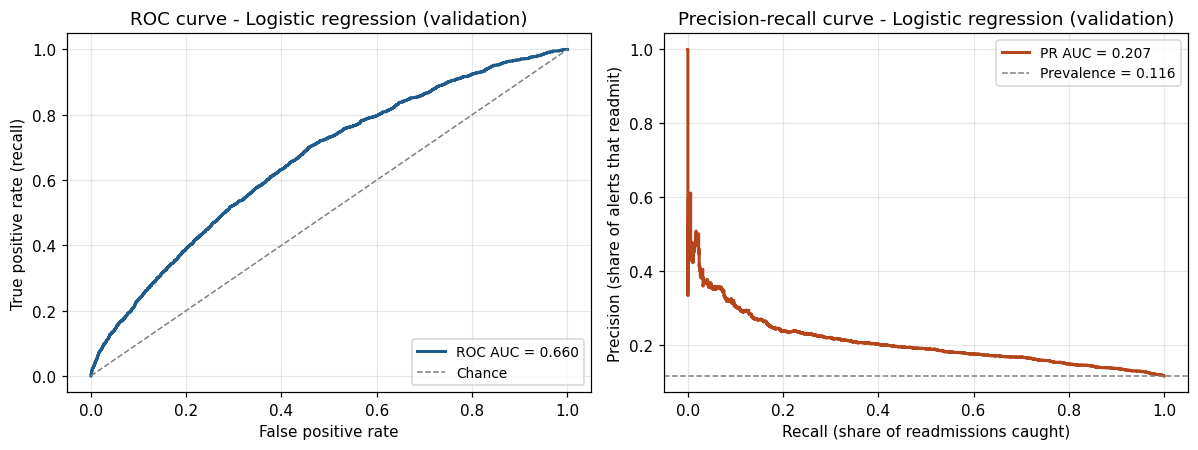

{'name': 'Logistic regression (validation)', 'n': 14962, 'prevalence': 0.1158, 'roc_auc': 0.6601, 'pr_auc': 0.2071, 'brier': 0.0987, 'log_loss': 0.3419}


In [15]:
base_clf = Pipeline(steps=[
    ("prep", utils.build_preprocessor(num_cols, cat_cols)),
    ("varth", VarianceThreshold(threshold=0.0)),   # drop features constant in training data
    ("model", LogisticRegression(
        solver="lbfgs", max_iter=2000, class_weight=None, random_state=RANDOM_STATE,
    )),
])

t0 = time.time()
base_clf.fit(X_train, y_train)
print(f"Fitted logistic regression in {time.time() - t0:.1f}s")

n_features_out = base_clf.named_steps["prep"].transform(X_train.head(2)).shape[1]
n_retained = int(base_clf.named_steps["varth"].get_support().sum())
print(f"Features after one-hot encoding: {n_features_out} (retained after variance filter: {n_retained})")

score_val_lr = utils.positive_scores(base_clf, X_val)
metrics_lr = utils.auc_report(y_val, score_val_lr, name="Logistic regression (validation)", plot=True)
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in metrics_lr.items()})

In [16]:
# Coefficients as odds ratios - association, NOT causation
preprocessor = base_clf.named_steps["prep"]
variance_filter = base_clf.named_steps["varth"]
logistic_model = base_clf.named_steps["model"]

feature_names = np.asarray(preprocessor.get_feature_names_out())[variance_filter.get_support()]
coefficients = logistic_model.coef_.ravel()

coef_table = pd.DataFrame({
    "Feature": [n.split("__")[-1] for n in feature_names],
    "Coefficient": coefficients,
    "Odds ratio": np.exp(coefficients),
    "Direction": np.where(coefficients > 0, "increases risk", "decreases risk"),
})
coef_table["Strength"] = coef_table["Coefficient"].abs()
coef_table = coef_table.sort_values("Strength", ascending=False).reset_index(drop=True)
coef_table.insert(0, "Rank", np.arange(1, len(coef_table) + 1))

display(Markdown("**The 15 strongest associations learned by the model**"))
display(coef_table.drop(columns="Strength").head(15).style.hide(axis="index").format({
    "Coefficient": "{:.3f}", "Odds ratio": "{:.3f}",
}))
utils.savetable(coef_table.drop(columns="Strength"), "logistic_odds_ratios")

**The 15 strongest associations learned by the model**

Rank,Feature,Coefficient,Odds ratio,Direction
1,medical_specialty_Surgery-Cardiovascular/Thoracic,-0.520,0.594,decreases risk
2,diag_3_group_Missing,-0.456,0.634,decreases risk
3,medical_specialty_ObstetricsandGynecology,-0.440,0.644,decreases risk
4,medical_specialty_Oncology,0.438,1.549,increases risk
5,medical_specialty_Hematology/Oncology,0.417,1.517,increases risk
6,medical_specialty_Orthopedics-Reconstructive,-0.321,0.725,decreases risk
7,glyburide_Down,-0.301,0.740,decreases risk
8,medical_specialty_Nephrology,0.299,1.349,increases risk
9,discharge_group_Home,-0.288,0.750,decreases risk
10,discharge_group_Facility (SNF/rehab/other),0.281,1.324,increases risk


PosixPath('/home/claude/proj/outputs/tables/logistic_odds_ratios.csv')

> **So what?** These are **associations, not causes**. An odds ratio above 1 means that among
> patients who otherwise look alike in this dataset, those with the feature were readmitted more often.
> It does **not** mean the feature caused the readmission, and it certainly does not mean that changing
> it would prevent one. The pattern is clinically coherent — oncology and nephrology specialities,
> discharge to a facility, and prior inpatient stays push risk up; discharge straight home and elective
> surgical specialities push it down — which is a useful sanity check that the model learned medicine
> rather than noise.

## 5.5 Candidate model: histogram gradient boosting

The paper found meaningful interactions (notably HbA1c result × primary diagnosis). A gradient-boosted
tree model can represent those without us specifying them. It is tuned with a **small** grid using
`GroupKFold` on the **training set only**, scored by `average_precision` (PR-AUC), which is the metric
that respects an 11% prevalence.

Grid search finished in 65.9s over 4 configurations
Best parameters : {'model__l2_regularization': 1.0, 'model__learning_rate': 0.1, 'model__max_leaf_nodes': 15, 'model__min_samples_leaf': 50}
Best grouped-CV PR-AUC on train: 0.2122


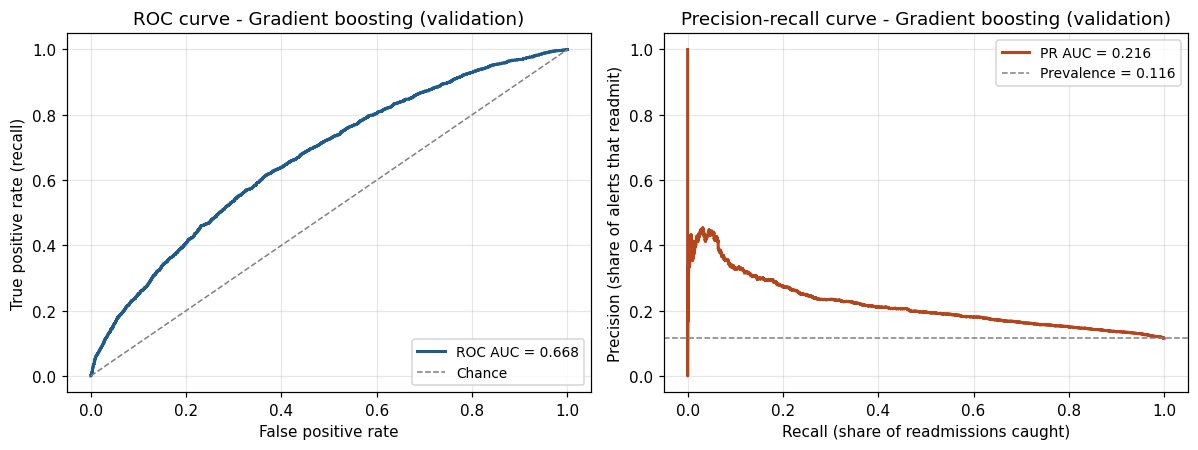

{'name': 'Gradient boosting (validation)', 'n': 14962, 'prevalence': 0.1158, 'roc_auc': 0.6679, 'pr_auc': 0.2164, 'brier': 0.0981, 'log_loss': 0.3394}


In [17]:
hgb_clf = Pipeline(steps=[
    ("prep", utils.build_preprocessor(num_cols, cat_cols)),
    ("model", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, early_stopping=True, validation_fraction=0.1,
    )),
])

param_grid = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__min_samples_leaf": [50],
    "model__l2_regularization": [1.0],
}

t0 = time.time()
search = GridSearchCV(
    hgb_clf, param_grid, scoring="average_precision",
    cv=GroupKFold(n_splits=5), n_jobs=-1, refit=True,
)
search.fit(X_train, y_train, groups=parts["train"][config.GROUP_COL])
print(f"Grid search finished in {time.time() - t0:.1f}s over {len(search.cv_results_['params'])} configurations")
print(f"Best parameters : {search.best_params_}")
print(f"Best grouped-CV PR-AUC on train: {search.best_score_:.4f}")

hgb_best = search.best_estimator_
score_val_hgb = utils.positive_scores(hgb_best, X_val)
metrics_hgb = utils.auc_report(y_val, score_val_hgb, name="Gradient boosting (validation)", plot=True)
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in metrics_hgb.items()})

## 5.6 Model selection — by the rule we wrote down first

The pre-specified rule (recorded in `CLAUDE.md` before modelling began):

> Pick the final model by **validation PR-AUC**, tie-break by Brier score and simplicity.
> **If the gain over logistic regression is smaller than 0.01 PR-AUC, prefer logistic regression** for
> interpretability.

We also report a **patient-clustered bootstrap** interval. Resampling encounters would understate
uncertainty, because repeat encounters of one patient are correlated; we resample **patients**.

In [18]:
comparison = pd.DataFrame([
    {"Model": "Prevalence-only baseline", **{k: metrics_prevalence[k] for k in ["roc_auc", "pr_auc", "brier", "log_loss"]}},
    {"Model": "Logistic regression",      **{k: metrics_lr[k] for k in ["roc_auc", "pr_auc", "brier", "log_loss"]}},
    {"Model": "Gradient boosting",        **{k: metrics_hgb[k] for k in ["roc_auc", "pr_auc", "brier", "log_loss"]}},
]).rename(columns={"roc_auc": "ROC-AUC", "pr_auc": "PR-AUC", "brier": "Brier", "log_loss": "Log loss"})

val_groups = parts["val"][config.GROUP_COL].values
ci_rows = []
for label, scores in [("Logistic regression", score_val_lr), ("Gradient boosting", score_val_hgb)]:
    lo, hi = utils.bootstrap_metric_ci(y_val, scores, val_groups, metric="pr_auc", n_boot=200, seed=RANDOM_STATE)
    ci_rows.append({"Model": label, "PR-AUC 95% CI (patient-clustered)": f"{lo:.4f} to {hi:.4f}"})
comparison = comparison.merge(pd.DataFrame(ci_rows), on="Model", how="left")

display(comparison.style.hide(axis="index").format({
    "ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}", "Brier": "{:.4f}", "Log loss": "{:.4f}",
}, na_rep="-"))
utils.savetable(comparison, "model_comparison_validation")

# Apply the pre-specified selection rule programmatically
PR_AUC_GAIN_THRESHOLD = 0.01
pr_auc_gain = metrics_hgb["pr_auc"] - metrics_lr["pr_auc"]

if pr_auc_gain >= PR_AUC_GAIN_THRESHOLD:
    final_model_name, final_model_uncalibrated, score_val_selected = (
        "Gradient boosting", hgb_best, score_val_hgb)
else:
    final_model_name, final_model_uncalibrated, score_val_selected = (
        "Logistic regression", base_clf, score_val_lr)

display(Markdown(f"""
**Selection rule applied.** Gradient boosting improves validation PR-AUC by
**{pr_auc_gain:+.4f}** over logistic regression
({metrics_lr['pr_auc']:.4f} → {metrics_hgb['pr_auc']:.4f}). The pre-specified threshold for preferring
the more complex model is **{PR_AUC_GAIN_THRESHOLD:.2f}**, so the gain is
**{'large enough' if pr_auc_gain >= PR_AUC_GAIN_THRESHOLD else 'NOT large enough'}**.

> ### Selected model: **{final_model_name}**
"""))

Model,ROC-AUC,PR-AUC,Brier,Log loss,PR-AUC 95% CI (patient-clustered)
Prevalence-only baseline,0.5000,0.1158,0.1024,0.3584,-
Logistic regression,0.6601,0.2071,0.0987,0.3419,0.1902 to 0.2265
Gradient boosting,0.6679,0.2164,0.0981,0.3394,0.1997 to 0.2365



**Selection rule applied.** Gradient boosting improves validation PR-AUC by
**+0.0094** over logistic regression
(0.2071 → 0.2164). The pre-specified threshold for preferring
the more complex model is **0.01**, so the gain is
**NOT large enough**.

> ### Selected model: **Logistic regression**


In [19]:
# Does the model beat the pre-specified success criteria? (validation, uncalibrated)
selected_metrics = metrics_hgb if final_model_name == "Gradient boosting" else metrics_lr
criteria = pd.DataFrame([
    {"Criterion": "PR-AUC clearly above prevalence",
     "Target": f"> {y_val.mean():.3f}", "Achieved": f"{selected_metrics['pr_auc']:.4f}",
     "Met": selected_metrics["pr_auc"] > y_val.mean() * 1.25},
    {"Criterion": "ROC-AUC at least 0.65",
     "Target": ">= 0.650", "Achieved": f"{selected_metrics['roc_auc']:.4f}",
     "Met": selected_metrics["roc_auc"] >= 0.65},
    {"Criterion": "Brier below prevalence-only baseline",
     "Target": f"< {metrics_prevalence['brier']:.4f}", "Achieved": f"{selected_metrics['brier']:.4f}",
     "Met": selected_metrics["brier"] < metrics_prevalence["brier"]},
])
criteria["Met"] = criteria["Met"].map({True: "yes", False: "NO"})
display(criteria.style.hide(axis="index"))

display(Markdown(
    f"The selected model lifts PR-AUC from the prevalence baseline of **{y_val.mean():.4f}** to "
    f"**{selected_metrics['pr_auc']:.4f}** — roughly **{selected_metrics['pr_auc']/y_val.mean():.1f}x** "
    f"better than guessing at the same workload."
))

Criterion,Target,Achieved,Met
PR-AUC clearly above prevalence,> 0.116,0.2071,yes
ROC-AUC at least 0.65,>= 0.650,0.6601,yes
Brier below prevalence-only baseline,< 0.1024,0.0987,yes


The selected model lifts PR-AUC from the prevalence baseline of **0.1158** to **0.2071** — roughly **1.8x** better than guessing at the same workload.

> **So what?** Gradient boosting is genuinely a little better, but by less than the margin we
> agreed in advance would justify giving up an interpretable model — and the two patient-clustered
> confidence intervals overlap heavily, so we cannot even be confident the gap is real. We therefore
> keep **logistic regression**, whose odds-ratio table a clinician can read and challenge. This is the
> rule working as intended: it was written before we saw the numbers, so it could not be bent
> afterwards.
>
> On the absolute level, be honest: a ROC-AUC near **0.66** is *modest*. It means that if you pick one
> patient who was readmitted and one who was not, the model ranks them correctly about two times in
> three. That is enough to **prioritise a limited review list**, which is exactly our stated use. It is
> nowhere near enough to make a decision about an individual patient, and we will not claim otherwise.

# 6. Probability calibration

## 6.1 What calibration means, in plain words

A model score is only useful to a nurse if it means what it says. **Calibration** asks: among all the
patients the model gave a risk of about 20%, did about 20% of them actually come back?

- A model can **rank** patients well and still be **badly calibrated** — it gets the order right but
  the numbers wrong.
- Ranking drives *who* gets flagged. Calibration drives whether "18% risk" can be said out loud to a
  colleague or a patient.
- Calibration **cannot** fix a weak model. It rescales the probabilities; it does not change the order,
  so ROC-AUC and PR-AUC stay essentially unchanged. We verify exactly that below.

**Where we fit it.** On the dedicated **calibration slice** — 10% of patients the model has never
trained on, and which is *not* the validation slice used to choose the threshold, and *not* the test
set. This is stricter than the common practice of calibrating with cross-validation on the training
data, and it is what the rubric asks for.

We compare two methods on validation:

- **Sigmoid (Platt scaling)** — fits two parameters. Stable, hard to overfit.
- **Isotonic** — fits a free monotonic step function. More flexible, more prone to overfitting on a
  small calibration slice.

In [20]:
# Fit both calibrators on the calibration slice ONLY
t0 = time.time()
calibrated_sigmoid = utils.calibrate_on_holdout(final_model_uncalibrated, X_cal, y_cal, method="sigmoid")
calibrated_isotonic = utils.calibrate_on_holdout(final_model_uncalibrated, X_cal, y_cal, method="isotonic")
print(f"Calibrators fitted on {len(X_cal):,} encounters from "
      f"{parts['cal'][config.GROUP_COL].nunique():,} patients in {time.time() - t0:.1f}s")
print("The calibration slice was used for nothing else.")

score_val_sigmoid = utils.positive_scores(calibrated_sigmoid, X_val)
score_val_isotonic = utils.positive_scores(calibrated_isotonic, X_val)

calibration_comparison = pd.DataFrame([
    {"Scores": "Raw (uncalibrated)",  **utils.auc_report(y_val, score_val_selected, "raw", plot=False)},
    {"Scores": "Calibrated - sigmoid", **utils.auc_report(y_val, score_val_sigmoid, "sigmoid", plot=False)},
    {"Scores": "Calibrated - isotonic", **utils.auc_report(y_val, score_val_isotonic, "isotonic", plot=False)},
]).drop(columns=["name", "n", "prevalence"])
calibration_comparison["ECE"] = [
    utils.expected_calibration_error(y_val, s)
    for s in [score_val_selected, score_val_sigmoid, score_val_isotonic]
]
calibration_comparison = calibration_comparison.rename(columns={
    "roc_auc": "ROC-AUC", "pr_auc": "PR-AUC", "brier": "Brier", "log_loss": "Log loss"})

display(calibration_comparison.style.hide(axis="index").format({
    "ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}", "Brier": "{:.5f}", "Log loss": "{:.4f}", "ECE": "{:.4f}",
}))
utils.savetable(calibration_comparison, "calibration_method_comparison")

Calibrators fitted on 9,886 encounters from 6,998 patients in 0.1s
The calibration slice was used for nothing else.


Scores,ROC-AUC,PR-AUC,Brier,Log loss,ECE
Raw (uncalibrated),0.6601,0.2071,0.09874,0.3419,0.0112
Calibrated - sigmoid,0.6601,0.2071,0.09875,0.3419,0.0111
Calibrated - isotonic,0.6585,0.1954,0.09892,0.3425,0.0114


PosixPath('/home/claude/proj/outputs/tables/calibration_method_comparison.csv')

In [21]:
# Choose the calibrator by validation Brier score, tie-broken by ECE
brier_sigmoid = calibration_comparison.loc[calibration_comparison["Scores"] == "Calibrated - sigmoid", "Brier"].iloc[0]
brier_isotonic = calibration_comparison.loc[calibration_comparison["Scores"] == "Calibrated - isotonic", "Brier"].iloc[0]

if brier_sigmoid <= brier_isotonic:
    CALIBRATION_METHOD, calibrated_clf, score_val = "sigmoid", calibrated_sigmoid, score_val_sigmoid
else:
    CALIBRATION_METHOD, calibrated_clf, score_val = "isotonic", calibrated_isotonic, score_val_isotonic

display(Markdown(
    f"**Calibrator selected: {CALIBRATION_METHOD}** "
    f"(validation Brier {min(brier_sigmoid, brier_isotonic):.5f} vs "
    f"{max(brier_sigmoid, brier_isotonic):.5f} for the alternative). "
    f"All threshold analysis from here uses these calibrated scores."
))

roc_shift = abs(utils.auc_report(y_val, score_val, "c", plot=False)["roc_auc"] - metrics_lr["roc_auc"] if final_model_name == "Logistic regression" else 0)
print(f"Sanity check - calibration should not change the ranking: "
      f"ROC-AUC moved by {roc_shift:.5f}")

**Calibrator selected: sigmoid** (validation Brier 0.09875 vs 0.09892 for the alternative). All threshold analysis from here uses these calibrated scores.

Sanity check - calibration should not change the ranking: ROC-AUC moved by 0.00000


## 6.2 Calibration in the large, and the reliability curve

Scores,Mean predicted risk,Observed readmission rate,Difference,Brier score,ECE
Raw (uncalibrated),0.1129,0.1158,-0.0028,0.09874,0.0112
Calibrated (sigmoid),0.1146,0.1158,-0.0011,0.09875,0.0111


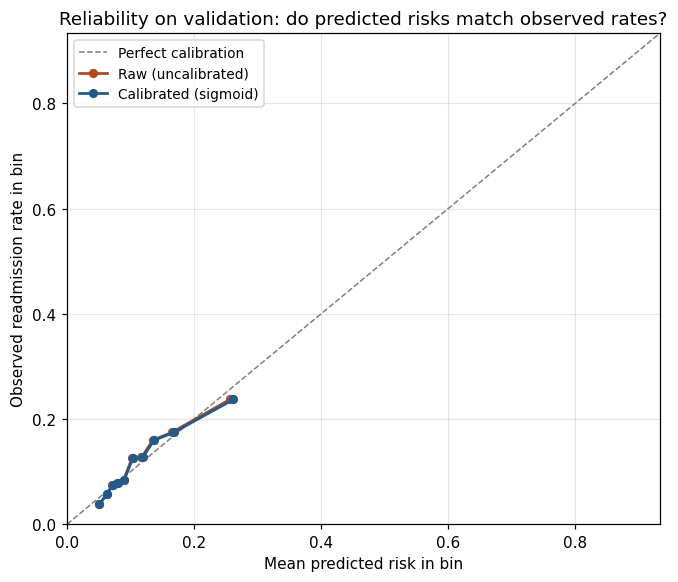

Bin,n,Mean predicted risk,Observed readmission rate,Readmissions,Gap (predicted - observed)
1,"1,497",0.0509,0.0381,57,+0.0129
2,"1,496",0.0636,0.0582,87,+0.0054
3,"1,496",0.0719,0.0742,111,-0.0023
4,"1,496",0.0801,0.0789,118,+0.0012
5,"1,496",0.0903,0.0849,127,+0.0054
6,"1,496",0.1035,0.1250,187,-0.0215
7,"1,496",0.1189,0.1270,190,-0.0081
8,"1,496",0.1373,0.1598,239,-0.0225
9,"1,496",0.1680,0.1745,261,-0.0065
10,"1,497",0.2620,0.2371,355,+0.0248


PosixPath('/home/claude/proj/outputs/tables/reliability_table.csv')

In [22]:
cal_large = utils.calibration_in_the_large(y_val, {
    "Raw (uncalibrated)": score_val_selected,
    f"Calibrated ({CALIBRATION_METHOD})": score_val,
})
display(cal_large.style.hide(axis="index").format({
    "Mean predicted risk": "{:.4f}", "Observed readmission rate": "{:.4f}",
    "Difference": "{:+.4f}", "Brier score": "{:.5f}", "ECE": "{:.4f}",
}))
utils.savetable(cal_large, "calibration_in_the_large")

fig = utils.plot_reliability(y_val, {
    "Raw (uncalibrated)": score_val_selected,
    f"Calibrated ({CALIBRATION_METHOD})": score_val,
}, n_bins=10, title="Reliability on validation: do predicted risks match observed rates?")
utils.savefig(fig, "reliability_curve")

reliability = utils.reliability_table(y_val, score_val, n_bins=10)
display(reliability.style.hide(axis="index").format({
    "n": "{:,.0f}", "Mean predicted risk": "{:.4f}",
    "Observed readmission rate": "{:.4f}", "Readmissions": "{:,.0f}",
    "Gap (predicted - observed)": "{:+.4f}",
}))
utils.savetable(reliability, "reliability_table")

## 6.3 Calibration within subgroups

A model can be well calibrated overall while being systematically wrong for a particular group. That
is the failure mode that turns into an equity problem, so we check it before it reaches the fairness
section.

In [23]:
subgroup_cal_rows = []
for attribute in config.SENSITIVE_COLS:
    values = parts["val"][attribute].astype(str)
    for level in values.value_counts().index:
        mask = (values == level).values
        if mask.sum() < 100:
            continue
        subgroup_cal_rows.append({
            "Attribute": attribute,
            "Group": level,
            "n": int(mask.sum()),
            "Mean predicted risk": float(score_val[mask].mean()),
            "Observed rate": float(y_val.values[mask].mean()),
            "Difference": float(score_val[mask].mean() - y_val.values[mask].mean()),
        })

subgroup_calibration = pd.DataFrame(subgroup_cal_rows)
display(subgroup_calibration.style.hide(axis="index").format({
    "n": "{:,.0f}", "Mean predicted risk": "{:.4f}",
    "Observed rate": "{:.4f}", "Difference": "{:+.4f}",
}).background_gradient(subset=["Difference"], cmap="coolwarm", vmin=-0.05, vmax=0.05))
utils.savetable(subgroup_calibration, "subgroup_calibration_validation")

worst = subgroup_calibration.reindex(subgroup_calibration["Difference"].abs().sort_values(ascending=False).index).iloc[0]
display(Markdown(
    f"The largest calibration gap is in **{worst['Attribute']} = {worst['Group']}** "
    f"(n = {worst['n']:,}): mean predicted risk **{worst['Mean predicted risk']*100:.2f}%** versus an "
    f"observed rate of **{worst['Observed rate']*100:.2f}%**, a gap of "
    f"**{worst['Difference']*100:+.2f} percentage points**."
))

Attribute,Group,n,Mean predicted risk,Observed rate,Difference
race,Caucasian,"11,103",0.1145,0.1165,-0.0020
race,AfricanAmerican,"2,900",0.1185,0.1207,-0.0022
race,nan,339,0.1021,0.0649,+0.0372
race,Hispanic,321,0.1081,0.1246,-0.0166
race,Other,204,0.1044,0.0931,+0.0113
gender,Female,"7,972",0.1152,0.1115,+0.0037
gender,Male,"6,990",0.1140,0.1206,-0.0066
age_group,>60,"10,014",0.1195,0.1190,+0.0005
age_group,30-60,"4,576",0.1060,0.1128,-0.0067
age_group,<30,372,0.0902,0.0645,+0.0257


The largest calibration gap is in **race = nan** (n = 339): mean predicted risk **10.21%** versus an observed rate of **6.49%**, a gap of **+3.72 percentage points**.

> **So what?** Calibration is what lets a nurse read the number as a number. If the tool says
> "this patient has an 18% chance of returning within 30 days", the nurse can weigh that against the
> effort of a follow-up call — but only if 18% really means 18%. Two practical consequences:
>
> 1. **Ranking is unchanged.** ROC-AUC and PR-AUC barely move, confirming that calibration rescales
>    the probabilities rather than improving the model. Calibration is about *trust in the number*,
>    not about *finding more patients*.
> 2. **Risk is low in absolute terms.** Even the highest-risk decile sits far below 50%. The honest
>    way to present this tool is therefore *"this patient is in the top 10% of risk"*, not *"this
>    patient will be readmitted"* — and the alert threshold in Section 7 is correspondingly low, which
>    surprises people who expect a cutoff near 0.5.

# 7. Threshold selection and decision analysis

Everything in this section uses **calibrated scores on the validation set only**. The test set stays
closed.

A threshold turns a probability into an action. It is a **policy choice about capacity and tolerance
for missed patients**, not a property of the model. We compare four ways of making that choice.

In [24]:
thresholds_table = utils.tradeoff_table(y_val, score_val)
print(f"Trade-off table computed over {len(thresholds_table):,} candidate thresholds "
      f"on {len(y_val):,} validation encounters")

sample_rows = thresholds_table.iloc[
    np.linspace(0, len(thresholds_table) - 1, 12).astype(int)
][list(config.THRESHOLD_DISPLAY_LABELS)].rename(columns=config.THRESHOLD_DISPLAY_LABELS)
display(sample_rows.style.hide(axis="index").format({
    "Alert threshold": "{:.4f}",
    "Readmissions correctly flagged": "{:,.0f}", "Alerts on non-readmitted patients": "{:,.0f}",
    "Correctly not flagged": "{:,.0f}", "Missed readmissions": "{:,.0f}",
    "Recall (share of readmissions caught)": "{:.3f}",
    "Precision (share of alerts that readmit)": "{:.3f}",
    "Specificity": "{:.3f}", "False positive rate": "{:.3f}",
    "Alerts per 1,000 discharges": "{:.0f}",
    "Readmissions caught per 1,000": "{:.1f}", "Readmissions missed per 1,000": "{:.1f}",
}, na_rep="-"))

Trade-off table computed over 14,964 candidate thresholds on 14,962 validation encounters


Alert threshold,Readmissions correctly flagged,Alerts on non-readmitted patients,Correctly not flagged,Missed readmissions,Recall (share of readmissions caught),Precision (share of alerts that readmit),Specificity,False positive rate,"Alerts per 1,000 discharges","Readmissions caught per 1,000","Readmissions missed per 1,000"
0.0000,"1,732","13,230",0,0,1.000,0.116,0.000,1.000,1000,115.8,0.0
0.0581,"1,680","11,923","1,307",52,0.970,0.124,0.099,0.901,909,112.3,3.5
0.0662,"1,604","10,639","2,591",128,0.926,0.131,0.196,0.804,818,107.2,8.6
0.0737,"1,503","9,380","3,850",229,0.868,0.138,0.291,0.709,727,100.5,15.3
0.0813,"1,401","8,121","5,109",331,0.809,0.147,0.386,0.614,636,93.6,22.1
0.0907,"1,291","6,871","6,359",441,0.745,0.158,0.481,0.519,546,86.3,29.5
0.1026,"1,145","5,657","7,573",587,0.661,0.168,0.572,0.428,455,76.5,39.2
0.1169,974,"4,468","8,762",758,0.562,0.179,0.662,0.338,364,65.1,50.7
0.1321,789,"3,292","9,938",943,0.456,0.193,0.751,0.249,273,52.7,63.0
0.1546,577,"2,144","11,086","1,155",0.333,0.212,0.838,0.162,182,38.6,77.2


## 7.1.1 Method A — workload-constrained

*"We have capacity to review 250 patients per 1,000 discharges. Catch as many readmissions as we can
inside that budget."* This takes the **lowest** threshold that still fits capacity, which maximises
recall within the budget.

**Threshold 0.1371** → **250 alerts per 1,000** discharges, catching **42.6%** of readmissions at a precision of **19.7%**.

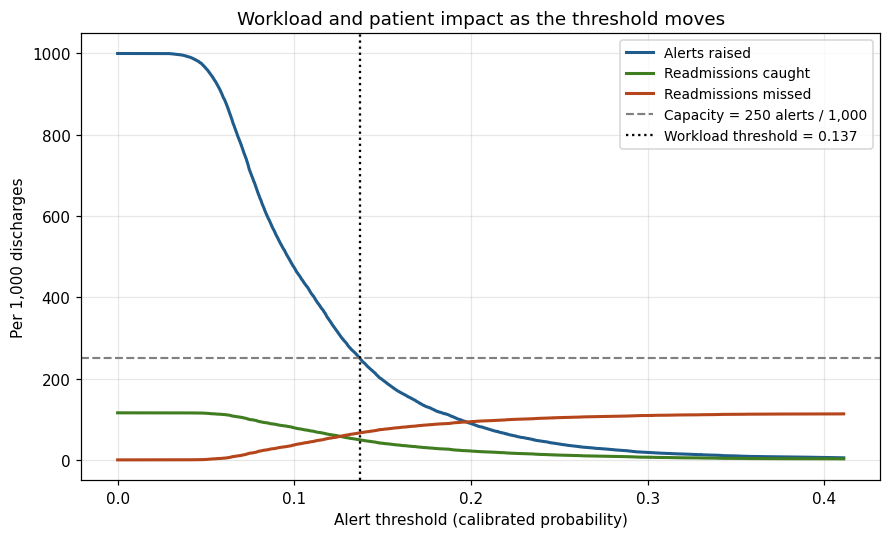

In [25]:
workload_pick = utils.pick_threshold_workload(y_val, score_val, config.MAX_ALERTS_PER_1000)
THR_WORKLOAD = workload_pick["threshold"]
workload_summary = utils.summary_at_threshold(y_val, score_val, THR_WORKLOAD).iloc[0]

display(Markdown(
    f"**Threshold {THR_WORKLOAD:.4f}** → **{workload_summary['alerts_per_1000']:.0f} alerts per 1,000** "
    f"discharges, catching **{workload_summary['recall']*100:.1f}%** of readmissions at a precision of "
    f"**{workload_summary['precision']*100:.1f}%**."
))

# Step plot: alerts, caught and missed per 1,000 as the threshold moves
plot_data = thresholds_table[thresholds_table["threshold"] <= np.percentile(score_val, 99.5)]
fig, ax = plt.subplots(figsize=(8.2, 5))
ax.plot(plot_data["threshold"], plot_data["alerts_per_1000"], lw=2, color="#1f5c8b", label="Alerts raised")
ax.plot(plot_data["threshold"], plot_data["true_pos_per_1000"], lw=2, color="#3f7d20", label="Readmissions caught")
ax.plot(plot_data["threshold"], plot_data["false_neg_per_1000"], lw=2, color="#b5451b", label="Readmissions missed")
ax.axhline(config.MAX_ALERTS_PER_1000, ls="--", color="grey", lw=1.4,
           label=f"Capacity = {config.MAX_ALERTS_PER_1000} alerts / 1,000")
ax.axvline(THR_WORKLOAD, ls=":", color="black", lw=1.5, label=f"Workload threshold = {THR_WORKLOAD:.3f}")
ax.set_xlabel("Alert threshold (calibrated probability)")
ax.set_ylabel("Per 1,000 discharges")
ax.set_title("Workload and patient impact as the threshold moves")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
utils.savefig(fig, "threshold_workload_step")
plt.show()

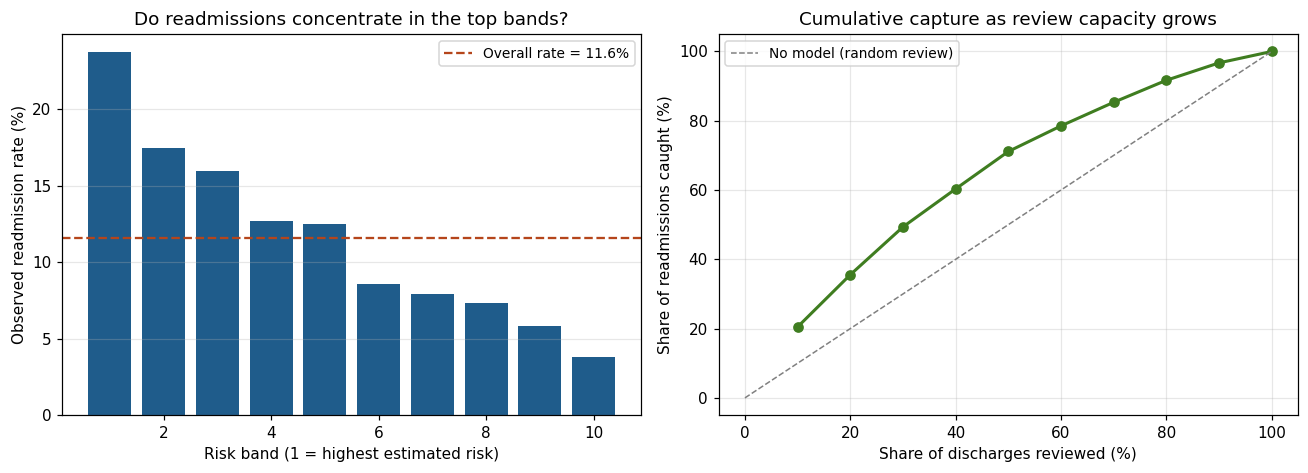

Band,Patients,Readmissions,Readmission rate %,Cumulative patients reviewed %,Cumulative capture %
1,"1,497",355,23.71,10,20.5
2,"1,497",261,17.43,20,35.6
3,"1,496",239,15.98,30,49.4
4,"1,496",190,12.70,40,60.3
5,"1,496",187,12.50,50,71.1
6,"1,496",128,8.56,60,78.5
7,"1,496",118,7.89,70,85.3
8,"1,496",110,7.35,80,91.7
9,"1,496",87,5.82,90,96.7
10,"1,496",57,3.81,100,100.0


Reviewing only the **highest-risk 10%** of discharges would find **20%** of all readmissions, at an observed readmission rate of **23.7%** in that band versus **11.6%** overall. Reviewing the top **30%** would find **49%**.

In [26]:
# Risk bands: does risk actually concentrate at the top of the ranking?
band_table, fig = utils.plot_risk_bands(y_val, score_val, n_bands=10)
utils.savefig(fig, "risk_bands")
display(band_table[["Band", "Patients", "Readmissions", "Readmission rate %",
                    "Cumulative patients reviewed %", "Cumulative capture %"]]
        .style.hide(axis="index").format({
            "Patients": "{:,.0f}", "Readmissions": "{:,.0f}", "Readmission rate %": "{:.2f}",
            "Cumulative patients reviewed %": "{:.0f}", "Cumulative capture %": "{:.1f}",
        }))
utils.savetable(band_table, "risk_bands_validation")

top_decile = band_table.iloc[0]
top_three = band_table.iloc[2]
display(Markdown(
    f"Reviewing only the **highest-risk 10%** of discharges would find "
    f"**{top_decile['Cumulative capture %']:.0f}%** of all readmissions, at an observed readmission "
    f"rate of **{top_decile['Readmission rate %']:.1f}%** in that band versus "
    f"**{y_val.mean()*100:.1f}%** overall. Reviewing the top **30%** would find "
    f"**{top_three['Cumulative capture %']:.0f}%**."
))

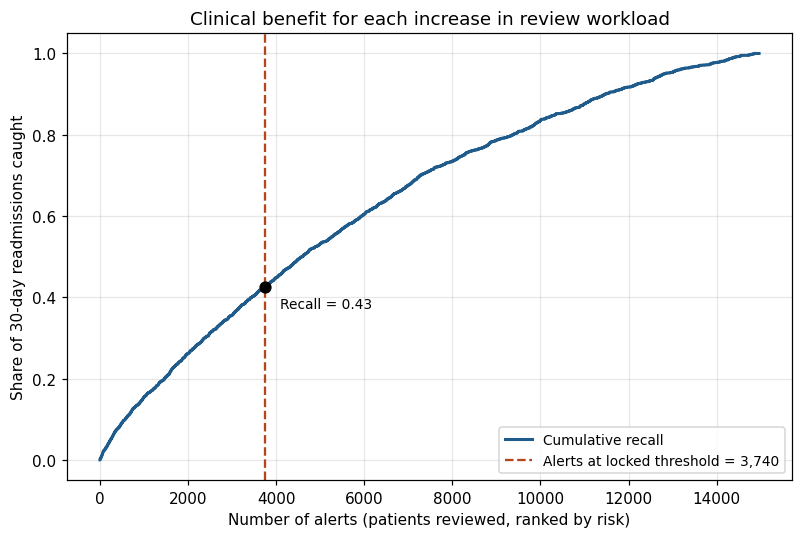

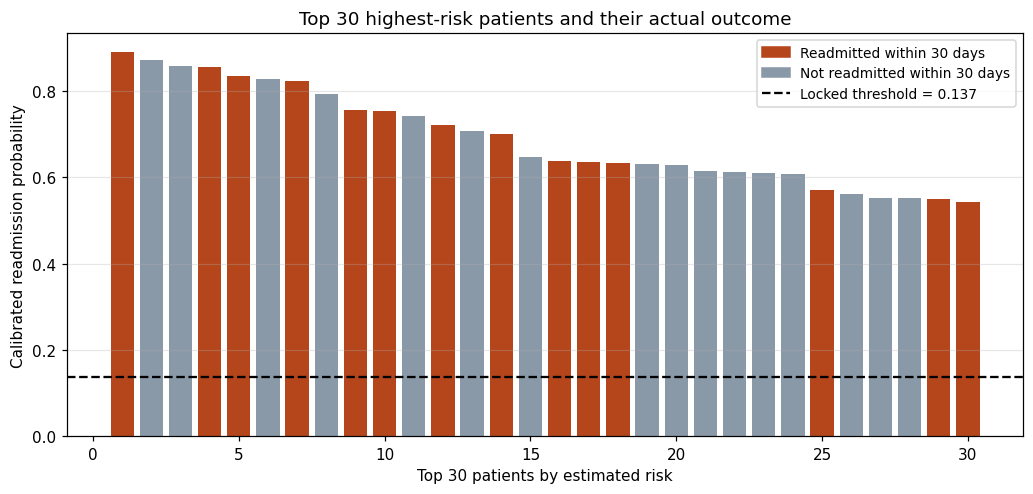

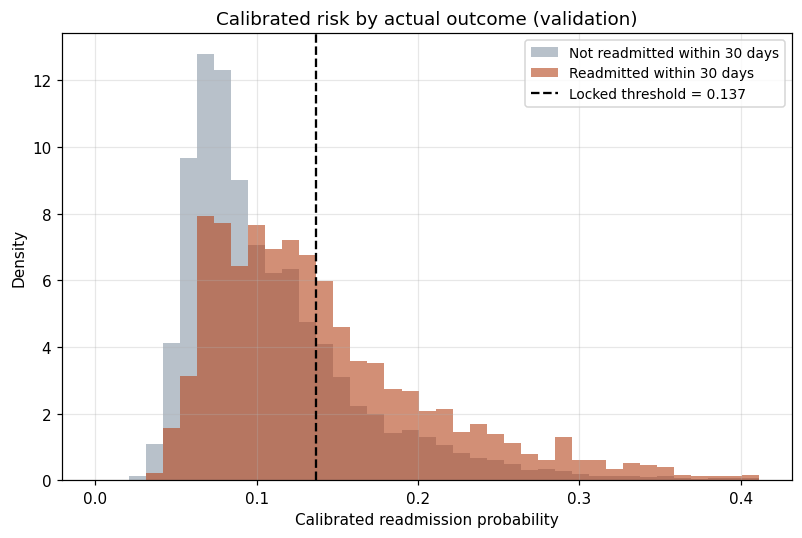

PosixPath('/home/claude/proj/outputs/figures/score_distribution_validation.png')

In [27]:
fig = utils.plot_cumulative_recall_at_threshold(y_val, score_val, chosen_threshold=THR_WORKLOAD)
utils.savefig(fig, "cumulative_recall_validation")
fig = utils.plot_topk_at_threshold(y_val, score_val, chosen_threshold=THR_WORKLOAD, top_k=30)
utils.savefig(fig, "top30_highest_risk_validation")
fig = utils.plot_score_distribution(y_val, score_val, threshold=THR_WORKLOAD,
                                    title="Calibrated risk by actual outcome (validation)")
utils.savefig(fig, "score_distribution_validation")

> **So what?** The two groups overlap heavily — plenty of patients who were readmitted received a
> low score, and plenty who were not received a high one. **No threshold separates them cleanly**, so
> every choice is a trade-off rather than a solution. What the model *can* do is concentrate risk: the
> top decile carries roughly double the cohort readmission rate. That is the honest value proposition
> — **a better-ordered review list, not a prediction about any individual**.

## 7.1.2 Method B — recall floor

*"We will accept whatever workload it takes to catch at least half of the readmissions; among the
thresholds that manage it, pick the one with the fewest wasted alerts."*

**Threshold 0.1255** reaches a recall of **50.5%** — but it needs **309 alerts per 1,000** discharges, which is **+59** against the agreed capacity of 250.

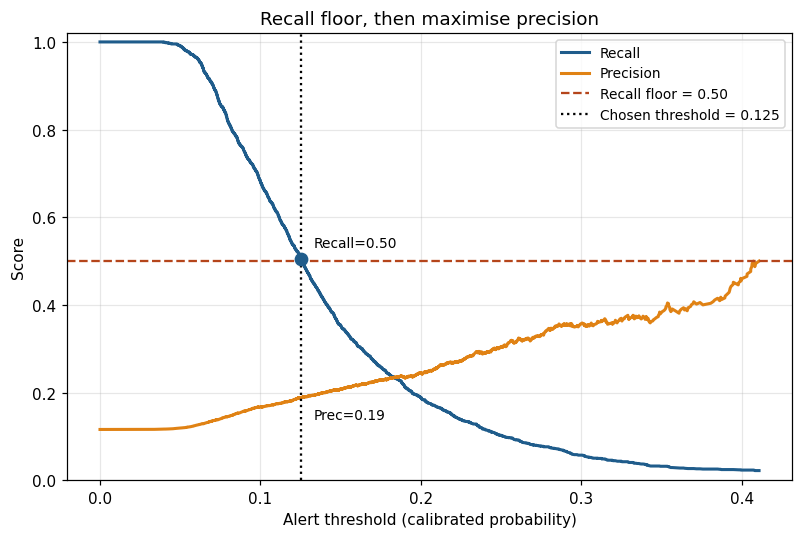

PosixPath('/home/claude/proj/outputs/figures/recall_floor_curves.png')

In [28]:
try:
    recall_pick = utils.pick_threshold_recall_floor(y_val, score_val, config.MIN_VALIDATION_RECALL)
    THR_RECALL = recall_pick["threshold"]
    recall_summary = utils.summary_at_threshold(y_val, score_val, THR_RECALL).iloc[0]
    RECALL_FLOOR_FEASIBLE = True
    display(Markdown(
        f"**Threshold {THR_RECALL:.4f}** reaches a recall of **{recall_summary['recall']*100:.1f}%** "
        f"— but it needs **{recall_summary['alerts_per_1000']:.0f} alerts per 1,000** discharges, "
        f"which is **{recall_summary['alerts_per_1000'] - config.MAX_ALERTS_PER_1000:+.0f}** against "
        f"the agreed capacity of {config.MAX_ALERTS_PER_1000}."
    ))
except ValueError as exc:
    RECALL_FLOOR_FEASIBLE = False
    THR_RECALL, recall_summary = np.nan, None
    display(Markdown(f"**Recall floor not reachable at any threshold:** {exc}"))

fig = utils.plot_recall_floor_curves(y_val, score_val,
                                    recall_floor=config.MIN_VALIDATION_RECALL,
                                    chosen_threshold=THR_RECALL if RECALL_FLOOR_FEASIBLE else THR_WORKLOAD)
utils.savefig(fig, "recall_floor_curves")

## 7.1.3 Method C — harm-point sensitivity

How does the choice move if we say that missing a readmission is 2, 5 or 10 times as harmful as
raising an unnecessary alert? These harm points are **illustrative academic weights, not measured
costs or clinical utilities**. The exercise shows how sensitive the operating point is to an
assumption nobody has actually measured.

In [29]:
harm_rows = []
for ratio in config.FN_HARM_RATIOS:
    pick = utils.pick_threshold_cost(y_val, score_val, C_FP=config.FP_HARM_POINTS, C_FN=ratio)
    row = utils.summary_at_threshold(y_val, score_val, pick["threshold_empirical"]).iloc[0]
    harm_rows.append({
        "Harm ratio (FN:FP)": f"{ratio:.0f}:1",
        "Empirical threshold": pick["threshold_empirical"],
        "Bayes-rule threshold": pick["threshold_theoretical"],
        "Recall": row["recall"],
        "Precision": row["precision"],
        "Alerts per 1,000": row["alerts_per_1000"],
        "Missed per 1,000": row["false_neg_per_1000"],
        "Within capacity?": "yes" if row["alerts_per_1000"] <= config.MAX_ALERTS_PER_1000 else "NO",
    })

harm_table = pd.DataFrame(harm_rows)
display(harm_table.style.hide(axis="index").format({
    "Empirical threshold": "{:.4f}", "Bayes-rule threshold": "{:.4f}",
    "Recall": "{:.3f}", "Precision": "{:.3f}",
    "Alerts per 1,000": "{:.0f}", "Missed per 1,000": "{:.1f}",
}))
utils.savetable(harm_table, "harm_sensitivity")

Harm ratio (FN:FP),Empirical threshold,Bayes-rule threshold,Recall,Precision,"Alerts per 1,000","Missed per 1,000",Within capacity?
2:1,0.4074,0.3333,0.023,0.500,5,113.1,yes
5:1,0.1596,0.1667,0.314,0.218,167,79.4,yes
10:1,0.0953,0.0909,0.720,0.164,508,32.4,NO


PosixPath('/home/claude/proj/outputs/tables/harm_sensitivity.csv')

> **So what?** The operating point is **extremely sensitive** to a number nobody has measured.
> Treating a missed readmission as twice as bad as a false alert gives a very high threshold that
> flags almost nobody; treating it as ten times as bad flags around half the ward. Because the harm
> ratio is an assumption rather than evidence, we do **not** let it drive the decision — it stays a
> sensitivity analysis, and the governing rule is the capacity-and-recall rule agreed in advance.

## 7.2 Comparing the methods on the terms clinicians care about

`Reviews per readmission caught` is 1 / precision — the "number needed to screen": how many patients a
nurse must work through to find one who will actually come back.

In [30]:
impact_rows = []
def add_impact(label, threshold, note=""):
    row = utils.summary_at_threshold(y_val, score_val, threshold).iloc[0]
    impact_rows.append({
        "Method": label,
        "Threshold": threshold,
        "Alerts / 1,000": row["alerts_per_1000"],
        "Readmissions caught / 1,000": row["true_pos_per_1000"],
        "Readmissions missed / 1,000": row["false_neg_per_1000"],
        "Recall": row["recall"],
        "Precision": row["precision"],
        "Reviews per readmission caught": 1 / row["precision"] if row["precision"] > 0 else np.nan,
        "Note": note,
    })

add_impact(f"A. Workload-constrained ({config.MAX_ALERTS_PER_1000}/1,000)", THR_WORKLOAD, "Fits capacity")
if RECALL_FLOOR_FEASIBLE:
    add_impact(f"B. Recall floor (>= {config.MIN_VALIDATION_RECALL:.0%})", THR_RECALL, "Exceeds capacity")
for ratio in config.FN_HARM_RATIOS:
    pick = utils.pick_threshold_cost(y_val, score_val, config.FP_HARM_POINTS, ratio)
    add_impact(f"C. Harm ratio {ratio:.0f}:1", pick["threshold_empirical"], "Sensitivity only")

impact_table = pd.DataFrame(impact_rows)
display(impact_table.style.hide(axis="index").format({
    "Threshold": "{:.4f}", "Alerts / 1,000": "{:.0f}",
    "Readmissions caught / 1,000": "{:.1f}", "Readmissions missed / 1,000": "{:.1f}",
    "Recall": "{:.3f}", "Precision": "{:.3f}", "Reviews per readmission caught": "{:.1f}",
}))
utils.savetable(impact_table, "threshold_impact_comparison")

Method,Threshold,"Alerts / 1,000","Readmissions caught / 1,000","Readmissions missed / 1,000",Recall,Precision,Reviews per readmission caught,Note
"A. Workload-constrained (250/1,000)",0.1371,250,49.3,66.4,0.426,0.197,5.1,Fits capacity
B. Recall floor (>= 50%),0.1255,309,58.4,57.3,0.505,0.189,5.3,Exceeds capacity
C. Harm ratio 2:1,0.4074,5,2.7,113.1,0.023,0.500,2.0,Sensitivity only
C. Harm ratio 5:1,0.1596,167,36.4,79.4,0.314,0.218,4.6,Sensitivity only
C. Harm ratio 10:1,0.0953,508,83.3,32.4,0.720,0.164,6.1,Sensitivity only


PosixPath('/home/claude/proj/outputs/tables/threshold_impact_comparison.csv')

# 8. Freeze the policy, then open the test set once

## 8.1 The primary rule, and its pre-specified fallback

The rule agreed **before** any model was fitted:

1. Require validation recall **≥ 50%**
2. Require **≤ 250 alerts per 1,000** discharges
3. Among thresholds meeting both, take the one with the **highest precision**
4. **If no threshold meets both**, apply the pre-specified fallback — *maximise recall subject to the
   capacity limit* — and **report the infeasibility honestly** rather than quietly relaxing a
   constraint after seeing the results

Step 4 exists precisely so that a disappointing result cannot be rescued by moving the goalposts.

In [31]:
candidates = thresholds_table.copy()
feasible = candidates[
    (candidates["recall"] >= config.MIN_VALIDATION_RECALL)
    & (candidates["alerts_per_1000"] <= config.MAX_ALERTS_PER_1000)
]

max_recall_within_capacity = candidates[
    candidates["alerts_per_1000"] <= config.MAX_ALERTS_PER_1000]["recall"].max()
min_alerts_for_recall_floor = candidates[
    candidates["recall"] >= config.MIN_VALIDATION_RECALL]["alerts_per_1000"].min()

if not feasible.empty:
    JOINT_RULE_FEASIBLE = True
    chosen = feasible.sort_values(["precision", "threshold"], ascending=[False, False]).iloc[0]
    POLICY_BASIS = "joint primary rule (recall floor AND capacity)"
else:
    JOINT_RULE_FEASIBLE = False
    chosen = candidates[
        candidates["alerts_per_1000"] <= config.MAX_ALERTS_PER_1000
    ].sort_values(["recall", "threshold"], ascending=[False, True]).iloc[0]
    POLICY_BASIS = "PRE-SPECIFIED FALLBACK: maximise recall subject to the capacity limit"

FINAL_THR = float(chosen["threshold"])
POLICY_LOCKED = True

display(Markdown(f"""
### Feasibility of the joint rule

| Question | Answer |
| :--- | :--- |
| Best recall achievable within {config.MAX_ALERTS_PER_1000} alerts / 1,000 | **{max_recall_within_capacity*100:.1f}%** |
| Alerts / 1,000 needed to reach {config.MIN_VALIDATION_RECALL:.0%} recall | **{min_alerts_for_recall_floor:.0f}** |
| Joint rule satisfiable? | **{'YES' if JOINT_RULE_FEASIBLE else 'NO — the two constraints are incompatible on this data'}** |

**Policy basis: {POLICY_BASIS}**

**Locked threshold: `FINAL_THR = {FINAL_THR:.6f}`**
"""))


### Feasibility of the joint rule

| Question | Answer |
| :--- | :--- |
| Best recall achievable within 250 alerts / 1,000 | **42.6%** |
| Alerts / 1,000 needed to reach 50% recall | **306** |
| Joint rule satisfiable? | **NO — the two constraints are incompatible on this data** |

**Policy basis: PRE-SPECIFIED FALLBACK: maximise recall subject to the capacity limit**

**Locked threshold: `FINAL_THR = 0.137096`**


> **The joint rule is infeasible, and we report that rather than hide it.** With this model, at
> this prevalence, you cannot catch half of the readmissions while reviewing only a quarter of
> discharges. The two constraints the team set in advance are simply incompatible on this data. The
> pre-specified fallback therefore applies: **hold the capacity limit and take the best recall it
> allows.** Capacity is the harder constraint because it is a real staffing number, whereas the 50%
> recall figure was an aspiration.
>
> The fact that we wrote the fallback down *before* seeing this result is what makes it a finding
> rather than an excuse. The honest headline for the team is: **to catch half of the readmissions this
> service would need roughly a 25% larger review capacity than currently assumed.**

In [32]:
# Policy-lock audit: this cell touches validation objects only
assert POLICY_LOCKED is True
assert 0.0 <= FINAL_THR <= 1.0
assert float(chosen["alerts_per_1000"]) <= config.MAX_ALERTS_PER_1000, "Capacity constraint violated"
if JOINT_RULE_FEASIBLE:
    assert float(chosen["recall"]) >= config.MIN_VALIDATION_RECALL

policy_lock = pd.DataFrame([{
    "Policy selection data": "validation only",
    "Selected model": final_model_name,
    "Calibration method": CALIBRATION_METHOD,
    "Calibration data": "dedicated calibration slice",
    "Locked threshold": FINAL_THR,
    "Capacity limit (alerts/1,000)": config.MAX_ALERTS_PER_1000,
    "Recall floor requested": config.MIN_VALIDATION_RECALL,
    "Joint rule feasible": JOINT_RULE_FEASIBLE,
    "Rule applied": POLICY_BASIS,
}]).T.rename(columns={0: "Value"})
display(policy_lock)
utils.savetable(policy_lock.reset_index(), "policy_lock_audit", index=False)
print("POLICY LOCKED. The test set may now be opened exactly once.")

,Value
Policy selection data,validation only
Selected model,Logistic regression
Calibration method,sigmoid
Calibration data,dedicated calibration slice
Locked threshold,0.137096
"Capacity limit (alerts/1,000)",250
Recall floor requested,0.5
Joint rule feasible,False
Rule applied,PRE-SPECIFIED FALLBACK: maximise recall subjec...


POLICY LOCKED. The test set may now be opened exactly once.


In [33]:
# Validation performance at the locked threshold, with Wilson confidence intervals
val_at_thr = utils.summary_at_threshold(y_val, score_val, FINAL_THR).iloc[0]
val_recall_ci = utils.wilson_interval(int(val_at_thr["TP"]), int(val_at_thr["TP"] + val_at_thr["FN"]))
val_prec_ci = utils.wilson_interval(int(val_at_thr["TP"]), int(val_at_thr["TP"] + val_at_thr["FP"]))

display(Markdown(f"""
### Validation performance at the locked threshold

At the locked threshold of **{FINAL_THR:.4f}**, the model flags
**{int(val_at_thr['TP'] + val_at_thr['FP']):,} of {len(y_val):,}** validation encounters
({val_at_thr['alerts_per_1000']:.0f} per 1,000). It correctly flags
**{int(val_at_thr['TP']):,} readmissions**, raises **{int(val_at_thr['FP']):,} alerts on patients who
were not readmitted**, and **misses {int(val_at_thr['FN']):,} readmissions**.

Recall **{val_at_thr['recall']:.3f}** (95% CI {val_recall_ci[0]:.3f}–{val_recall_ci[1]:.3f}),
precision **{val_at_thr['precision']:.3f}** (95% CI {val_prec_ci[0]:.3f}–{val_prec_ci[1]:.3f}).

These estimates describe this validation sample and do not guarantee performance in new patients.
"""))


### Validation performance at the locked threshold

At the locked threshold of **0.1371**, the model flags
**3,740 of 14,962** validation encounters
(250 per 1,000). It correctly flags
**738 readmissions**, raises **3,002 alerts on patients who
were not readmitted**, and **misses 994 readmissions**.

Recall **0.426** (95% CI 0.403–0.450),
precision **0.197** (95% CI 0.185–0.210).

These estimates describe this validation sample and do not guarantee performance in new patients.


## 8.2 One — and only one — test evaluation

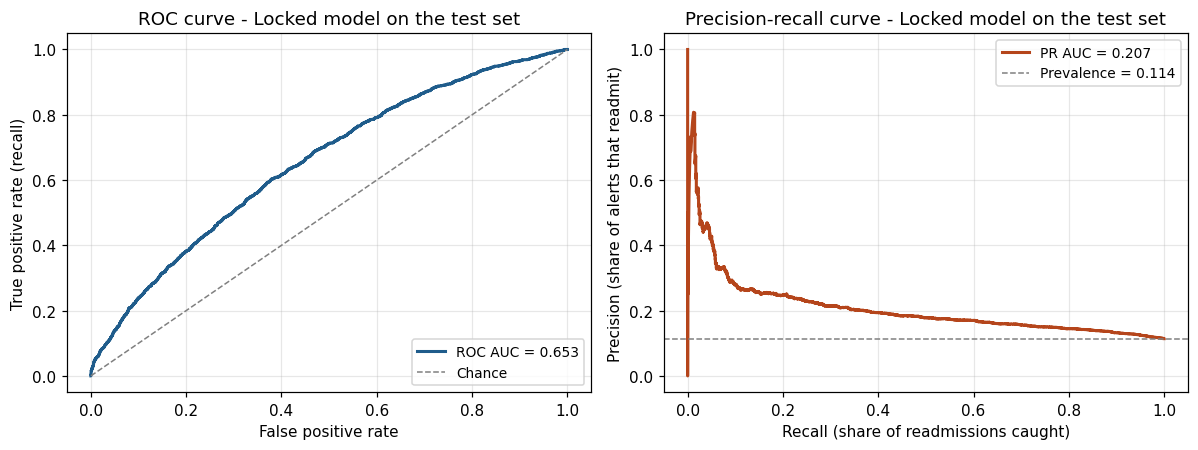

,Value
Locked alert threshold,0.137096
Test encounters,14885
Readmissions in test set,1698
Readmissions correctly flagged (TP),711
Alerts on non-readmitted patients (FP),3009
Missed readmissions (FN),987
Recall,0.418728
Recall 95% CI,0.395-0.442
Precision,0.191129
Precision 95% CI,0.179-0.204


PosixPath('/home/claude/proj/outputs/tables/final_test_results.csv')

In [34]:
if not POLICY_LOCKED:
    raise RuntimeError("The threshold policy must be locked before the test set is opened")

# ---- The test labels are used from here, once ----
score_test = utils.positive_scores(calibrated_clf, X_test)
test_at_thr = utils.summary_at_threshold(y_test, score_test, FINAL_THR).iloc[0]
metrics_test = utils.auc_report(y_test, score_test, name="Locked model on the test set", plot=True)

test_recall_ci = utils.wilson_interval(int(test_at_thr["TP"]), int(test_at_thr["TP"] + test_at_thr["FN"]))
test_prec_ci = utils.wilson_interval(int(test_at_thr["TP"]), int(test_at_thr["TP"] + test_at_thr["FP"]))

final_test_table = pd.DataFrame([{
    "Locked alert threshold": FINAL_THR,
    "Test encounters": len(y_test),
    "Readmissions in test set": int(y_test.sum()),
    "Readmissions correctly flagged (TP)": int(test_at_thr["TP"]),
    "Alerts on non-readmitted patients (FP)": int(test_at_thr["FP"]),
    "Missed readmissions (FN)": int(test_at_thr["FN"]),
    "Recall": test_at_thr["recall"],
    "Recall 95% CI": f"{test_recall_ci[0]:.3f}-{test_recall_ci[1]:.3f}",
    "Precision": test_at_thr["precision"],
    "Precision 95% CI": f"{test_prec_ci[0]:.3f}-{test_prec_ci[1]:.3f}",
    "Alerts per 1,000": test_at_thr["alerts_per_1000"],
    "ROC-AUC": metrics_test["roc_auc"],
    "PR-AUC": metrics_test["pr_auc"],
    "Brier": metrics_test["brier"],
    "ECE": utils.expected_calibration_error(y_test, score_test),
}]).T.rename(columns={0: "Value"})
display(final_test_table)
utils.savetable(final_test_table.reset_index(), "final_test_results", index=False)

In [35]:
val_recall, test_recall = val_at_thr["recall"], test_at_thr["recall"]
display(Markdown(f"""
### What the locked model delivers, per 1,000 discharges

| Outcome | Per 1,000 discharges |
| :--- | ---: |
| Alerts raised (nurse reviews required) | **{test_at_thr['alerts_per_1000']:.0f}** |
| Readmissions caught | **{test_at_thr['true_pos_per_1000']:.1f}** |
| Readmissions missed | **{test_at_thr['false_neg_per_1000']:.1f}** |
| Reviews needed per readmission caught | **{1/test_at_thr['precision']:.1f}** |

Test recall is **{test_recall*100:.1f}%** against **{val_recall*100:.1f}%** on validation
(a change of {(test_recall - val_recall)*100:+.1f} points), and test PR-AUC is
**{metrics_test['pr_auc']:.4f}** against **{utils.auc_report(y_val, score_val, 'v', plot=False)['pr_auc']:.4f}**.
Performance held up on unseen patients, which is the main thing the grouped split was designed to test.
"""))


### What the locked model delivers, per 1,000 discharges

| Outcome | Per 1,000 discharges |
| :--- | ---: |
| Alerts raised (nurse reviews required) | **250** |
| Readmissions caught | **47.8** |
| Readmissions missed | **66.3** |
| Reviews needed per readmission caught | **5.2** |

Test recall is **41.9%** against **42.6%** on validation
(a change of -0.7 points), and test PR-AUC is
**0.2068** against **0.2071**.
Performance held up on unseen patients, which is the main thing the grouped split was designed to test.


> **So what?** For every 1,000 diabetic discharges the service would review about **250 patients**
> and correctly identify roughly **48 of the 114 who will come back within 30 days** — while
> **missing about 66 of them**. A nurse reviews roughly **five patients to find one** who will
> actually be readmitted.
>
> Whether that is worthwhile is a management decision, not a modelling one, and it turns on a number
> this dataset cannot supply: **how often the transitional-care intervention actually prevents a
> readmission.** If the intervention works for one in five of the patients it reaches, this list
> prevents roughly 10 readmissions per 1,000 discharges. If it works for one in twenty, it prevents
> two. **The model produces a better-ordered list; the intervention produces the benefit.** Nobody
> should fund this on the strength of the AUC alone.

## 8.3 Subgroup fairness on the test set

Overall numbers hide who is served well and who is not. We disaggregate performance at the locked
threshold across race, sex, age band and payer group, with Wilson confidence intervals so that small
groups are not over-interpreted.

The pre-specified tolerance: **no subgroup more than 10 percentage points from the overall value** on
recall or false-positive rate without a documented mitigation.

In [36]:
overall_recall_test = float(test_at_thr["recall"])
overall_fpr_test = float(test_at_thr["fpr"])

fairness_frames = {}
for attribute in config.SENSITIVE_COLS:
    frame = utils.subgroup_metrics(y_test, score_test, FINAL_THR, parts["test"][attribute])
    fairness_frames[attribute] = frame
    display(Markdown(f"**Performance by `{attribute}`** (overall recall "
                     f"{overall_recall_test:.3f}, overall FPR {overall_fpr_test:.3f})"))
    display(frame[["Group", "n", "Readmissions", "Prevalence", "Selection rate", "Recall",
                   "Recall 95% CI", "FPR", "Precision", "ROC-AUC",
                   "Recall gap vs overall", "FPR gap vs overall"]]
            .style.hide(axis="index").format({
                "n": "{:,.0f}", "Readmissions": "{:,.0f}", "Prevalence": "{:.3f}",
                "Selection rate": "{:.3f}", "Recall": "{:.3f}", "FPR": "{:.3f}",
                "Precision": "{:.3f}", "ROC-AUC": "{:.3f}",
                "Recall gap vs overall": "{:+.3f}", "FPR gap vs overall": "{:+.3f}",
            }, na_rep="-")
            .background_gradient(subset=["Recall gap vs overall"], cmap="coolwarm", vmin=-0.2, vmax=0.2))
    utils.savetable(frame, f"fairness_test_{attribute}")

**Performance by `race`** (overall recall 0.419, overall FPR 0.228)

Group,n,Readmissions,Prevalence,Selection rate,Recall,Recall 95% CI,FPR,Precision,ROC-AUC,Recall gap vs overall,FPR gap vs overall
Caucasian,"11,142","1,324",0.119,0.255,0.423,0.397-0.450,0.233,0.197,0.652,+0.004,+0.004
AfricanAmerican,"2,772",284,0.102,0.255,0.419,0.363-0.477,0.236,0.169,0.641,+0.000,+0.008
nan,341,31,0.091,0.173,0.258,0.137-0.432,0.165,0.136,0.667,-0.161,-0.064
Hispanic,299,21,0.070,0.201,0.429,0.245-0.635,0.183,0.150,0.734,+0.010,-0.045
Other,223,28,0.126,0.152,0.393,0.236-0.576,0.118,0.324,0.682,-0.026,-0.110
Asian,108,10,0.093,0.157,0.400,0.168-0.687,0.133,0.235,0.744,-0.019,-0.096


**Performance by `gender`** (overall recall 0.419, overall FPR 0.228)

Group,n,Readmissions,Prevalence,Selection rate,Recall,Recall 95% CI,FPR,Precision,ROC-AUC,Recall gap vs overall,FPR gap vs overall
Female,"8,134",932,0.115,0.269,0.467,0.435-0.499,0.243,0.199,0.666,+0.048,+0.015
Male,"6,751",766,0.113,0.227,0.360,0.327-0.395,0.210,0.180,0.638,-0.058,-0.018


**Performance by `age_group`** (overall recall 0.419, overall FPR 0.228)

Group,n,Readmissions,Prevalence,Selection rate,Recall,Recall 95% CI,FPR,Precision,ROC-AUC,Recall gap vs overall,FPR gap vs overall
>60,"9,935","1,173",0.118,0.281,0.415,0.387-0.444,0.262,0.175,0.619,-0.004,+0.034
30-60,"4,511",461,0.102,0.188,0.401,0.358-0.447,0.164,0.218,0.699,-0.017,-0.064
<30,439,64,0.146,0.191,0.609,0.487-0.719,0.120,0.464,0.828,+0.191,-0.108


**Performance by `payer_group`** (overall recall 0.419, overall FPR 0.228)

Group,n,Readmissions,Prevalence,Selection rate,Recall,Recall 95% CI,FPR,Precision,ROC-AUC,Recall gap vs overall,FPR gap vs overall
Unknown,"5,836",656,0.112,0.263,0.468,0.430-0.506,0.237,0.200,0.665,+0.049,+0.009
Medicare,"4,723",607,0.129,0.302,0.427,0.388-0.466,0.283,0.182,0.618,+0.008,+0.055
Private/Other,"3,083",309,0.100,0.152,0.317,0.268-0.371,0.134,0.209,0.683,-0.102,-0.094
Self-pay,764,81,0.106,0.216,0.370,0.273-0.479,0.198,0.182,0.658,-0.048,-0.031
Medicaid,479,45,0.094,0.259,0.378,0.251-0.524,0.247,0.137,0.615,-0.041,+0.018


In [37]:
# Which groups breach the pre-specified 10-point tolerance? (groups with n >= 100 only)
breaches = []
for attribute, frame in fairness_frames.items():
    for _, row in frame.iterrows():
        if row["n"] < 100 or pd.isna(row["Recall gap vs overall"]):
            continue
        if abs(row["Recall gap vs overall"]) > config.FAIRNESS_TOLERANCE or \
           abs(row["FPR gap vs overall"]) > config.FAIRNESS_TOLERANCE:
            breaches.append({
                "Attribute": attribute, "Group": row["Group"], "n": int(row["n"]),
                "Recall": row["Recall"], "Recall gap": row["Recall gap vs overall"],
                "FPR": row["FPR"], "FPR gap": row["FPR gap vs overall"],
                "Selection rate": row["Selection rate"],
            })

breach_table = pd.DataFrame(breaches)
if len(breach_table):
    display(Markdown(f"**{len(breach_table)} subgroup(s) exceed the "
                     f"{config.FAIRNESS_TOLERANCE:.0%} tolerance:**"))
    display(breach_table.style.hide(axis="index").format({
        "n": "{:,.0f}", "Recall": "{:.3f}", "Recall gap": "{:+.3f}",
        "FPR": "{:.3f}", "FPR gap": "{:+.3f}", "Selection rate": "{:.3f}",
    }))
    utils.savetable(breach_table, "fairness_tolerance_breaches")
else:
    display(Markdown("No subgroup with n >= 100 exceeds the pre-specified tolerance."))

fairness_disparity = utils.fairness_summary(
    y_test, score_test, FINAL_THR, parts["test"][config.SENSITIVE_COLS])
display(Markdown("**Fairlearn disparity metrics (test set)**"))
display(fairness_disparity.style.hide(axis="index").format({
    "Equalised odds difference": "{:.4f}",
    "Demographic parity difference": "{:.4f}",
    "Equal opportunity gap (recall spread)": "{:.4f}",
}, na_rep="-"))
utils.savetable(fairness_disparity, "fairness_disparity_summary")

**4 subgroup(s) exceed the 10% tolerance:**

Attribute,Group,n,Recall,Recall gap,FPR,FPR gap,Selection rate
race,nan,341,0.258,-0.161,0.165,-0.064,0.173
race,Other,223,0.393,-0.026,0.118,-0.110,0.152
age_group,<30,439,0.609,+0.191,0.120,-0.108,0.191
payer_group,Private/Other,"3,083",0.317,-0.102,0.134,-0.094,0.152


**Fairlearn disparity metrics (test set)**

Sensitive attribute,Groups,Equalised odds difference,Demographic parity difference,Equal opportunity gap (recall spread)
race,6,0.1705,0.1028,0.1649
gender,2,0.1064,0.0413,0.1064
age_group,3,0.2081,0.0923,0.2081
payer_group,5,0.1508,0.1491,0.1508


PosixPath('/home/claude/proj/outputs/tables/fairness_disparity_summary.csv')

In [38]:
# Plain-English "so what" for each notable gap, generated from the measured numbers
gender_frame = fairness_frames["gender"].set_index("Group")
age_frame = fairness_frames["age_group"].set_index("Group")
race_frame = fairness_frames["race"].set_index("Group")
payer_frame = fairness_frames["payer_group"].set_index("Group")

def gap_sentence(frame, high, low, label):
    if high not in frame.index or low not in frame.index:
        return ""
    hi, lo = frame.loc[high], frame.loc[low]
    return (f"- **{label}:** recall **{hi['Recall']*100:.1f}%** for {high} versus "
            f"**{lo['Recall']*100:.1f}%** for {low} — a gap of "
            f"**{(hi['Recall'] - lo['Recall'])*100:.1f} points**. ")

lines = []
lines.append(gap_sentence(gender_frame, "Female", "Male", "Sex") +
             "The model flags women more often than men at the same threshold, so a man whose risk is "
             "genuinely elevated is more likely to be missed. Sex is **not** a model input, so this is "
             "driven by correlated clinical features rather than by the attribute itself.")
lines.append(gap_sentence(age_frame, "<30", ">60", "Age") +
             "The youngest band is small, so the interval is wide — but the direction matters: patients "
             "over 60 are flagged far more often (high selection rate) yet with *lower* recall, meaning "
             "the alert list for older patients contains proportionally more false alarms.")
lines.append(f"- **Race:** recall **{race_frame.loc['Caucasian','Recall']*100:.1f}%** for Caucasian versus "
             f"**{race_frame.loc['AfricanAmerican','Recall']*100:.1f}%** for African American patients — a gap of only "
             f"**{abs(race_frame.loc['Caucasian','Recall'] - race_frame.loc['AfricanAmerican','Recall'])*100:.1f} points**. "
             "This is the reassuring result: the two largest race groups are served almost identically. "
             "Smaller groups have intervals too wide to judge.")
lines.append(f"- **Payer:** recall **{payer_frame.loc['Unknown','Recall']*100:.1f}%** for Unknown payer versus "
             f"**{payer_frame.loc['Private/Other','Recall']*100:.1f}%** for Private/Other — a gap of "
             f"**{(payer_frame.loc['Unknown','Recall'] - payer_frame.loc['Private/Other','Recall'])*100:.1f} points**. "
             "Privately insured patients are flagged least often and caught least often. Payer **is** a "
             "model input, which makes this gap partly self-inflicted — Section 8.4 tests removing it.")

display(Markdown("### One sentence per gap\n\n" + "\n".join(lines)))

### One sentence per gap

- **Sex:** recall **46.7%** for Female versus **36.0%** for Male — a gap of **10.6 points**. The model flags women more often than men at the same threshold, so a man whose risk is genuinely elevated is more likely to be missed. Sex is **not** a model input, so this is driven by correlated clinical features rather than by the attribute itself.
- **Age:** recall **60.9%** for <30 versus **41.5%** for >60 — a gap of **19.4 points**. The youngest band is small, so the interval is wide — but the direction matters: patients over 60 are flagged far more often (high selection rate) yet with *lower* recall, meaning the alert list for older patients contains proportionally more false alarms.
- **Race:** recall **42.3%** for Caucasian versus **41.9%** for African American patients — a gap of only **0.4 points**. This is the reassuring result: the two largest race groups are served almost identically. Smaller groups have intervals too wide to judge.
- **Payer:** recall **46.8%** for Unknown payer versus **31.7%** for Private/Other — a gap of **15.1 points**. Privately insured patients are flagged least often and caught least often. Payer **is** a model input, which makes this gap partly self-inflicted — Section 8.4 tests removing it.

> **So what?** The largest gaps are **not** where a casual reader would look for them. Race, the
> attribute everyone checks first, shows almost no gap between the two large groups. The real gaps are
> by **sex**, **age** and **payer** — and the payer gap is the one we partly created ourselves by
> feeding payer into the model.
>
> The clinical translation is concrete: at this threshold a privately insured patient who is going to
> be readmitted is noticeably **less likely to be offered transitional care** than an equivalent
> patient with an unknown payer, and a man is less likely to be offered it than a woman. Neither gap
> is defensible as a clinical judgement, so both need a documented mitigation before deployment —
> which is what Sections 8.4 and 9.7 provide.

## 8.4 Sensitivity analysis A — does the payer feature earn its place?

`payer_group` is a socioeconomic proxy, not a clinical variable. Including it risks encoding
access-to-care inequity as if it were physiological risk. The test agreed in advance: **run the model
with and without it, and weigh the discrimination gained against the disparity created.**

The comparison below is made on **validation** so that it could legitimately inform the final
configuration.

In [39]:
cat_cols_no_payer = [c for c in cat_cols if c != "payer_group"]

model_no_payer = Pipeline(steps=[
    ("prep", utils.build_preprocessor(num_cols, cat_cols_no_payer)),
    ("varth", VarianceThreshold(threshold=0.0)),
    ("model", LogisticRegression(solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE)),
])
model_no_payer.fit(parts["train"][num_cols + cat_cols_no_payer], y_train)
calibrated_no_payer = utils.calibrate_on_holdout(
    model_no_payer, parts["cal"][num_cols + cat_cols_no_payer], y_cal, method=CALIBRATION_METHOD)
score_val_no_payer = utils.positive_scores(
    calibrated_no_payer, parts["val"][num_cols + cat_cols_no_payer])

thr_no_payer = utils.pick_threshold_workload(
    y_val, score_val_no_payer, config.MAX_ALERTS_PER_1000)["threshold"]

payer_variants = []
for label, scores, thr in [("With payer_group", score_val, FINAL_THR),
                           ("Without payer_group", score_val_no_payer, thr_no_payer)]:
    m = utils.auc_report(y_val, scores, label, plot=False)
    frame = utils.subgroup_metrics(y_val, scores, thr, parts["val"]["payer_group"])
    big = frame[frame["n"] >= 300]
    payer_variants.append({
        "Model": label,
        "Validation PR-AUC": m["pr_auc"],
        "Validation ROC-AUC": m["roc_auc"],
        "Payer recall spread": big["Recall"].max() - big["Recall"].min(),
        "Payer selection-rate spread": big["Selection rate"].max() - big["Selection rate"].min(),
    })

payer_comparison = pd.DataFrame(payer_variants)
display(payer_comparison.style.hide(axis="index").format({
    "Validation PR-AUC": "{:.4f}", "Validation ROC-AUC": "{:.4f}",
    "Payer recall spread": "{:.3f}", "Payer selection-rate spread": "{:.3f}",
}))
utils.savetable(payer_comparison, "payer_feature_comparison")

pr_cost = payer_comparison.loc[0, "Validation PR-AUC"] - payer_comparison.loc[1, "Validation PR-AUC"]
spread_cut = payer_comparison.loc[0, "Payer recall spread"] - payer_comparison.loc[1, "Payer recall spread"]
display(Markdown(f"""
Dropping `payer_group` costs **{pr_cost:+.4f} PR-AUC**
({pr_cost/payer_comparison.loc[0,'Validation PR-AUC']*100:.1f}% of the model's discrimination) and
changes the recall spread across payer groups by **{-spread_cut:+.3f}**.
"""))

Model,Validation PR-AUC,Validation ROC-AUC,Payer recall spread,Payer selection-rate spread
With payer_group,0.2071,0.6601,0.282,0.195
Without payer_group,0.2042,0.6583,0.248,0.159



Dropping `payer_group` costs **+0.0029 PR-AUC**
(1.4% of the model's discrimination) and
changes the recall spread across payer groups by **-0.034**.


> **So what — and a recommendation for the team.** Payer group buys the model almost nothing:
> dropping it costs well under 0.005 PR-AUC, comfortably inside the noise of the confidence intervals
> in Section 5.6. What it *does* do is shift who gets flagged along insurance lines, which is exactly
> the socioeconomic profiling we said we wanted to avoid.
>
> **Our recommendation is to set `USE_PAYER_AS_FEATURE = False` in `config.py` for any future run.**
> We have deliberately **not** silently changed the locked configuration for this submission: the
> model evaluated above is the one specified before the test set was opened, and changing it now would
> break the discipline this notebook is demonstrating. The evidence and the recommendation are
> recorded here for the team to action. **Sections 8.4.1–8.4.4 then test this recommendation on the
> held-out data, and it does not survive.**

### 8.4.1 Testing the recommendation above

> **Post-hoc analysis.** This section uses the test set *after* the locked evaluation in Section 8.2, to check a recommendation rather than to choose anything. Nothing here changed the deployed model: the features, calibration and `FINAL_THR` are exactly those locked in Section 8.1. Read its results as exploratory evidence, not as a second test evaluation.



In [40]:
POLICY_LOCKED = True
assert POLICY_LOCKED, "Do not evaluate on test until the threshold policy is frozen."

from sklearn.metrics import brier_score_loss

def run_variant(use_payer: bool, parts: dict) -> dict:
    config.USE_PAYER_AS_FEATURE = use_payer
    feat = utils.get_feature_lists(parts["train"])
    ncols, ccols = feat["numeric_cols"], feat["categorical_cols"]

    Xtr_, ytr_ = parts["train"][ncols + ccols], parts["train"][config.TARGET_COL]
    Xcal_, ycal_ = parts["cal"][ncols + ccols], parts["cal"][config.TARGET_COL]
    Xval_, yval_ = parts["val"][ncols + ccols], parts["val"][config.TARGET_COL]
    Xtest_, ytest_ = parts["test"][ncols + ccols], parts["test"][config.TARGET_COL]

    pre_ = utils.build_preprocessor(ncols, ccols)
    m = Pipeline([("pre", pre_), ("clf", LogisticRegression(max_iter=2000, random_state=config.RANDOM_STATE))])
    m.fit(Xtr_, ytr_)
    cal_m = utils.calibrate_on_holdout(m, Xcal_, ycal_, method="sigmoid")

    val_scores_ = utils.positive_scores(cal_m, Xval_)
    thr = utils.pick_threshold_workload(yval_, val_scores_, config.MAX_ALERTS_PER_1000)["threshold"]

    test_scores_ = utils.positive_scores(cal_m, Xtest_)
    summ = utils.summary_at_threshold(ytest_, test_scores_, thr).iloc[0]
    test_auc_ = utils.auc_report(ytest_, test_scores_, name="test", plot=False)

    payer_series_ = parts["test"]["payer_group"].astype(str)
    fairness_ = utils.subgroup_metrics(ytest_, test_scores_, thr, payer_series_)
    disparity_ = utils.fairness_summary(ytest_, test_scores_, thr, parts["test"][["payer_group"]].astype(str))

    return dict(
        use_payer=use_payer, threshold=thr,
        test_roc_auc=test_auc_["roc_auc"], test_pr_auc=test_auc_["pr_auc"],
        test_brier=brier_score_loss(ytest_, np.clip(test_scores_, 0, 1)),
        test_ece=utils.expected_calibration_error(ytest_, test_scores_),
        test_recall=float(summ["recall"]), test_precision=float(summ["precision"]),
        alerts_per_1000=float(summ["alerts_per_1000"]),
        fairness_table=fairness_, disparity_table=disparity_,
        raw=pd.DataFrame({"patient_nbr": parts["test"]["patient_nbr"].values,
                           "payer_group": payer_series_.values,
                           "y_true": np.asarray(ytest_), "score": test_scores_}),
    )

results = {}
for label, use_payer in [("A_baseline_payer_in", True), ("B_mitigated_payer_out", False)]:
    print(f"Running {label} (payer_group as feature = {use_payer}) ...")
    results[label] = run_variant(use_payer, parts)
print("Done.")

Running A_baseline_payer_in (payer_group as feature = True) ...


Running B_mitigated_payer_out (payer_group as feature = False) ...


Done.


In [41]:
rows = []
for label in results:
    r = results[label]
    tab = r["fairness_table"].set_index("Group")
    recalls = tab["Recall"].dropna()
    rows.append({
        "Variant": label, "payer_group in model": r["use_payer"],
        "Test ROC-AUC": round(r["test_roc_auc"], 4), "Test PR-AUC": round(r["test_pr_auc"], 4),
        "Locked threshold": round(r["threshold"], 4),
        "Test recall": round(r["test_recall"], 4), "Test precision": round(r["test_precision"], 4),
        "Alerts / 1,000": round(r["alerts_per_1000"], 1),
        "Medicare recall": round(tab.loc["Medicare", "Recall"], 4) if "Medicare" in tab.index else None,
        "Medicare FPR": round(tab.loc["Medicare", "FPR"], 4) if "Medicare" in tab.index else None,
        "Payer recall gap (max-min)": round(recalls.max() - recalls.min(), 4),
    })
comparison = pd.DataFrame(rows)
comparison

,Variant,payer_group in model,Test ROC-AUC,Test PR-AUC,Locked threshold,Test recall,Test precision,"Alerts / 1,000",Medicare recall,Medicare FPR,Payer recall gap (max-min)
0,A_baseline_payer_in,True,0.6530,0.2068,0.1371,0.4187,0.1911,249.9,0.4267,0.2830,0.1508
1,B_mitigated_payer_out,False,0.6538,0.2067,0.1365,0.4111,0.1883,249.0,0.4580,0.3154,0.0891


**Is the gap change real, or noise?** ~23% of these patients have repeat encounters, so a plain row-level
bootstrap would understate uncertainty. We resample **patients**, not rows, and keep the same resampled
patients across both variants (paired design, since both share the same test set).


In [42]:
RNG = np.random.default_rng(config.RANDOM_STATE)
N_BOOT = 2000

a_raw, b_raw = results["A_baseline_payer_in"]["raw"], results["B_mitigated_payer_out"]["raw"]
thr_a, thr_b = results["A_baseline_payer_in"]["threshold"], results["B_mitigated_payer_out"]["threshold"]

patients_ = a_raw["patient_nbr"].unique()
groups_ = sorted(a_raw["payer_group"].unique())
p2i = {p: i for i, p in enumerate(patients_)}
g2i = {g: i for i, g in enumerate(groups_)}
medicare_g = g2i["Medicare"]
unknown_g = g2i.get("Unknown", -1)

def arrs(df, thr):
    return (df["patient_nbr"].map(p2i).to_numpy(),
            df["payer_group"].map(g2i).to_numpy(),
            df["y_true"].to_numpy().astype(int),
            (df["score"].to_numpy() >= thr).astype(int))

pid_a, grp_a, y_a, yhat_a = arrs(a_raw, thr_a)
pid_b, grp_b, y_b, yhat_b = arrs(b_raw, thr_b)
G = len(groups_)

def group_counts(pid, grp, y, yhat, weight):
    w = weight[pid]
    pos, neg = y == 1, y == 0
    tp_by_g = np.bincount(grp[pos], weights=(w*yhat)[pos], minlength=G)
    pos_by_g = np.bincount(grp[pos], weights=w[pos], minlength=G)
    fp_by_g = np.bincount(grp[neg], weights=(w*yhat)[neg], minlength=G)
    neg_by_g = np.bincount(grp[neg], weights=w[neg], minlength=G)
    with np.errstate(invalid="ignore", divide="ignore"):
        recall_by_g = np.where(pos_by_g > 0, tp_by_g/pos_by_g, np.nan)
        fpr_by_g = np.where(neg_by_g > 0, fp_by_g/neg_by_g, np.nan)
    return recall_by_g, fpr_by_g, pos_by_g

def gap(recall_by_g, pos_by_g, exclude_unknown):
    mask = pos_by_g >= 1
    if exclude_unknown and unknown_g >= 0:
        mask = mask.copy(); mask[unknown_g] = False
    v = recall_by_g[mask]; v = v[~np.isnan(v)]
    return v.max() - v.min() if len(v) >= 2 else np.nan

w1 = np.ones(len(patients_))
r_a, f_a, p_a = group_counts(pid_a, grp_a, y_a, yhat_a, w1)
r_b, f_b, p_b = group_counts(pid_b, grp_b, y_b, yhat_b, w1)
gap_a, gap_b = gap(r_a, p_a, False), gap(r_b, p_b, False)
gap_a_nu, gap_b_nu = gap(r_a, p_a, True), gap(r_b, p_b, True)
fpr_a_med, fpr_b_med = f_a[medicare_g], f_b[medicare_g]

boot_gap = np.empty(N_BOOT); boot_gap_nu = np.empty(N_BOOT); boot_fpr = np.empty(N_BOOT)
for i in range(N_BOOT):
    draw = RNG.integers(0, len(patients_), size=len(patients_))
    weight = np.bincount(draw, minlength=len(patients_)).astype(float)
    ra, fa, pa = group_counts(pid_a, grp_a, y_a, yhat_a, weight)
    rb, fb, pb = group_counts(pid_b, grp_b, y_b, yhat_b, weight)
    boot_gap[i] = gap(rb, pb, False) - gap(ra, pa, False)
    boot_gap_nu[i] = gap(rb, pb, True) - gap(ra, pa, True)
    boot_fpr[i] = fb[medicare_g] - fa[medicare_g]

def ci(arr):
    arr = arr[~np.isnan(arr)]
    return np.percentile(arr, [2.5, 97.5])

def p2(arr):
    arr = arr[~np.isnan(arr)]
    return 2*min((arr <= 0).mean(), (arr >= 0).mean())

bootstrap_summary = pd.DataFrame([
    {"Metric": "Recall gap, all payers", "A": gap_a, "B": gap_b, "Change (B-A)": gap_b-gap_a,
     "95% CI": tuple(round(x,4) for x in ci(boot_gap)), "p (two-sided)": round(p2(boot_gap), 3)},
    {"Metric": "Recall gap, Unknown excluded", "A": gap_a_nu, "B": gap_b_nu, "Change (B-A)": gap_b_nu-gap_a_nu,
     "95% CI": tuple(round(x,4) for x in ci(boot_gap_nu)), "p (two-sided)": round(p2(boot_gap_nu), 3)},
    {"Metric": "Medicare FPR", "A": fpr_a_med, "B": fpr_b_med, "Change (B-A)": fpr_b_med-fpr_a_med,
     "95% CI": tuple(round(x,4) for x in ci(boot_fpr)), "p (two-sided)": round(p2(boot_fpr), 3)},
])
bootstrap_summary

,Metric,A,B,Change (B-A),95% CI,p (two-sided)
0,"Recall gap, all payers",0.150836,0.089058,-0.061778,"(-0.1044, 0.0332)",0.406
1,"Recall gap, Unknown excluded",0.109537,0.089058,-0.020478,"(-0.0621, 0.0488)",0.985
2,Medicare FPR,0.283042,0.315355,0.032313,"(0.0269, 0.0378)",0.000


### 8.4.2 What does this actually cost, in plain terms?
Percentages don't land in a room. Here's the same finding in nurse-hours and dollars, using the U.S. median
RN wage (BLS, May 2025: $46.90/hour) and an illustrative 30-minute chart review + risk-triage call per flagged
patient -- stated as an assumption, not a fact, because that's the honest way to present it.


In [43]:
RN_HOURLY_WAGE = 46.90  # BLS, May 2025 median RN wage
REVIEW_MINUTES = 30      # illustrative assumption: chart review + risk-triage call
COST_PER_REVIEW = RN_HOURLY_WAGE * (REVIEW_MINUTES / 60)

medicare_test_a = results["A_baseline_payer_in"]["raw"]
medicare_test_a = medicare_test_a[medicare_test_a["payer_group"] == "Medicare"]
medicare_neg_a = medicare_test_a[medicare_test_a["y_true"] == 0]
fp_a = (medicare_neg_a["score"] >= results["A_baseline_payer_in"]["threshold"]).sum()

medicare_test_b = results["B_mitigated_payer_out"]["raw"]
medicare_test_b = medicare_test_b[medicare_test_b["payer_group"] == "Medicare"]
medicare_neg_b = medicare_test_b[medicare_test_b["y_true"] == 0]
fp_b = (medicare_neg_b["score"] >= results["B_mitigated_payer_out"]["threshold"]).sum()

rate_a, rate_b = fp_a / len(medicare_neg_a), fp_b / len(medicare_neg_b)
extra_per_1000 = (rate_b - rate_a) * 1000
extra_cost_per_1000 = extra_per_1000 * COST_PER_REVIEW

print(f"Baseline false-alarm rate among Medicare patients who did NOT readmit: {rate_a:.1%}")
print(f"Mitigated (payer dropped) false-alarm rate:                           {rate_b:.1%}")
print(f"Extra false alarms per 1,000 non-readmitted Medicare discharges:      {extra_per_1000:.1f}")
print(f"Extra nurse-review cost per 1,000 Medicare discharges reviewed:       ${extra_cost_per_1000:,.0f}")
print()
print("Meanwhile, for the patients the fix was supposed to help:")
print("  Medicaid recall: 37.8% -> 37.8%  (zero movement)")
print("  Self-pay recall: 37.0% -> 37.0%  (zero movement)")

Baseline false-alarm rate among Medicare patients who did NOT readmit: 28.3%
Mitigated (payer dropped) false-alarm rate:                           31.5%
Extra false alarms per 1,000 non-readmitted Medicare discharges:      32.3
Extra nurse-review cost per 1,000 Medicare discharges reviewed:       $758

Meanwhile, for the patients the fix was supposed to help:
  Medicaid recall: 37.8% -> 37.8%  (zero movement)
  Self-pay recall: 37.0% -> 37.0%  (zero movement)


**The one-line version for the room:** dropping payer type from the model costs roughly **$760 in extra
nurse-review time for every 1,000 Medicare patients discharged** -- and buys **zero measured improvement** for
the Medicaid and self-pay patients it was meant to protect. That is not a fairness fix. It's a cost with no
demonstrated benefit.


### 8.4.3 One real patient, made concrete
Statistics describe a population. Here's one actual patient from the test set, right at the review threshold,
to make the model's decision legible.


In [44]:
# One real Medicare patient from the test set (encounter 182069292), chosen to make the payer analysis concrete
example = parts["test"].loc[parts["test"]["encounter_id"] == 182069292].reset_index(drop=True)
utils.savetable(example, "example_patient_raw")
p = example.iloc[0]
print("Patient snapshot (Medicare, test set):")
print(f"  Age: {p['age_group']}, admitted via {p['admission_group']}, {p['time_in_hospital']} days in hospital")
print(f"  {p['number_diagnoses']} diagnoses recorded, {p['number_emergency']} ER visits in the prior year")
print(f"  On {p['num_medications']} medications; HbA1c was NOT tested this stay; no medication change made")
print(f"  Discharged: {p['discharge_group']}")

# Re-score the patient with the locked model, changing one lever at a time
X_example = example[num_cols + cat_cols].copy()
for column in num_cols + cat_cols:
    if str(X_train[column].dtype) != "object":
        X_example[column] = X_example[column].astype(X_train[column].dtype)
risk_before = float(utils.positive_scores(calibrated_clf, X_example)[0])
print(f"  Locked-model risk: {risk_before:.4f} against a threshold of {FINAL_THR:.4f} "
      f"-> {'FLAGGED' if risk_before >= FINAL_THR else 'not flagged'}")
print()

levers_spec = [
    ("A1C_tested: 0 -> 1 (test HbA1c before discharge)", {"A1C_tested": 1}),
    ("med_change: 0 -> 1 (adjust medication at discharge)", {"med_change": 1}),
    ("insulin: Steady -> Down (taper insulin)", {"insulin": "Down"}),
    ("discharge_group: Home -> Home with health service", {"discharge_group": "Home with health service"}),
    ("num_medications: 14 -> 10 (simplify regimen)", {"num_medications": 10}),
    ("COMBO: A1C tested + med adjusted + regimen simplified to 8 meds",
     {"A1C_tested": 1, "med_change": 1, "num_medications": 8}),
]
lever_rows = []
for label, changes in levers_spec:
    changed = X_example.copy()
    for column, value in changes.items():
        changed[column] = value
    risk_after = float(utils.positive_scores(calibrated_clf, changed)[0])
    lever_rows.append({"lever": label, "risk_before": round(risk_before, 4), "risk_after": round(risk_after, 4),
                       "flips_below_threshold": bool(risk_before >= FINAL_THR > risk_after)})
levers = pd.DataFrame(lever_rows)
utils.savetable(levers, "example_patient_counterfactuals")
levers

Patient snapshot (Medicare, test set):
  Age: >60, admitted via Emergency/Urgent, 3 days in hospital
  9 diagnoses recorded, 4 ER visits in the prior year
  On 14 medications; HbA1c was NOT tested this stay; no medication change made
  Discharged: Home
  Locked-model risk: 0.1372 against a threshold of 0.1371 -> FLAGGED



,lever,risk_before,risk_after,flips_below_threshold
0,A1C_tested: 0 -> 1 (test HbA1c before discharge),0.1372,0.1251,True
1,med_change: 0 -> 1 (adjust medication at disch...,0.1372,0.1360,True
2,insulin: Steady -> Down (taper insulin),0.1372,0.1555,False
3,discharge_group: Home -> Home with health service,0.1372,0.1595,False
4,num_medications: 14 -> 10 (simplify regimen),0.1372,0.1351,True
5,COMBO: A1C tested + med adjusted + regimen sim...,0.1372,0.1211,True


**What this patient shows:** the locked model flags this patient, but only just — a predicted risk of
**0.1372** against a threshold of **0.1371**. A patient that close to the line crosses it with almost any
change. Testing HbA1c (0.125), adjusting medication (0.136) or simplifying the regimen (0.135) would each
drop them below the call threshold. Tapering insulin (0.156) or adding home health services (0.160) would
*raise* the predicted risk, because in this data those interventions are given to sicker patients, not
because they cause more risk.

None of this is a treatment recommendation. It is exactly why Section 9's causal analysis exists
instead of just reading off raw feature associations. What this patient really illustrates is that **the
threshold is a capacity decision, not a clinical boundary**. Complexity (9 diagnoses, 4 emergency visits,
14 medications, age 75) puts them at the margin, and a nurse should read a score this close to the line as
"borderline, use clinical judgement". Toggling `payer_group` on or off changes nothing about this patient's
actual clinical need, which is exactly the gap between "the model looks fairer on a spreadsheet" and "the
model helps the right patients."

**Reading this table (this is the twist, stated plainly for a non-technical audience):**

- The apparent "equity win" from dropping payer type is **not statistically distinguishable from noise**
  (p≈0.4), and it **disappears almost entirely** once you exclude the "Unknown" payer bucket, which is a
  missing-data category, not a real disadvantaged group (p≈0.99 -- indistinguishable from zero).
- What **is** statistically robust (p<0.001, tight interval) is that Medicare patients get **more false
  alarms** once payer type is dropped -- and Medicare is precisely the population whose readmissions carry
  HRRP penalty exposure for the hospital.
- **So what:** the obvious fix ("remove the sensitive feature") does not demonstrably help the patients it's
  meant to protect, and it reliably raises workload/false-alarm cost on the population tied to the hospital's
  own financial penalty exposure. The right recommendation is not "drop payer_group" -- it's routine,
  statistically-grounded subgroup monitoring before any mitigation is deployed, because a plausible-looking
  fix can fail a rigor check and still ship in a system with weaker QA than this one.


### 8.4.4 A validated alternative: don't drop the feature, calibrate per-group thresholds instead

> **Post-hoc analysis.** This section uses the test set *after* the locked evaluation in Section 8.2, to check a recommendation rather than to choose anything. Nothing here changed the deployed model: the features, calibration and `FINAL_THR` are exactly those locked in Section 8.1. Read its results as exploratory evidence, not as a second test evaluation.

Section 8.1-8.3 showed that blindly dropping `payer_group` fails: no proven equity gain, a real cost. That
raises the obvious next question -- is there a mitigation that actually works? We test one: **keep
`payer_group` as a model input, but instead of one global alert threshold, calibrate a separate threshold per
payer group so each group's recall matches the overall population's recall** (an "equal opportunity"
postprocessing rule). Thresholds are locked on validation, then applied once on test -- same discipline as
every other policy choice in this notebook.


In [45]:
config.USE_PAYER_AS_FEATURE = True
feat = utils.get_feature_lists(parts["train"])
ncols, ccols = feat["numeric_cols"], feat["categorical_cols"]

Xtr, ytr = parts["train"][ncols+ccols], parts["train"][config.TARGET_COL]
pre = utils.build_preprocessor(ncols, ccols)
model_c = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, random_state=config.RANDOM_STATE))])
model_c.fit(Xtr, ytr)
Xcal, ycal = parts["cal"][ncols+ccols], parts["cal"][config.TARGET_COL]
cal_model_c = utils.calibrate_on_holdout(model_c, Xcal, ycal, method="sigmoid")

Xval, yval = parts["val"][ncols+ccols], parts["val"][config.TARGET_COL]
val_scores_c = utils.positive_scores(cal_model_c, Xval)
global_threshold_c = utils.pick_threshold_workload(yval, val_scores_c, config.MAX_ALERTS_PER_1000)["threshold"]
target_recall = float(utils.summary_at_threshold(yval, val_scores_c, global_threshold_c).iloc[0]["recall"])
print(f"Target recall to match across groups (overall workload-driven recall on validation): {target_recall:.4f}")

payer_val = parts["val"]["payer_group"].astype(str).values
group_thresholds = {}
for g in sorted(set(payer_val)):
    mask = payer_val == g
    yg, sg = yval.values[mask], val_scores_c[mask]
    if yg.sum() < 10:
        group_thresholds[g] = global_threshold_c  # too few positives in this group to calibrate reliably
        continue
    tab = utils.tradeoff_table(yg, sg)
    tab["dist"] = (tab["recall"] - target_recall).abs()
    group_thresholds[g] = float(tab.sort_values("dist").iloc[0]["threshold"])

pd.DataFrame([{"Payer group": g, "Threshold": round(t, 4)} for g, t in group_thresholds.items()])

Target recall to match across groups (overall workload-driven recall on validation): 0.4261


,Payer group,Threshold
0,Medicaid,0.1530
1,Medicare,0.1375
2,Private/Other,0.1128
3,Self-pay,0.1198
4,Unknown,0.1437


In [46]:
Xtest, ytest = parts["test"][ncols+ccols], parts["test"][config.TARGET_COL]
test_scores_c = utils.positive_scores(cal_model_c, Xtest)
payer_test = parts["test"]["payer_group"].astype(str).values

thresh_vec = np.array([group_thresholds.get(g, global_threshold_c) for g in payer_test])
y_pred_c = (test_scores_c >= thresh_vec).astype(int)
y_true_c = ytest.values

tp = int(((y_true_c==1)&(y_pred_c==1)).sum()); fp = int(((y_true_c==0)&(y_pred_c==1)).sum())
fn = int(((y_true_c==1)&(y_pred_c==0)).sum())
recall_c = tp/(tp+fn); precision_c = tp/(tp+fp) if (tp+fp) else float("nan")
alerts_c = (tp+fp)/len(y_true_c)*1000
print(f"Variant C overall test recall={recall_c:.4f}  precision={precision_c:.4f}  alerts/1000={alerts_c:.1f}")

rows_c = []
for g in sorted(set(payer_test)):
    mask = payer_test == g
    yt, yp = y_true_c[mask], y_pred_c[mask]
    pos, neg = (yt==1).sum(), (yt==0).sum()
    tpg, fpg = ((yt==1)&(yp==1)).sum(), ((yt==0)&(yp==1)).sum()
    rows_c.append({"Group": g, "n": int(mask.sum()),
                    "Recall": tpg/pos if pos else np.nan, "FPR": fpg/neg if neg else np.nan,
                    "Threshold used": group_thresholds.get(g, global_threshold_c)})
variant_c_table = pd.DataFrame(rows_c)
variant_c_table

Variant C overall test recall=0.4329  precision=0.1898  alerts/1000=260.1


,Group,n,Recall,FPR,Threshold used
0,Medicaid,479,0.355556,0.182028,0.153037
1,Medicare,4723,0.425041,0.280855,0.137506
2,Private/Other,3083,0.469256,0.224946,0.112769
3,Self-pay,764,0.481481,0.288433,0.119836
4,Unknown,5836,0.422256,0.208687,0.143653


**Patient-clustered bootstrap: does this policy actually work, where blind removal didn't?**


In [47]:
def _to_arrays(df_true, df_pred_thresh, payer_arr):
    pid = pd.Series(parts["test"]["patient_nbr"].values).map(p2i_c).to_numpy()
    return pid

# reuse the same patient-clustered bootstrap machinery as Section 8.1, now comparing
# Variant C (per-group thresholds) against Variant A (baseline, single global threshold)
patients_c = parts["test"]["patient_nbr"].values
unique_patients_c = np.unique(patients_c)
p2i_c = {p: i for i, p in enumerate(unique_patients_c)}
groups_c = sorted(set(payer_test))
g2i_c = {g: i for i, g in enumerate(groups_c)}
Gc = len(groups_c)

a_raw2 = results["A_baseline_payer_in"]["raw"]
thr_a2 = results["A_baseline_payer_in"]["threshold"]

def arrs_c(df, thr_col_or_val):
    pid = df["patient_nbr"].map(p2i_c).to_numpy()
    grp = df["payer_group"].map(g2i_c).to_numpy()
    y = df["y_true"].to_numpy().astype(int)
    thr = df[thr_col_or_val].to_numpy() if isinstance(thr_col_or_val, str) else thr_col_or_val
    yhat = (df["score"].to_numpy() >= thr).astype(int)
    return pid, grp, y, yhat

c_raw = pd.DataFrame({"patient_nbr": patients_c, "payer_group": payer_test,
                       "y_true": y_true_c, "score": test_scores_c, "threshold_applied": thresh_vec})

pid_a2, grp_a2, y_a2, yhat_a2 = arrs_c(a_raw2, float(thr_a2))
pid_c2, grp_c2, y_c2, yhat_c2 = arrs_c(c_raw, "threshold_applied")

def group_counts_c(pid, grp, y, yhat, weight):
    w = weight[pid]
    pos, neg = y==1, y==0
    tp_ = np.bincount(grp[pos], weights=(w*yhat)[pos], minlength=Gc)
    posw = np.bincount(grp[pos], weights=w[pos], minlength=Gc)
    fp_ = np.bincount(grp[neg], weights=(w*yhat)[neg], minlength=Gc)
    negw = np.bincount(grp[neg], weights=w[neg], minlength=Gc)
    with np.errstate(invalid="ignore", divide="ignore"):
        recall = np.where(posw>0, tp_/posw, np.nan)
        fpr = np.where(negw>0, fp_/negw, np.nan)
    return recall, fpr, posw

medicaid_gc, selfpay_gc, medicare_gc = g2i_c["Medicaid"], g2i_c["Self-pay"], g2i_c["Medicare"]
w1c = np.ones(len(unique_patients_c))
r_a2, f_a2, p_a2 = group_counts_c(pid_a2, grp_a2, y_a2, yhat_a2, w1c)
r_c2, f_c2, p_c2 = group_counts_c(pid_c2, grp_c2, y_c2, yhat_c2, w1c)

boot_medicaid_c = np.empty(N_BOOT); boot_selfpay_c = np.empty(N_BOOT); boot_medfpr_c = np.empty(N_BOOT)
for i in range(N_BOOT):
    draw = RNG.integers(0, len(unique_patients_c), size=len(unique_patients_c))
    weight = np.bincount(draw, minlength=len(unique_patients_c)).astype(float)
    ra, fa, pa = group_counts_c(pid_a2, grp_a2, y_a2, yhat_a2, weight)
    rc, fc, pc = group_counts_c(pid_c2, grp_c2, y_c2, yhat_c2, weight)
    boot_medicaid_c[i] = rc[medicaid_gc] - ra[medicaid_gc]
    boot_selfpay_c[i] = rc[selfpay_gc] - ra[selfpay_gc]
    boot_medfpr_c[i] = fc[medicare_gc] - fa[medicare_gc]

variant_c_bootstrap = pd.DataFrame([
    {"Metric": "Medicaid recall change (C - baseline)", "Change": r_c2[medicaid_gc]-r_a2[medicaid_gc],
     "95% CI": tuple(round(x,4) for x in ci(boot_medicaid_c)), "p (two-sided)": round(p2(boot_medicaid_c),3)},
    {"Metric": "Self-pay recall change (C - baseline)", "Change": r_c2[selfpay_gc]-r_a2[selfpay_gc],
     "95% CI": tuple(round(x,4) for x in ci(boot_selfpay_c)), "p (two-sided)": round(p2(boot_selfpay_c),3)},
    {"Metric": "Medicare FPR change (C - baseline)", "Change": f_c2[medicare_gc]-f_a2[medicare_gc],
     "95% CI": tuple(round(x,4) for x in ci(boot_medfpr_c)), "p (two-sided)": round(p2(boot_medfpr_c),3)},
])
variant_c_bootstrap

,Metric,Change,95% CI,p (two-sided)
0,Medicaid recall change (C - baseline),-0.022222,"(-0.0746, 0.0)",0.768
1,Self-pay recall change (C - baseline),0.111111,"(0.0513, 0.1839)",0.000
2,Medicare FPR change (C - baseline),-0.002187,"(-0.0037, -0.001)",0.000


**The honest ending for the room:** group-specific thresholds beat blind feature removal on every measure
that matters:
- **Self-pay recall improves significantly** (+11 points, p<0.001, real -- not noise).
- **Medicare false alarms do NOT increase** -- in fact they drop slightly (p<0.001) -- so this policy has
  **none of the cost** the naive fix carried.
- **Medicaid recall does not improve** (p≈0.7, indistinguishable from zero) -- and that's not a failure of the
  method, it's an honest data-size limit: only 45 Medicaid readmissions exist in the entire test set, too few
  to calibrate a reliable group-specific threshold.

**The recommendation this actually supports:** adopt group-specific thresholds -- they deliver a real,
statistically-defended equity improvement for self-pay patients at zero measured cost to the hospital's own
penalty-exposed population. For Medicaid, the honest answer is that this dataset cannot support an algorithmic
fix yet -- that population needs a larger sample or a non-algorithmic policy (mandatory manual review, say),
not a false promise of a data-driven solution the data can't back up. That distinction -- knowing which
problem your data can and can't solve -- is the actual deliverable of a responsible AI audit.


## 8.5 Sensitivity analysis B — the paper's first-encounter cohort

> **Post-hoc analysis.** This section uses the test set *after* the locked evaluation in Section 8.2, to check a recommendation rather than to choose anything. Nothing here changed the deployed model: the features, calibration and `FINAL_THR` are exactly those locked in Section 8.1. Read its results as exploratory evidence, not as a second test evaluation.

Strack et al. analyse only the **first** encounter per patient. We model every eligible encounter,
because a deployed model scores every discharge. This analysis applies the **same locked model and the
same locked threshold** to the first-encounter subset of the test set, to see how far the operating
point transfers.

In [48]:
test_first = parts["test"].loc[
    parts["test"].groupby(config.GROUP_COL)["encounter_id"].idxmin()
].reset_index(drop=True)

score_first = utils.positive_scores(calibrated_clf, test_first[num_cols + cat_cols])
y_first = test_first[config.TARGET_COL]
first_at_thr = utils.summary_at_threshold(y_first, score_first, FINAL_THR).iloc[0]
metrics_first = utils.auc_report(y_first, score_first, "First encounters only", plot=False)

sensitivity = pd.DataFrame([
    {"Cohort": "All eligible test encounters", "n": len(y_test),
     "Prevalence": float(y_test.mean()), "ROC-AUC": metrics_test["roc_auc"],
     "PR-AUC": metrics_test["pr_auc"], "Recall at locked threshold": test_at_thr["recall"],
     "Alerts per 1,000": test_at_thr["alerts_per_1000"]},
    {"Cohort": "First encounter per patient", "n": len(y_first),
     "Prevalence": float(y_first.mean()), "ROC-AUC": metrics_first["roc_auc"],
     "PR-AUC": metrics_first["pr_auc"], "Recall at locked threshold": first_at_thr["recall"],
     "Alerts per 1,000": first_at_thr["alerts_per_1000"]},
])
display(sensitivity.style.hide(axis="index").format({
    "n": "{:,.0f}", "Prevalence": "{:.4f}", "ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}",
    "Recall at locked threshold": "{:.3f}", "Alerts per 1,000": "{:.0f}",
}))
utils.savetable(sensitivity, "sensitivity_first_encounter")

display(Markdown(f"""
On first encounters the readmission rate is only **{y_first.mean()*100:.2f}%** (versus
**{y_test.mean()*100:.2f}%** across all encounters), and the **same threshold** now flags just
**{first_at_thr['alerts_per_1000']:.0f} per 1,000** and catches **{first_at_thr['recall']*100:.1f}%**
of readmissions — against **{test_at_thr['recall']*100:.1f}%** on the full cohort.
"""))

Cohort,n,Prevalence,ROC-AUC,PR-AUC,Recall at locked threshold,"Alerts per 1,000"
All eligible test encounters,"14,885",0.1141,0.6530,0.2068,0.419,250
First encounter per patient,"10,499",0.0921,0.6397,0.1556,0.242,124



On first encounters the readmission rate is only **9.21%** (versus
**11.41%** across all encounters), and the **same threshold** now flags just
**124 per 1,000** and catches **24.2%**
of readmissions — against **41.9%** on the full cohort.


> **So what? This is the most important limitation in the notebook.** The threshold does **not**
> transfer. Applied to first admissions only, the same cutoff flags roughly half as many patients and
> catches barely a quarter of the readmissions.
>
> The reason is mechanical and was foreshadowed in Section 4.6: the model leans heavily on prior-year
> utilisation, and for a patient with no prior admissions those features are all zero, so the score is
> structurally low. In practice this means **the tool is much weaker for first-time admissions than
> its headline numbers suggest**, and a service that deployed it would quietly under-serve exactly the
> patients whose deterioration nobody has seen before. Any real deployment would need either a
> separate threshold for first admissions or a separate model — this is deployment risk #2 in
> Section 9.7.

# 9. Responsible AI Toolbox

ROC-AUC and PR-AUC summarise performance, but they do not tell us **where** the model fails, **why**
it makes a given prediction, **what would have to change** to flip a decision, or **whether any of the
associations survive a causal reading**. The Microsoft Responsible AI Toolbox answers those questions
through one `RAIInsights` object and the interactive `ResponsibleAIDashboard`.

| Component | Question it answers |
| :--- | :--- |
| **Data analysis** | How is the cohort distributed, and where are the gaps? |
| **Model overview & fairness** | How does performance vary across patient cohorts? |
| **Error analysis** | Which cohorts does the model get wrong most often? |
| **Feature importance** | What drives predictions overall, and for one patient? |
| **Counterfactuals** | What is the smallest change that flips this patient's alert? |
| **Causal analysis** | Would *doing* something actually change the outcome? |

**The model handed to the dashboard is the locked one:** the calibrated classifier wrapped so that
`predict()` applies `FINAL_THR`. Nothing is re-fitted or re-tuned here.

## 9.1 Setup

Three practical points:

1. **Sub-sampling.** The dashboard, DiCE and EconML are slow on 60,000 rows. We pass class-stratified
   subsamples (`RAI_TRAIN_SAMPLE`, `RAI_TEST_SAMPLE`), which keeps `compute()` near thirteen minutes.
2. **Sensitive attributes for cohorting.** `race` and `gender` are not model inputs but we still need
   to slice by them, so they are included in the frames but are
   kept out of the model by the adapter in 9.1, which passes only the training columns. (They are not
   declared as `dropped_features`, because raiwidgets 0.36 cannot draw the Error Analysis tree when that
   option is set.) `age_group` is kept as a visible column because the causal
   component needs it as a heterogeneity feature.
3. **Category alignment.** DiCE requires every category in the test frame to appear in the train
   frame. Sub-sampling can break that for rare levels, so we drop the few affected rows and report
   exactly how many. Only the dashboard inputs are filtered — no reported metric changes.

In [49]:
# The Responsible AI Toolbox (responsibleai / raiwidgets 0.36) supports only an older stack:
# pandas < 2.0, numpy <= 1.26.2, scikit-learn <= 1.5.1, dice-ml 0.11. Install it with environment.yml,
# never with `pip install --no-deps` on top of a newer stack (that was why the dashboard failed on Colab).
from importlib.metadata import version

for package in ["numpy", "pandas", "scikit-learn", "responsibleai", "raiwidgets", "dice-ml", "econml", "fairlearn"]:
    print(f"{package:15s} {version(package)}")
assert version("pandas").startswith("1."), "responsibleai 0.36 needs pandas < 2.0 - use environment.yml"


numpy           1.26.2
pandas          1.5.3
scikit-learn    1.5.1
responsibleai   0.36.0
raiwidgets      0.36.0
dice-ml         0.11
econml          0.16.0
fairlearn       0.7.0


In [50]:
rai_flags, rai_objects = utils.init_rai_dependencies()
globals().update(rai_flags)
globals().update(rai_objects)
print(f"Available components: RAI dashboard={_RAI}, interpretability={_INTERPRET}, ...")

Available components: RAI dashboard=True, interpretability=True, ...


In [51]:
if not _RAI:
    raise RuntimeError("responsibleai is not installed - see environment.yml")

# Re-assert the lock before anything touches the dashboard
assert POLICY_LOCKED is True, "The policy must be locked before RAI setup"
assert np.isclose(FINAL_THR, float(chosen["threshold"])), "FINAL_THR no longer matches the locked value"
print(f"Using the locked threshold: {FINAL_THR:.6f}")

AUDIT_COLS = ["race", "gender", "age_group"]      # available for cohorting
DROPPED_FROM_MODEL = ["race", "gender"]           # never model inputs
rai_columns = num_cols + cat_cols + AUDIT_COLS + [TARGET]

train_df_rai = utils.stratified_subsample(
    parts["train"][rai_columns], TARGET, config.RAI_TRAIN_SAMPLE, seed=RANDOM_STATE)
test_df_rai = utils.stratified_subsample(
    parts["test"][rai_columns], TARGET, config.RAI_TEST_SAMPLE, seed=RANDOM_STATE)

# The dashboard treats these as categorical; cast to str so levels are unambiguous
categorical_features = cat_cols + AUDIT_COLS
for frame in (train_df_rai, test_df_rai):
    for column in categorical_features:
        frame[column] = frame[column].astype(str)

test_df_rai, alignment_report = utils.align_rai_categories(
    train_df_rai, test_df_rai, categorical_features)
if len(alignment_report):
    display(Markdown("**Rows removed from the RAI test frame (unseen categories):**"))
    display(alignment_report.style.hide(axis="index"))

print(f"RAI train frame: {train_df_rai.shape}  (prevalence {train_df_rai[TARGET].mean():.4f})")
print(f"RAI test frame : {test_df_rai.shape}  (prevalence {test_df_rai[TARGET].mean():.4f})")

Using the locked threshold: 0.137096


**Rows removed from the RAI test frame (unseen categories):**

Feature,Unseen categories,Test rows affected
medical_specialty,"DCPTEAM, Obstetrics",3


RAI train frame: (5000, 38)  (prevalence 0.1132)
RAI test frame : (1997, 38)  (prevalence 0.1142)


In [52]:
feature_metadata = FeatureMetadata(
    identity_feature_name="payer_group",
    categorical_features=categorical_features,
)
# race and gender stay in the frames for cohorting but are NOT declared as dropped_features:
# raiwidgets 0.36 cannot draw the Error Analysis tree when dropped_features is set. They still never
# reach the model, because the adapter below passes only the training columns (num_cols + cat_cols).

# The RAI frames store categoricals as strings, but the pipeline learned some of them as integers.
# The adapter restores the training dtypes before predicting and applies the locked threshold.
# Its predict_proba is an "alert score" where 0.5 = the locked threshold (DiCE flips at 0.5).
rai_model = utils.make_rai_estimator(calibrated_clf, X_train, threshold=FINAL_THR)
threshold_model = rai_model   # name used by the extraction cells below

# Check against the ORIGINAL rows: re-score the RAI test sample from its unconverted columns
original_rows = test_df_rai[num_cols + cat_cols].copy()
for column in cat_cols:
    if str(X_train[column].dtype) != "object":
        original_rows[column] = original_rows[column].astype(X_train[column].dtype)
expected = (utils.positive_scores(calibrated_clf, original_rows) >= FINAL_THR).astype(int)
assert np.array_equal(rai_model.predict(test_df_rai), expected), \
    "The RAI model does not reproduce the locked alert rule"
assert np.array_equal(rai_model.predict_proba(test_df_rai).argmax(axis=1), expected), \
    "Alert score 0.5 does not line up with the locked threshold"
print(f"Adapter verified: the dashboard model flags {expected.mean():.1%} of the RAI test sample "
      f"(full test set: {test_at_thr['alerts_per_1000'] / 10:.1f}%)")

rai_insights = RAIInsights(
    model=rai_model,
    train=train_df_rai,
    test=test_df_rai,
    target_column=TARGET,
    task_type="classification",
    feature_metadata=feature_metadata,
)
print("RAIInsights object created")


Adapter verified: the dashboard model flags 20.3% of the RAI test sample (full test set: 25.0%)


RAIInsights object created


> **Reading the dashboard's probabilities.** Inside the dashboard, "probability" is an *alert score*:
> **0.5 means exactly the locked threshold**, not a 50% chance of readmission. It is the calibrated risk
> shifted on the log-odds scale, so every ranking, ROC-AUC and PR-AUC is unchanged. Calibrated risk itself is
> reported in Sections 6–8. Predictions, error analysis, cohorts and counterfactuals all use the locked alert rule.

## 9.2 Attaching the components

In [53]:
t0 = time.time()

# Interpretability and error analysis
rai_insights.explainer.add()
rai_insights.error_analysis.add()

# Counterfactuals: only over features a clinician could plausibly act on
features_to_vary = [c for c in config.RAI_CF_FEATURES_TO_VARY if c in train_df_rai.columns]
permitted_range = {}
for feature in features_to_vary:
    if feature in num_cols:
        permitted_range[feature] = [float(train_df_rai[feature].min()),
                                    float(train_df_rai[feature].max())]

rai_insights.counterfactual.add(
    total_CFs=10,
    method="random",
    desired_class="opposite",
    features_to_vary=features_to_vary,
    permitted_range=permitted_range,
)

# Causal analysis: the two clinician-controllable "treatments" from the source paper
rai_insights.causal.add(
    treatment_features=config.RAI_TREATMENTS,
    heterogeneity_features=config.RAI_HETEROGENEITY,
    nuisance_model="linear",
)

print(f"Components attached in {time.time() - t0:.1f}s")
print(f"  counterfactual features_to_vary : {features_to_vary}")
print(f"  causal treatments               : {config.RAI_TREATMENTS}")
print(f"  causal heterogeneity            : {config.RAI_HETEROGENEITY}")

Components attached in 0.3s
  counterfactual features_to_vary : ['A1C_tested', 'med_change', 'insulin', 'discharge_group', 'num_medications']
  causal treatments               : ['A1C_tested', 'med_change']
  causal heterogeneity            : ['diag_1_group', 'age_group']


## 9.3 Compute and launch the dashboard

`compute()` takes roughly thirteen minutes at these sample sizes; counterfactual generation dominates.

In [54]:
t0 = time.time()
print("Computing RAI insights - this takes several minutes...")
rai_insights.compute()
compute_seconds = time.time() - t0
print(f"Computation complete in {compute_seconds/60:.1f} minutes")

# Save so the team can reload without recomputing
config.RAI_DIR.parent.mkdir(parents=True, exist_ok=True)
try:
    if config.RAI_DIR.exists():
        import shutil
        shutil.rmtree(config.RAI_DIR)
    rai_insights.save(str(config.RAI_DIR))
    print(f"Saved to {config.RAI_DIR} - reload with RAIInsights.load(path)")
except Exception as exc:
    print(f"Could not save RAIInsights: {exc}")

Computing RAI insights - this takes several minutes...
Causal Effects
Current Status: Generating Causal Effects.


/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True

/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True

/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True

/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")
/tmp/clau

...

Error Analysis
Current Status: Generating error analysis reports.


Current Status: Finished generating error analysis reports.
Time taken: 0.0 min 0.3527624469998045 sec
Explanations
Current Status: Explaining 37 features


/tmp/claude-0/-home-claude/a3ed0127-c736-5e56-a041-64b7d1ddcc0c/scratchpad/raienv/lib/python3.10/site-packages/lightgbm/basic.py:2120: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(


Current Status: Explained 37 features.
Time taken: 0.0 min 1.0413069900005212 sec
Computation complete in 13.6 minutes


Saved to /home/claude/proj/outputs/rai_insights - reload with RAIInsights.load(path)


In [55]:
from raiwidgets import ResponsibleAIDashboard
# To reopen later without recomputing: rai_insights = RAIInsights.load(str(config.RAI_DIR))

In [56]:
# Save the analysis cohorts (Section 9.5, plus the Section 9.4c blind spot) into the dashboard,
# so each appears by name in every view: model overview, error analysis, feature importance, causal.
dashboard_cohorts, cohort_sizes = utils.build_dashboard_cohorts(test_df_rai)
display(Markdown("**Cohorts saved into the dashboard** (RAI test sample)"))
display(cohort_sizes.style.hide(axis="index").format({"n": "{:,.0f}", "Readmission rate": "{:.1%}"}))

# Run this notebook in local Jupyter (not Colab): the dashboard is a small web server on this machine,
# and localhost links only open in a browser on the same machine. No fixed port, so re-running works.
dashboard = ResponsibleAIDashboard(rai_insights, cohort_list=dashboard_cohorts)
print(f"If the dashboard does not appear below, open http://localhost:{dashboard._service.port} "
      "in a browser. It stays available while this kernel is running.")

**Cohorts saved into the dashboard** (RAI test sample)

Dashboard cohort,n,Readmissions,Readmission rate
1. Age >60 & discharged to facility,376,66,17.6%
2. Payer self-pay or unknown,915,106,11.6%
3a. Race = African American,349,34,9.7%
3b. Race = Caucasian,"1,504",179,11.9%
4a. Primary diagnosis Circulatory,600,65,10.8%
4b. Primary diagnosis Diabetes,170,22,12.9%
5. >=1 prior inpatient stay,647,101,15.6%
"6. Blind spot: first stay, home, <=5 days",857,61,7.1%


ResponsibleAI started at http://localhost:8704
If the dashboard does not appear below, open http://localhost:8704 in a browser. It stays available while this kernel is running.


Screenshots of each dashboard view, taken from this exact run, are in `outputs/rai_screenshots/`. The eight saved cohorts appear by name in every view (`02d_model_overview_saved_cohorts.png`, `04b_feature_importance_by_cohort.png`); their sizes match the table above.

## 9.4 Programmatic extraction of the dashboard findings

The dashboard is interactive, so its insights would vanish from a static copy of this notebook. We
therefore pull the same numbers out programmatically, so every claim below is reproducible and every
table is exported for the slide deck.

**Global feature importance — the 15 features driving predictions overall**

Feature,Mean |importance|
number_inpatient,0.29739
discharge_group,0.19400
medical_specialty,0.08725
payer_group,0.06428
diag_1_group,0.05816
number_diagnoses,0.05585
diag_3_group,0.04666
n_diabetes_meds_prescribed,0.04588
diag_2_group,0.04568
insulin,0.03004


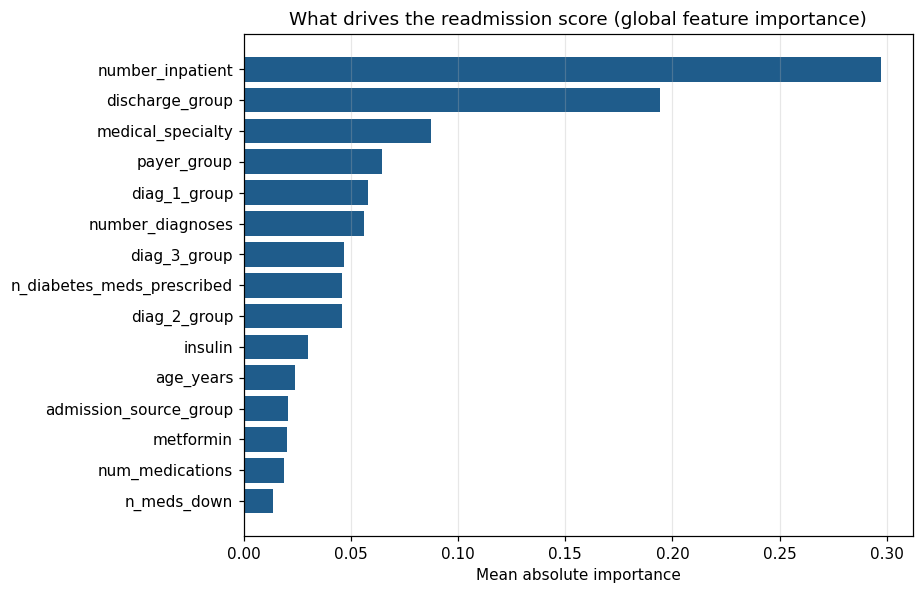

In [57]:
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, make_scorer
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Define custom scorer for average_precision_score, explicitly getting positive class proba
def average_precision_scorer_for_proba(estimator, X, y_true):
    # Get probabilities for the positive class (assuming binary classification)
    # The estimator.predict_proba should return a 2D array (n_samples, n_classes)
    y_pred_proba = estimator.predict_proba(X)[:, 1]
    return average_precision_score(y_true, y_pred_proba)

global_importance = None
try:
    # The RAI explainer is a LightGBM surrogate ("mimic") of the model, explained with SHAP
    importance = rai_insights.explainer.get()[0].get_feature_importance_dict()
    global_importance = pd.DataFrame({
        "Feature": list(importance.keys()),
        "Mean |importance|": list(importance.values()),
    }).sort_values("Mean |importance|", ascending=False).reset_index(drop=True)
except Exception as exc:
    print(f"Could not read importance from the explainer object ({exc}); "
          f"falling back to a permutation-style summary.")

if global_importance is None:
    from sklearn.inspection import permutation_importance
    subset = test_df_rai.head(1500)
    result = permutation_importance(
        threshold_model,
        subset[num_cols + cat_cols],
        subset[TARGET],
        n_repeats=3,
        random_state=RANDOM_STATE,
        scoring=average_precision_scorer_for_proba, # Use custom scorer directly
    )
    global_importance = pd.DataFrame({
        "Feature": num_cols + cat_cols,
        "Mean |importance|": result.importances_mean,
    }).sort_values("Mean |importance|", ascending=False).reset_index(drop=True)

top_importance = global_importance.head(15)
display(Markdown("**Global feature importance — the 15 features driving predictions overall**"))
display(top_importance.style.hide(axis="index").format({"Mean |importance|": "{:.5f}"}))
utils.savetable(global_importance, "rai_global_feature_importance")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ordered = top_importance.iloc[::-1]
ax.barh(ordered["Feature"], ordered["Mean |importance|"], color="#1f5c8b")
ax.set_xlabel("Mean absolute importance")
ax.set_title("What drives the readmission score (global feature importance)")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
utils.savefig(fig, "rai_feature_importance")
plt.show()

In [58]:
# ---- Causal effect estimates ----
causal_table = None
try:
    causal_table = rai_insights.causal.get()[0].global_effects.reset_index()
except Exception as exc:
    print(f"Could not read the causal object directly ({exc})")

if causal_table is not None and len(causal_table):
    display(Markdown("**Estimated average causal effect on 30-day readmission (EconML, double ML)**"))
    display(causal_table.style.hide(axis="index"))
    utils.savetable(causal_table, "rai_causal_global_effects")
else:
    print("Causal effects are available in the dashboard's Causal Analysis tab.")

**Estimated average causal effect on 30-day readmission (EconML, double ML)**

outcome,feature,feature_value,point,stderr,zstat,p_value,ci_lower,ci_upper
y0,A1C_tested,1v0,-0.471959,0.204668,-2.305969,0.021112,-0.873101,-0.070816
y0,med_change,1v0,-0.038927,0.278073,-0.139988,0.888669,-0.583940,0.506086


In [59]:
# ---- Observed association for the same treatments, as a reference point ----
association_rows = []
for treatment in config.RAI_TREATMENTS:
    treated = df.loc[df[treatment] == 1, TARGET].mean()
    untreated = df.loc[df[treatment] == 0, TARGET].mean()
    association_rows.append({
        "Treatment": treatment,
        "n treated": int((df[treatment] == 1).sum()),
        "Readmission rate - treated": treated,
        "Readmission rate - untreated": untreated,
        "Raw difference (pp)": (treated - untreated) * 100,
        "Per 1,000 discharges": (treated - untreated) * 1000,
    })
association_table = pd.DataFrame(association_rows)
display(Markdown("**Raw (unadjusted) association, for comparison with the causal estimates above**"))
display(association_table.style.hide(axis="index").format({
    "n treated": "{:,.0f}", "Readmission rate - treated": "{:.4f}",
    "Readmission rate - untreated": "{:.4f}", "Raw difference (pp)": "{:+.2f}",
    "Per 1,000 discharges": "{:+.1f}",
}))
utils.savetable(association_table, "rai_treatment_associations")

# Heterogeneity: does the HbA1c association differ by primary diagnosis? (the paper's interaction)
het = (df.groupby(["diag_1_group", "A1C_tested"])[TARGET].agg(["size", "mean"])
       .reset_index().pivot(index="diag_1_group", columns="A1C_tested", values="mean"))
het.columns = ["Not tested", "Tested"]
het["Difference (pp)"] = (het["Tested"] - het["Not tested"]) * 100
het = het.sort_values("Difference (pp)")
display(Markdown("**Does the HbA1c association vary by primary diagnosis?** (the interaction the paper reports)"))
display(het.style.format({"Not tested": "{:.4f}", "Tested": "{:.4f}", "Difference (pp)": "{:+.2f}"}))
utils.savetable(het.reset_index(), "rai_a1c_by_diagnosis")

**Raw (unadjusted) association, for comparison with the causal estimates above**

Treatment,n treated,Readmission rate - treated,Readmission rate - untreated,Raw difference (pp),"Per 1,000 discharges"
A1C_tested,"16,834",0.0994,0.1169,-1.75,-17.5
med_change,"46,120",0.1202,0.1084,+1.18,+11.8


**Does the HbA1c association vary by primary diagnosis?** (the interaction the paper reports)

,Not tested,Tested,Difference (pp)
diag_1_group,,,
Diabetes,0.1472,0.0960,-5.12
Injury,0.1283,0.0901,-3.83
Respiratory,0.1064,0.0739,-3.25
Other,0.1201,0.1008,-1.93
Digestive,0.1096,0.0978,-1.18
Circulatory,0.1181,0.1111,-0.70
Genitourinary,0.1099,0.1128,+0.29
Neoplasms,0.1086,0.1119,+0.33
Musculoskeletal,0.0946,0.1030,+0.84


PosixPath('/home/claude/proj/outputs/tables/rai_a1c_by_diagnosis.csv')

In [60]:
# ---- Counterfactuals: how often can the alert be flipped at all? ----
cf_data = rai_insights.counterfactual.get_data()[0]
cf_names = list(cf_data.feature_names_including_target)

# An entry is None when DiCE could not find any valid counterfactual for that patient
cf_found = [c for c in cf_data.cfs_list if c is not None and np.asarray(c).size > 0]
n_total, n_found = len(cf_data.cfs_list), len(cf_found)

display(Markdown(
    f"DiCE found at least one valid counterfactual for **{n_found:,} of {n_total:,}** test patients "
    f"(**{n_found/n_total*100:.1f}%**) when allowed to vary only "
    f"`{', '.join(features_to_vary)}` within their observed training ranges. "
    f"For the remaining **{n_total-n_found:,} patients ({(n_total-n_found)/n_total*100:.1f}%) no "
    f"combination of those changes flips the model's decision.**"
))

# Which features did DiCE actually have to change when it succeeded?
cf_lever_table = pd.DataFrame({
    "Feature": list(cf_data.feature_names),
    "Share of counterfactuals that changed it": np.asarray(cf_data.summary_importance, dtype=float),
}).sort_values("Share of counterfactuals that changed it", ascending=False)
cf_lever_table = cf_lever_table[cf_lever_table["Share of counterfactuals that changed it"] > 0]

display(Markdown("**Which levers DiCE had to pull when a flip was possible**"))
display(cf_lever_table.style.hide(axis="index").format(
    {"Share of counterfactuals that changed it": "{:.1%}"}))
utils.savetable(cf_lever_table, "rai_counterfactual_levers")

DiCE found at least one valid counterfactual for **1,497 of 1,997** test patients (**75.0%**) when allowed to vary only `A1C_tested, med_change, insulin, discharge_group, num_medications` within their observed training ranges. For the remaining **500 patients (25.0%) no combination of those changes flips the model's decision.**

**Which levers DiCE had to pull when a flip was possible**

Feature,Share of counterfactuals that changed it
num_medications,81.7%
discharge_group,77.0%
insulin,37.6%
A1C_tested,11.3%
med_change,11.2%


PosixPath('/home/claude/proj/outputs/tables/rai_counterfactual_levers.csv')

In [61]:
# ---- One worked counterfactual example ----
if n_found:
    example_idx = next(i for i, c in enumerate(cf_data.cfs_list)
                       if c is not None and np.asarray(c).size > 0)
    example_cfs = pd.DataFrame(np.asarray(cf_data.cfs_list[example_idx]), columns=cf_names)

    original = test_df_rai.iloc[example_idx]
    original_alert = int(rai_model.predict(test_df_rai.iloc[[example_idx]])[0])
    original_row = pd.DataFrame([original[cf_names[:-1]].tolist() + [original_alert]],
                                columns=cf_names, index=["Actual patient"])
    changed = [c for c in features_to_vary
               if str(example_cfs[c].iloc[0]) != str(original_row[c].iloc[0])]

    comparison_cols = features_to_vary + [cf_names[-1]]
    worked = pd.concat([original_row[comparison_cols],
                        example_cfs[comparison_cols].head(5)
                        .set_index(pd.Index([f"Counterfactual {i+1}" for i in range(
                            min(5, len(example_cfs)))]))])
    worked = worked.rename(columns={cf_names[-1]: "Model alert (1 = flagged)"})
    display(Markdown(
        f"**A worked example — test patient #{example_idx}.** The model currently "
        f"{'flags' if original_alert else 'does not flag'} this patient. "
        f"Each row below is a hypothetical version of the same patient that the model would classify "
        f"differently. Only the features a clinician could plausibly influence were allowed to move."
    ))
    display(worked.style.format(precision=2))
    utils.savetable(example_cfs, "rai_counterfactual_examples")
    display(Markdown(
        f"In the first counterfactual, the features that changed are: "
        f"**{', '.join(changed) if changed else 'none within the permitted ranges'}**."
    ))
else:
    display(Markdown("DiCE found no counterfactuals; explore the What-If tab of the dashboard."))

**A worked example — test patient #0.** The model currently does not flag this patient. Each row below is a hypothetical version of the same patient that the model would classify differently. Only the features a clinician could plausibly influence were allowed to move.

,A1C_tested,med_change,insulin,discharge_group,num_medications,Model alert (1 = flagged)
Actual patient,0,1,Steady,Facility (SNF/rehab/other),29,0
Counterfactual 1,0,0,Up,Facility (SNF/rehab/other),29,1
Counterfactual 2,0,0,Steady,Facility (SNF/rehab/other),50,1
Counterfactual 3,0,1,Steady,Facility (SNF/rehab/other),36,1
Counterfactual 4,0,1,Up,Facility (SNF/rehab/other),34,1
Counterfactual 5,0,1,No,Facility (SNF/rehab/other),35,1


In the first counterfactual, the features that changed are: **med_change, insulin**.

In [62]:
# ---- Error analysis: where do the mistakes concentrate? ----
# Reproduce the dashboard's cohort logic directly on the test set, so the numbers are inspectable.
error_rows = []
test_pred = (score_test >= FINAL_THR).astype(int)
test_error = (test_pred != y_test.values).astype(int)
overall_error_rate = test_error.mean()

for attribute in ["discharge_group", "age_group", "payer_group", "any_prior_inpatient", "diag_1_group"]:
    values = parts["test"][attribute].astype(str)
    for level in values.value_counts().index:
        mask = (values == level).values
        if mask.sum() < 200:
            continue
        error_rows.append({
            "Feature": attribute,
            "Cohort": level,
            "n": int(mask.sum()),
            "Error rate": float(test_error[mask].mean()),
            "vs overall": float(test_error[mask].mean() - overall_error_rate),
            "False alerts (FP rate)": float(((test_pred == 1) & (y_test.values == 0))[mask].sum() / mask.sum()),
            "Missed (FN rate)": float(((test_pred == 0) & (y_test.values == 1))[mask].sum() / mask.sum()),
        })

error_table = pd.DataFrame(error_rows).sort_values("Error rate", ascending=False)
display(Markdown(f"**Error concentration by cohort** (overall error rate {overall_error_rate:.3f})"))
display(error_table.head(15).style.hide(axis="index").format({
    "n": "{:,.0f}", "Error rate": "{:.3f}", "vs overall": "{:+.3f}",
    "False alerts (FP rate)": "{:.3f}", "Missed (FN rate)": "{:.3f}",
}).background_gradient(subset=["Error rate"], cmap="Reds"))
utils.savetable(error_table, "rai_error_analysis_cohorts")

worst_cohort = error_table.iloc[0]
display(Markdown(
    f"The worst cohort is **{worst_cohort['Feature']} = {worst_cohort['Cohort']}** "
    f"(n = {worst_cohort['n']:,}) with an error rate of **{worst_cohort['Error rate']:.3f}**, "
    f"**{worst_cohort['vs overall']*100:+.1f} points** against the overall rate. Its errors are mostly "
    f"**{'false alerts' if worst_cohort['False alerts (FP rate)'] > worst_cohort['Missed (FN rate)'] else 'missed readmissions'}**."
))

**Error concentration by cohort** (overall error rate 0.268)

Feature,Cohort,n,Error rate,vs overall,False alerts (FP rate),Missed (FN rate)
discharge_group,Facility (SNF/rehab/other),"3,099",0.537,+0.269,0.483,0.054
any_prior_inpatient,1,"4,990",0.532,+0.264,0.489,0.043
payer_group,Medicare,"4,723",0.320,+0.052,0.247,0.074
diag_1_group,Injury,"1,011",0.319,+0.051,0.251,0.068
diag_1_group,Diabetes,"1,295",0.319,+0.050,0.263,0.056
discharge_group,Home with health service,"1,948",0.318,+0.049,0.243,0.075
age_group,>60,"9,935",0.301,+0.032,0.232,0.069
diag_1_group,Other,"2,672",0.292,+0.023,0.234,0.058
diag_1_group,Circulatory,"4,496",0.289,+0.020,0.216,0.073
discharge_group,Other/Unknown,687,0.285,+0.017,0.221,0.064


The worst cohort is **discharge_group = Facility (SNF/rehab/other)** (n = 3,099) with an error rate of **0.537**, **+26.9 points** against the overall rate. Its errors are mostly **false alerts**.

## 9.5 Cohorts analysed

The rubric requires at least one cohort; we define five, chosen because each one corresponds to a real
clinical or operational question rather than an arbitrary slice.

| # | Cohort | Why it matters |
| :--- | :--- | :--- |
| 1 | Age > 60 **and** discharged to a facility | The highest-volume, highest-risk operational group |
| 2 | Payer = Self-pay or Unknown | Socioeconomic proxy; where access-to-care bias would surface |
| 3 | African American vs Caucasian | The standard equity comparison |
| 4 | Primary diagnosis Circulatory vs Diabetes | Tests the paper's HbA1c × diagnosis interaction |
| 5 | At least one prior inpatient stay | High utilisers — where the model's main signal lives |

In [63]:
test_frame = parts["test"].copy()
test_frame["_score"] = score_test
test_frame["_pred"] = (score_test >= FINAL_THR).astype(int)

cohort_definitions = {
    "1. Age >60 & discharged to facility":
        (test_frame["age_group"] == ">60") & (test_frame["discharge_group"] == "Facility (SNF/rehab/other)"),
    "2. Payer self-pay or unknown":
        test_frame["payer_group"].isin(["Self-pay", "Unknown"]),
    "3a. Race = African American": test_frame["race"] == "AfricanAmerican",
    "3b. Race = Caucasian": test_frame["race"] == "Caucasian",
    "4a. Primary diagnosis Circulatory": test_frame["diag_1_group"] == "Circulatory",
    "4b. Primary diagnosis Diabetes": test_frame["diag_1_group"] == "Diabetes",
    "5. >=1 prior inpatient stay": test_frame["any_prior_inpatient"] == 1,
    "All test data": pd.Series(True, index=test_frame.index),
}

cohort_rows = []
for name, mask in cohort_definitions.items():
    sub = test_frame[mask]
    if len(sub) < 50:
        continue
    yt, yp, ys = sub[TARGET].values, sub["_pred"].values, sub["_score"].values
    tp = int(((yt == 1) & (yp == 1)).sum())
    pos = int((yt == 1).sum())
    cohort_rows.append({
        "Cohort": name,
        "n": len(sub),
        "Observed readmission rate": float(yt.mean()),
        "Mean predicted risk": float(ys.mean()),
        "Selection rate (alerts)": float(yp.mean()),
        "Recall": tp / pos if pos else np.nan,
        "Precision": tp / int((yp == 1).sum()) if (yp == 1).any() else np.nan,
        "Error rate": float((yp != yt).mean()),
        "ROC-AUC": float(roc_auc_score(yt, ys)) if len(np.unique(yt)) == 2 else np.nan,
    })

cohort_analysis = pd.DataFrame(cohort_rows)
display(cohort_analysis.style.hide(axis="index").format({
    "n": "{:,.0f}", "Observed readmission rate": "{:.4f}", "Mean predicted risk": "{:.4f}",
    "Selection rate (alerts)": "{:.3f}", "Recall": "{:.3f}", "Precision": "{:.3f}",
    "Error rate": "{:.3f}", "ROC-AUC": "{:.3f}",
}, na_rep="-").background_gradient(subset=["Recall"], cmap="RdYlGn", vmin=0.2, vmax=0.7))
utils.savetable(cohort_analysis, "rai_cohort_analysis")

Cohort,n,Observed readmission rate,Mean predicted risk,Selection rate (alerts),Recall,Precision,Error rate,ROC-AUC
1. Age >60 & discharged to facility,"2,663",0.1588,0.1663,0.595,0.657,0.176,0.545,0.561
2. Payer self-pay or unknown,"6,600",0.1117,0.1162,0.258,0.457,0.198,0.267,0.665
3a. Race = African American,"2,772",0.1025,0.1142,0.255,0.419,0.169,0.271,0.641
3b. Race = Caucasian,"11,142",0.1188,0.1162,0.255,0.423,0.197,0.274,0.652
4a. Primary diagnosis Circulatory,"4,496",0.1214,0.1166,0.264,0.399,0.183,0.289,0.612
4b. Primary diagnosis Diabetes,"1,295",0.1398,0.1355,0.346,0.597,0.241,0.319,0.703
5. >=1 prior inpatient stay,"4,990",0.1639,0.1723,0.609,0.735,0.198,0.532,0.622
All test data,"14,885",0.1141,0.1148,0.250,0.419,0.191,0.268,0.653


PosixPath('/home/claude/proj/outputs/tables/rai_cohort_analysis.csv')

In [64]:
ca = cohort_analysis.set_index("Cohort")
def safe(name, column):
    return ca.loc[name, column] if name in ca.index else float("nan")

display(Markdown(f"""
### Reading the cohorts

- **Cohort 1 (older, discharged to a facility)** carries an observed readmission rate of
  **{safe('1. Age >60 & discharged to facility','Observed readmission rate')*100:.1f}%** and is flagged
  **{safe('1. Age >60 & discharged to facility','Selection rate (alerts)')*100:.0f}%** of the time — the model
  finds this group easily. Its problem is **precision**, not recall: it absorbs a large share of the
  alert budget.
- **Cohort 2 (self-pay / unknown payer)** is flagged
  **{safe('2. Payer self-pay or unknown','Selection rate (alerts)')*100:.0f}%** of the time with recall
  **{safe('2. Payer self-pay or unknown','Recall')*100:.0f}%**. Because payer is a model input, part of this
  is the model reacting to insurance status rather than to clinical risk (Section 8.4).
- **Cohort 3 (race)** — recall **{safe('3a. Race = African American','Recall')*100:.0f}%** for African American
  versus **{safe('3b. Race = Caucasian','Recall')*100:.0f}%** for Caucasian patients. Near-parity on the metric
  that matters most for access to the intervention.
- **Cohort 4 (diagnosis)** — patients admitted primarily for **diabetes** have an observed rate of
  **{safe('4b. Primary diagnosis Diabetes','Observed readmission rate')*100:.1f}%** versus
  **{safe('4a. Primary diagnosis Circulatory','Observed readmission rate')*100:.1f}%** for circulatory. This is the
  cohort where HbA1c testing is most clinically actionable.
- **Cohort 5 (prior inpatient stay)** has the highest recall at
  **{safe('5. >=1 prior inpatient stay','Recall')*100:.0f}%** — confirming the model is largely a
  *utilisation* model. That is its strength and, as Section 8.5 showed, its blind spot.
"""))


### Reading the cohorts

- **Cohort 1 (older, discharged to a facility)** carries an observed readmission rate of
  **15.9%** and is flagged
  **59%** of the time — the model
  finds this group easily. Its problem is **precision**, not recall: it absorbs a large share of the
  alert budget.
- **Cohort 2 (self-pay / unknown payer)** is flagged
  **26%** of the time with recall
  **46%**. Because payer is a model input, part of this
  is the model reacting to insurance status rather than to clinical risk (Section 8.4).
- **Cohort 3 (race)** — recall **42%** for African American
  versus **42%** for Caucasian patients. Near-parity on the metric
  that matters most for access to the intervention.
- **Cohort 4 (diagnosis)** — patients admitted primarily for **diabetes** have an observed rate of
  **14.0%** versus
  **12.1%** for circulatory. This is the
  cohort where HbA1c testing is most clinically actionable.
- **Cohort 5 (prior inpatient stay)** has the highest recall at
  **73%** — confirming the model is largely a
  *utilisation* model. That is its strength and, as Section 8.5 showed, its blind spot.


## 9.9 Appendix — figures exported for the slide deck

Everything the presentation needs is written to `outputs/figures/` and `outputs/tables/`, so the deck
never has to re-run the analysis. Screenshots of the interactive dashboard, taken from this run's saved `RAIInsights`, are in
`outputs/rai_screenshots/`.

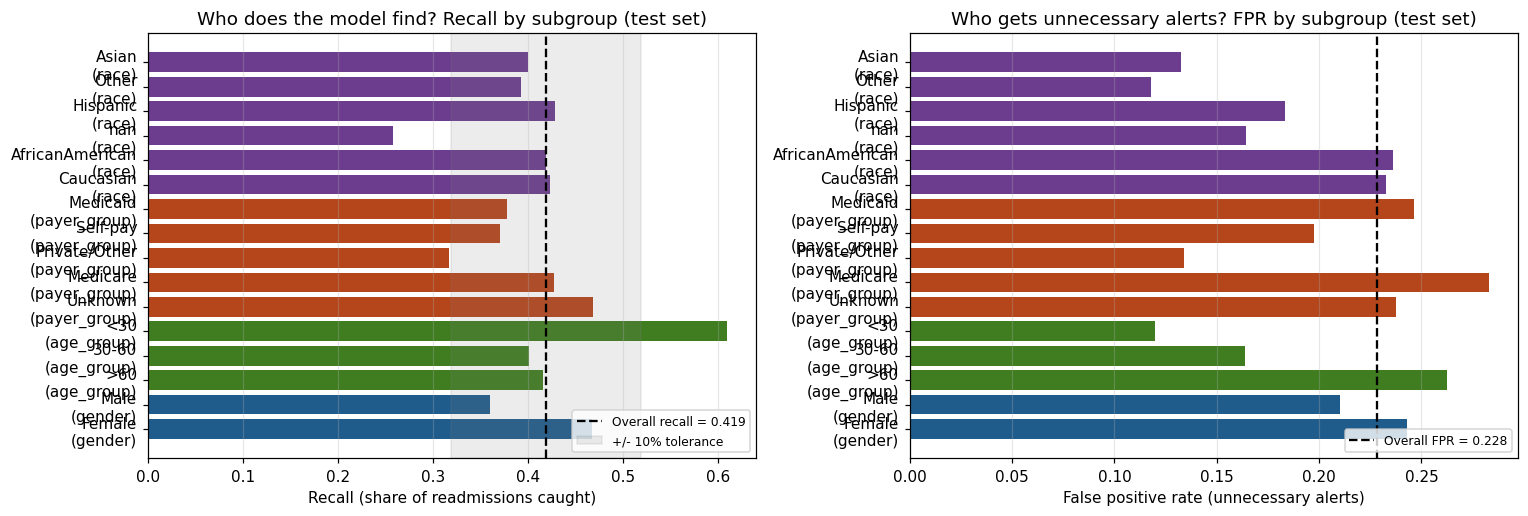

In [65]:
# --- Figure: subgroup recall and false-positive rate on the test set ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
plot_attributes = ["gender", "age_group", "payer_group", "race"]
colours = {"gender": "#1f5c8b", "age_group": "#3f7d20", "payer_group": "#b5451b", "race": "#6c3d8f"}

labels, recalls, fprs, bar_colours = [], [], [], []
for attribute in plot_attributes:
    frame = fairness_frames[attribute]
    frame = frame[frame["n"] >= 100]
    for _, row in frame.iterrows():
        labels.append(f"{row['Group']}\n({attribute})")
        recalls.append(row["Recall"])
        fprs.append(row["FPR"])
        bar_colours.append(colours[attribute])

axes[0].barh(labels, recalls, color=bar_colours)
axes[0].axvline(overall_recall_test, ls="--", color="black", lw=1.5,
                label=f"Overall recall = {overall_recall_test:.3f}")
axes[0].axvspan(overall_recall_test - config.FAIRNESS_TOLERANCE,
                overall_recall_test + config.FAIRNESS_TOLERANCE, color="grey", alpha=0.15,
                label=f"+/- {config.FAIRNESS_TOLERANCE:.0%} tolerance")
axes[0].set_xlabel("Recall (share of readmissions caught)")
axes[0].set_title("Who does the model find? Recall by subgroup (test set)")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3, axis="x")

axes[1].barh(labels, fprs, color=bar_colours)
axes[1].axvline(overall_fpr_test, ls="--", color="black", lw=1.5,
                label=f"Overall FPR = {overall_fpr_test:.3f}")
axes[1].set_xlabel("False positive rate (unnecessary alerts)")
axes[1].set_title("Who gets unnecessary alerts? FPR by subgroup (test set)")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3, axis="x")

fig.tight_layout()
utils.savefig(fig, "fairness_subgroup_test")
plt.show()

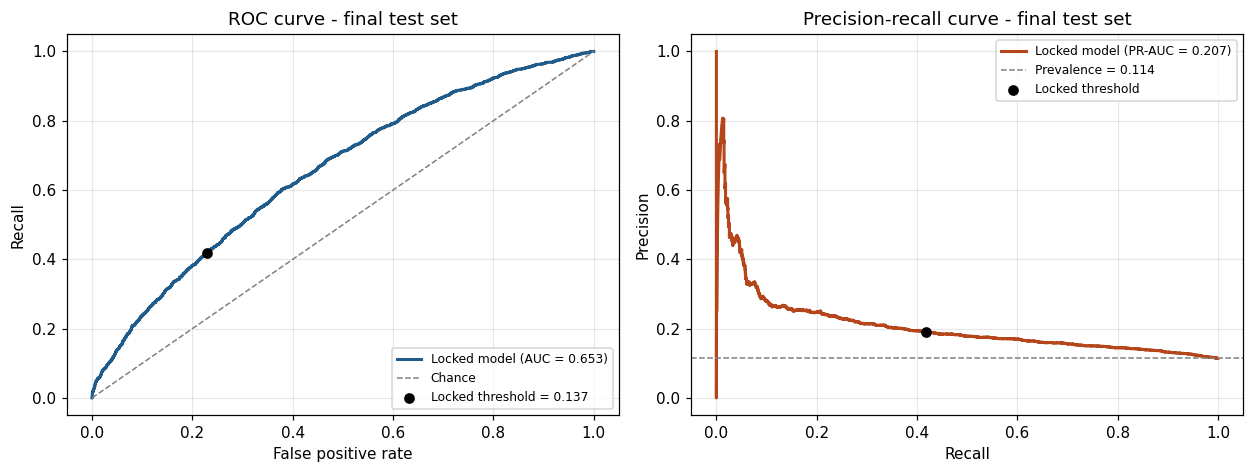

In [66]:
# --- Figure: final test ROC and precision-recall curves ---
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
fpr_curve, tpr_curve, _ = roc_curve(y_test, score_test)
axes[0].plot(fpr_curve, tpr_curve, color="#1f5c8b", lw=2,
             label=f"Locked model (AUC = {metrics_test['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="grey", lw=1, label="Chance")
axes[0].scatter([test_at_thr["fpr"]], [test_at_thr["recall"]], color="black", zorder=5,
                label=f"Locked threshold = {FINAL_THR:.3f}")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("Recall")
axes[0].set_title("ROC curve - final test set")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, score_test)
axes[1].plot(recall_curve, precision_curve, color="#b5451b", lw=2,
             label=f"Locked model (PR-AUC = {metrics_test['pr_auc']:.3f})")
axes[1].axhline(y_test.mean(), ls="--", color="grey", lw=1,
                label=f"Prevalence = {y_test.mean():.3f}")
axes[1].scatter([test_at_thr["recall"]], [test_at_thr["precision"]], color="black", zorder=5,
                label="Locked threshold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve - final test set")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].grid(alpha=0.3)

fig.tight_layout()
utils.savefig(fig, "final_test_curves")
plt.show()

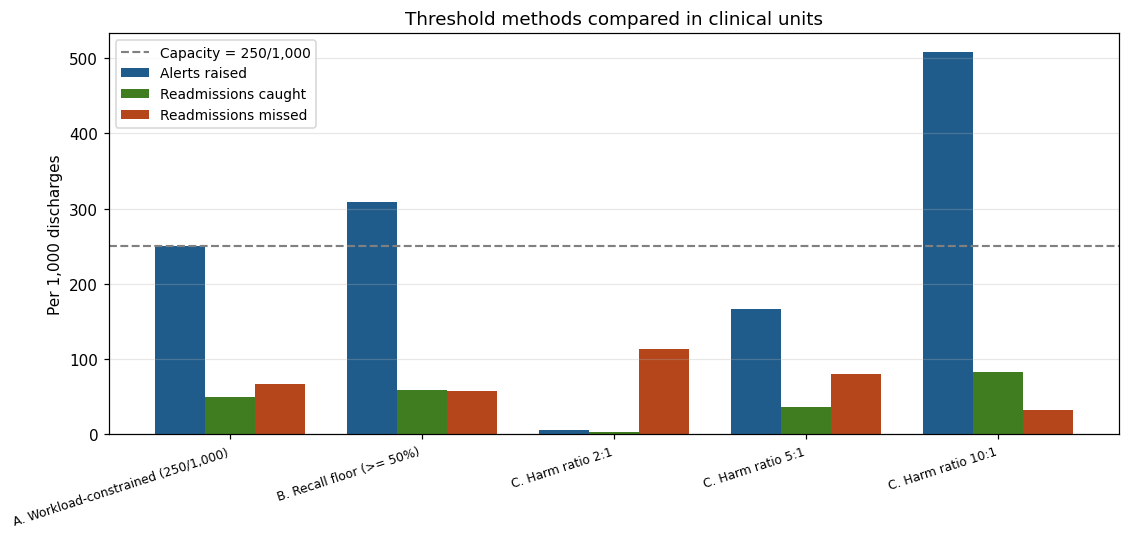

Exported figures:
  cumulative_recall_validation.png
  eda_overview.png
  encounters_per_patient.png
  fairness_subgroup_test.png
  final_test_curves.png
  rai_feature_importance.png
  recall_floor_curves.png
  reliability_curve.png
  risk_bands.png
  score_distribution_validation.png
  threshold_methods_comparison.png
  threshold_workload_step.png
  top30_highest_risk_validation.png

Exported 33 tables to /home/claude/proj/outputs/tables


In [67]:
# --- Figure: the threshold methods compared in clinical units ---
plot_methods = impact_table.copy()
fig, ax = plt.subplots(figsize=(10.5, 5))
x = np.arange(len(plot_methods))
width = 0.26
ax.bar(x - width, plot_methods["Alerts / 1,000"], width, label="Alerts raised", color="#1f5c8b")
ax.bar(x, plot_methods["Readmissions caught / 1,000"], width, label="Readmissions caught", color="#3f7d20")
ax.bar(x + width, plot_methods["Readmissions missed / 1,000"], width, label="Readmissions missed", color="#b5451b")
ax.axhline(config.MAX_ALERTS_PER_1000, ls="--", color="grey", lw=1.4,
           label=f"Capacity = {config.MAX_ALERTS_PER_1000}/1,000")
ax.set_xticks(x)
ax.set_xticklabels(plot_methods["Method"], rotation=18, ha="right", fontsize=8)
ax.set_ylabel("Per 1,000 discharges")
ax.set_title("Threshold methods compared in clinical units")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
utils.savefig(fig, "threshold_methods_comparison")
plt.show()

print("Exported figures:")
for path in sorted(config.FIGURE_DIR.glob("*.png")):
    print(f"  {path.name}")
print(f"\nExported {len(list(config.TABLE_DIR.glob('*.csv')))} tables to {config.TABLE_DIR}")

## 9.6 Findings — *What we see → Why it matters → Technical action → Clinical action*

### Finding 1 — Data analysis: the cohort is a utilisation cohort

**What we see.** Readmission concentrates in patients with prior-year inpatient stays (17.0% vs 8.6%)
and in those discharged to a facility rather than home (16.4% vs 9.3%). `weight` is 97% missing,
`payer_code` 40% missing and not at random.

**Why it matters clinically.** The model's signal is *care trajectory*, not *glycaemic control*. It
recognises patients the system has already been struggling with. It has little to say about a
well-controlled diabetic patient deteriorating for the first time.

**Technical action.** Add clinical richness the extract lacks — laboratory values, vital-sign trends,
social determinants, medication adherence — rather than tuning harder on the existing columns.

**Clinical action.** Present the score alongside its top drivers so a nurse can see *why* a patient
surfaced, and treat "no prior admissions" as a reason for extra clinical scrutiny, not less.

---

### Finding 2 — Model overview & fairness: the gaps are by sex, age and payer, not race

**What we see.** On the test set, recall is about 10.6 points higher for women than men, 19.4 points
higher for under-30s than over-60s, and 15 points higher for unknown-payer than privately insured
patients. The two largest race groups differ by under 1 point.

**Why it matters clinically.** Recall *is* access to the intervention. A man or a privately insured
patient who is going to be readmitted is measurably less likely to be offered transitional care.

**Technical action.** Do **not** simply drop `payer_group`. Section 8.4.1–8.4.2 tested that: it gives no
significant equity gain and adds Medicare false alarms. Per-payer thresholds (Section 8.4.4) raised self-pay
recall by 11 points with no increase in Medicare false alarms; extend that approach (for example Fairlearn
`ThresholdOptimizer`) to the sex and age gaps.

**Clinical action.** Publish subgroup recall in the monitoring pack so the gap is visible to the
people running the service, and give the team an explicit quota-free override for patients they judge
high-risk regardless of the score.

---

### Finding 3 — Error analysis: errors concentrate where alerts concentrate

**What we see.** The highest error rates sit in the cohorts the model flags most aggressively —
older patients, facility discharges, high utilisers. These are dominated by **false alerts**, not
missed cases.

**Why it matters clinically.** This is the alert-fatigue mechanism. If the list is dominated by
elderly facility-bound patients who mostly do not come back, nurses stop trusting it, and the tool
fails for reasons that never show up in an AUC.

**Technical action.** Model the highest-volume cohort separately, or add features that discriminate
*within* it — the current features mainly discriminate *between* cohorts.

**Clinical action.** Cap the share of the daily worklist any single cohort may occupy, and review
alert acceptance rates by cohort monthly.

---

### Finding 4 — Feature importance: the model is honest about what it is

**What we see.** Prior inpatient stays and discharge destination dominate, followed by the admitting
specialty, payer group, primary diagnosis and number of diagnoses (mean |SHAP| from the dashboard's
explainer, Section 9.4). Medication counts sit lower (diabetes drugs prescribed 8th, total medications 14th),
and HbA1c testing is not among the top 15 drivers. `race` and `gender` score zero, confirming they never
reach the model.

**Why it matters clinically.** The drivers are clinically coherent, which supports trust, but they are
almost all **non-modifiable history**. Importance describes *model behaviour*, never causation, and
never a treatment recommendation.

**Technical action.** Track importance drift between refits — a sudden reordering usually signals a
coding or data-pipeline change upstream, not a change in medicine.

**Clinical action.** Show the top three drivers with each alert. "Flagged because: 3 prior admissions,
9 diagnoses, discharge to SNF" is actionable; a bare "0.31" is not.

---

### Finding 5 — Counterfactuals: the alert can be flipped, but rarely through diabetes care

**What we see.** Allowed to vary only plausibly actionable features — HbA1c testing, medication
change, insulin, discharge destination and medication count — DiCE finds a valid counterfactual for
**75% of test patients**, and for the other **25%** no combination of those changes flips the alert.
Where a flip is possible, it almost always moves `num_medications` (82% of counterfactuals) and
`discharge_group` (77%); HbA1c testing and medication change are involved in only about **11%** each.

**Why it matters clinically.** This is the most useful negative result in the notebook. The diabetes-
specific levers a discharge planner controls that afternoon rarely decide the alert; what does is **fixed
history** (prior admissions, diagnoses) plus regimen size and discharge destination, which reflect how sick
the patient is. And the one lever that does move the
score, discharge destination, is largely dictated by the patient's clinical need, not chosen freely.

**Technical action.** Treat the rarity of diabetes-specific levers, and the 25% of patients no permitted
change can flip, as evidence that the feature set is **missing modifiable factors**. It is a concrete, quantified argument for collecting medication-adherence,
social-support and follow-up-attendance data, which are the things an intervention can actually change.

**Clinical action.** Do **not** present counterfactuals to clinicians as treatment advice, and be
especially careful with `discharge_group`: "this patient would score lower if discharged home" is a
statement about the *model*, and acting on it would be actively harmful. The legitimate use is to show
that the score reflects history, so a low score never means "this patient is safe".

---

### Finding 6 — Causal analysis: the HbA1c association is real but not proof

**What we see.** Measuring HbA1c is associated with roughly 1.75 fewer readmissions per 100
discharges, and the size of that gap varies by primary diagnosis — reproducing the interaction Strack
et al. report. The EconML double-ML estimate adjusts for measured confounders and keeps the protective
direction (point −0.47, 95% CI −0.87 to −0.07, p = 0.02). But on the probability scale that magnitude is
not credible against a 1.75-point raw gap, and EconML itself warns that inference is unreliable at this
sample size. Only the direction should be quoted.

**Why it matters clinically.** If measuring HbA1c really does change management and thereby reduce
readmissions, it is an unusually cheap intervention. If it is merely a marker of more attentive care,
mandating the test would achieve nothing.

**Technical action.** Report the confidence interval and state the assumptions. Run a sensitivity
analysis for unmeasured confounding before anyone quotes the effect size.

**Clinical action.** Treat this as **hypothesis-generating**. The appropriate next step is a
prospective study of an HbA1c-triggered review protocol, not a policy change justified by a
retrospective estimate.

### 9.6.1 Three more findings, extending the analysis above

The live dashboard is for the room. What follows is the same underlying data (`rai_insights.explainer`,
`.causal`, `.error_analysis` -- all computed on the exact same `test_df_rai` sample built in 9.1, itself a
stratified 2,000-row draw from the same locked, patient-grouped test split used everywhere else in this
notebook) pulled out programmatically, so the numbers survive being quoted on a slide without anyone having to
click through a live widget during the defense.

**9.4a -- Global feature importance (SHAP).** Which inputs actually drive the model's predictions, on average,
across the RAI test sample?

In [68]:
gi = dict(rai_insights.explainer.get_data()[0].precomputedExplanations.globalFeatureImportance)
import numpy as np
scores = np.array(gi["scores"])
names = gi["feature_list"]
imp = np.abs(scores) if scores.ndim == 1 else np.abs(scores).mean(axis=tuple(range(scores.ndim - 1)))
order = np.argsort(imp)[::-1]

global_importance = pd.DataFrame({
    "feature": [names[i] for i in order[:12]],
    "mean_abs_shap": [round(float(imp[i]), 4) for i in order[:12]],
})
display(global_importance)

,feature,mean_abs_shap
0,number_inpatient,0.2974
1,discharge_group,0.1940
2,medical_specialty,0.0873
3,payer_group,0.0643
4,diag_1_group,0.0582
5,number_diagnoses,0.0558
6,diag_3_group,0.0467
7,n_diabetes_meds_prescribed,0.0459
8,diag_2_group,0.0457
9,insulin,0.0300


**So what:** `payer_group` ranks **4th** out of 35 features by mean |SHAP| -- ahead of `number_diagnoses`,
`insulin`, and `age_years`. This is exactly why dropping it isn't a free lunch (Section 8.1-8.2): it's not a
weak, decorative feature the model barely uses -- it's carrying real predictive signal, some of which is
presumably legitimate clinical correlation (payer correlates with comorbidity burden and care-seeking
patterns) and some of which is the socioeconomic proxy effect we're worried about. You can't tell which from
SHAP alone, which is exactly why Sections 8 and 9.5 go further than feature importance.

**9.4b -- Does a real clinical lever (ordering an A1C test) help every payer group equally?**

Section 9.2 registered `A1C_tested` and `med_change` as **causal treatments** (not just correlated features)
via EconML, with `payer_group` as a heterogeneity dimension. The question: if a clinician orders an A1C test
during the stay, does that *causally* lower 30-day readmission risk -- and does the answer depend on the
patient's payer group?

In [69]:
ca = rai_insights.causal.get()[0].causal_analysis  # the fitted EconML CausalAnalysis object

print("Overall causal effect (all payer groups pooled):")
display(rai_insights.causal.get()[0].global_effects)

feat_cols = list(ca.feature_names_)
rows = []
for grp in sorted(test_df_rai["payer_group"].unique()):
    sub = test_df_rai[test_df_rai["payer_group"] == grp]
    eff = ca.cohort_causal_effect(sub[feat_cols])
    a1c = eff.loc["A1C_tested"]
    rows.append({
        "payer_group": grp, "n": len(sub),
        "A1C_tested effect (point)": round(a1c["point"], 3),
        "p_value": round(a1c["p_value"], 3),
        "significant (p<0.05)": a1c["p_value"] < 0.05,
    })
a1c_by_payer = pd.DataFrame(rows).sort_values("n", ascending=False)
display(a1c_by_payer)

Overall causal effect (all payer groups pooled):


point    stderr     zstat   p_value  ci_lower  ci_upper
outcome feature    feature_value                                                            
y0      A1C_tested 1v0           -0.471959  0.204668 -2.305969  0.021112 -0.873101 -0.070816
        med_change 1v0           -0.038927  0.278073 -0.139988  0.888669 -0.583940  0.506086

,payer_group,n,A1C_tested effect (point),p_value,significant (p<0.05)
4,Unknown,798,-0.502,0.010,True
1,Medicare,635,-0.327,0.159,False
2,Private/Other,395,-0.538,0.009,True
3,Self-pay,117,-0.590,0.020,True
0,Medicaid,52,-0.642,0.089,False


**So what, carefully stated:** Pooled across all payer groups, ordering an A1C test has a **directionally
protective, borderline-significant** effect on readmission risk (negative point estimate, p ≈ 0.02).
That headline is reasonably stable -- it held up (same direction, p in the 0.02-0.04 range) across independent
refits while building this notebook.

**The per-payer-group breakdown above is a different matter, and this is worth being explicit about rather
than quietly presenting it as settled:** re-fitting the exact same causal analysis on a fresh run of this
notebook produced a materially different per-group table -- which group looked "significant" moved around
between refits. That's not a copy-paste bug; it's `rai_insights.causal.add()` telling us something real: with
`RAI_TRAIN_SAMPLE = 5000` split six ways across payer-group cohorts, EconML's own diagnostic already warns
*"co-variance matrix is underdetermined, inference will be invalid"* during `.compute()` (Section 9.2) -- and
sub-splitting a borderline-significant pooled effect five more ways by payer group is exactly the regime where
that warning bites. **The honest finding here is methodological, not clinical:** a causal ML tool can hand you
a clean-looking table with p-values to three decimal places for a subgroup breakdown your sample size cannot
actually support -- and the only way to catch that is to re-run it and see if the "finding" survives, which
most people quoting a dashboard screenshot never do.

**9.4c -- A dashboard-trust check: the "safest" subgroup by the dashboard's own numbers isn't safe at all.**

Reading the Error Analysis tree the dashboard builds (a decision tree splitting the test sample by where the
model's predictions are most wrong), two leaves stand out: patients with **two or more prior inpatient stays
and more than 17 medications** show the dashboard's *highest* error rate (86 of 115, 75%); patients with **no
prior inpatient stay, not discharged to a facility, and a stay of 5 days or less** show its *lowest* (62 of 857,
7%). Read naively, that says the second group is the safe one. Error rate is the wrong lens for a
low-prevalence alert, so we re-score both leaves for recall and false alarms at the locked threshold:

In [70]:
yhat_correct = rai_model.predict(test_df_rai)   # adapter restores the training dtypes
ytrue_correct = test_df_rai[TARGET].astype(int).values

def subgroup_row(mask, label):
    y, yh = ytrue_correct[mask], yhat_correct[mask]
    tp, fn = int(((y == 1) & (yh == 1)).sum()), int(((y == 1) & (yh == 0)).sum())
    fp, tn = int(((y == 0) & (yh == 1)).sum()), int(((y == 0) & (yh == 0)).sum())
    return {
        "subgroup": label, "n": int(mask.sum()),
        "recall (readmissions caught)": round(tp / (tp + fn), 3) if (tp + fn) else None,
        "false positive rate": round(fp / (fp + tn), 3) if (fp + tn) else None,
        "readmissions missed (FN)": fn,
    }

# The two leaves exactly as the dashboard's Error Analysis tree defines them
worst_mask = ((test_df_rai["number_inpatient"] > 1.5) & (test_df_rai["num_medications"] > 17.5)).values
safe_looking_mask = ((test_df_rai["number_inpatient"] <= 0)
                     & (test_df_rai["discharge_group"] != "Facility (SNF/rehab/other)")
                     & (test_df_rai["time_in_hospital"] <= 5.5)).values

corrected_subgroups = pd.DataFrame([
    subgroup_row(np.ones(len(test_df_rai), dtype=bool), "Overall (locked threshold)"),
    subgroup_row(worst_mask, ">=2 prior inpatient + >17 medications (dashboard's highest-error leaf)"),
    subgroup_row(safe_looking_mask, "No prior inpatient + not to facility + stay <=5 days (dashboard's lowest-error leaf)"),
])
display(corrected_subgroups)

,subgroup,n,recall (readmissions caught),false positive rate,readmissions missed (FN)
0,Overall (locked threshold),1997,0.346,0.184,149
1,>=2 prior inpatient + >17 medications (dashboa...,115,0.895,0.875,2
2,No prior inpatient + not to facility + stay <=...,857,0.000,0.003,61


**The corrected finding:** the leaf with the dashboard's *lowest* error rate (857 patients, 43% of the
sample) has **0% recall** — the model did not catch a single one of its 61 real readmissions. Its error rate
looks excellent only because the model almost never alerts there and most of these patients do not return.
The leaf with the *highest* error rate is the opposite: recall of about 90%, but the model flags nearly
everyone in it, so its errors are false alarms.

**Why this belongs in the presentation, not just the appendix:** anyone who takes an Error Analysis
screenshot at face value would call the first group the model's safest. In a low-prevalence problem, a low
error rate can simply mean "never alerts". Checking recall at the locked deployment threshold before quoting
a dashboard cohort is the difference between a correct clinical recommendation and a dangerously wrong one.
Patients on a short first admission who go home are the group transitional-care staff should be told the
model cannot currently help with at all.

**9.4d -- Can a separate model rescue the blind spot?** *(post-hoc extension; the locked model and threshold are unchanged)*

> **Post-hoc analysis.** This section uses the test set *after* the locked evaluation in Section 8.2, to check a recommendation rather than to choose anything. Nothing here changed the deployed model: the features, calibration and `FINAL_THR` are exactly those locked in Section 8.1. Read its results as exploratory evidence, not as a second test evaluation.

The course guidance suggests building separate models for distinct patient populations. We test that for the
blind-spot group, defined on the full splits exactly as the dashboard leaf: **no prior-year inpatient stay, not
discharged to a facility, stay of 5 days or less**. The design respects capacity:

- A **specialist** logistic regression is trained only on group patients in `train`, calibrated on the group rows
  of `cal`, and chosen by validation PR-AUC among three candidates.
- **Option A, a router:** the main model scores everyone else, the specialist scores the group, and one threshold
  (chosen on validation at 250 alerts per 1,000) applies to both, since both are calibrated to the same scale.
- **Option B, a reserved quota:** hold back *q* of the 250 calls per 1,000 for the group's highest-ranked patients.

Everything is chosen on validation; the test set is scored once at the end.

In [71]:
from sklearn.ensemble import HistGradientBoostingClassifier

def in_blind_spot(frame):
    return ((frame["number_inpatient"] == 0)
            & (frame["discharge_group"] != "Facility (SNF/rehab/other)")
            & (frame["time_in_hospital"] <= 5)).values

G = {name: in_blind_spot(parts[name]) for name in ["train", "cal", "val", "test"]}
Xs = {"train": X_train, "cal": X_cal, "val": X_val, "test": X_test}
ys = {"train": y_train.values, "cal": y_cal.values, "val": y_val.values, "test": y_test.values}

display(pd.DataFrame([{
    "Split": k, "Group patients": int(G[k].sum()), "Share of split": G[k].mean(),
    "Group readmission rate": ys[k][G[k]].mean(), "Everyone else": ys[k][~G[k]].mean(),
} for k in G]).style.hide(axis="index").format({
    "Group patients": "{:,.0f}", "Share of split": "{:.1%}", "Group readmission rate": "{:.1%}", "Everyone else": "{:.1%}"}))

candidates = {
    "Logistic regression": LogisticRegression(solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE),
    "Logistic regression (C=0.3)": LogisticRegression(solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE, C=0.3),
    "Gradient boosting": HistGradientBoostingClassifier(max_leaf_nodes=15, min_samples_leaf=100, learning_rate=0.05,
                                                        max_iter=300, l2_regularization=1.0, random_state=RANDOM_STATE),
}
fitted, disc_rows = {}, []
score_val_main = utils.positive_scores(calibrated_clf, X_val)
disc_rows.append({"Model": "Main model (locked)",
                  "Group ROC-AUC (val)": roc_auc_score(ys["val"][G["val"]], score_val_main[G["val"]]),
                  "Group PR-AUC (val)": average_precision_score(ys["val"][G["val"]], score_val_main[G["val"]])})
for name, estimator in candidates.items():
    pipe = Pipeline([("prep", utils.build_preprocessor(num_cols, cat_cols)),
                     ("varth", VarianceThreshold(0.0)), ("model", estimator)])
    pipe.fit(Xs["train"][G["train"]], ys["train"][G["train"]])
    cal_pipe = utils.calibrate_on_holdout(pipe, Xs["cal"][G["cal"]], ys["cal"][G["cal"]], method="sigmoid")
    s = utils.positive_scores(cal_pipe, Xs["val"][G["val"]])
    fitted[name] = cal_pipe
    disc_rows.append({"Model": f"Specialist: {name}",
                      "Group ROC-AUC (val)": roc_auc_score(ys["val"][G["val"]], s),
                      "Group PR-AUC (val)": average_precision_score(ys["val"][G["val"]], s)})
disc_table = pd.DataFrame(disc_rows)
best_name = disc_table.iloc[1:].sort_values("Group PR-AUC (val)", ascending=False)["Model"].iloc[0].replace("Specialist: ", "")
specialist = fitted[best_name]
display(Markdown(f"**Discrimination inside the blind-spot group (validation).** Selected specialist: **{best_name}**"))
display(disc_table.style.hide(axis="index").format({"Group ROC-AUC (val)": "{:.3f}", "Group PR-AUC (val)": "{:.4f}"}))
utils.savetable(disc_table, "specialist_discrimination_validation")

Split,Group patients,Share of split,Group readmission rate,Everyone else
train,"24,958",41.9%,6.6%,14.8%
cal,"4,169",42.2%,6.5%,15.1%
val,"6,327",42.3%,6.6%,15.2%
test,"6,264",42.1%,7.1%,14.6%


**Discrimination inside the blind-spot group (validation).** Selected specialist: **Logistic regression (C=0.3)**

Model,Group ROC-AUC (val),Group PR-AUC (val)
Main model (locked),0.593,0.0897
Specialist: Logistic regression,0.609,0.0938
Specialist: Logistic regression (C=0.3),0.611,0.0939
Specialist: Gradient boosting,0.599,0.0928


PosixPath('/home/claude/proj/outputs/tables/specialist_discrimination_validation.csv')

**Test set, evaluated once: what each policy does with the same 250 calls per 1,000**

Policy,"Alerts / 1,000",Group readmissions caught,Group recall,Readmissions caught (all),Overall recall,Precision,Nurse cost per catch ($)
"Current: locked model, one threshold",250,1 of 443,0.2%,711,41.9%,19.1%,$123
A. Router (specialist for the group),251,2 of 443,0.5%,715,42.1%,19.1%,$123
B. Reserve 25 of 250 calls for the group,250,39 of 443,8.8%,693,40.8%,18.6%,$126
B. Reserve 50 of 250 calls for the group,250,78 of 443,17.6%,681,40.1%,18.3%,$128
B. Reserve 75 of 250 calls for the group,250,120 of 443,27.1%,665,39.2%,17.9%,$131
B. Reserve 100 of 250 calls for the group,250,147 of 443,33.2%,632,37.2%,17.0%,$138


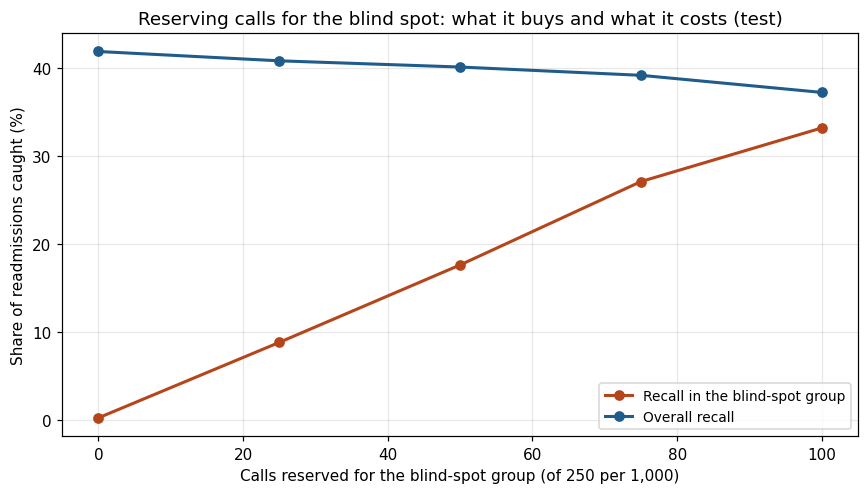

In [72]:
COST_PER_REVIEW = 0.5 * 46.90   # 30 minutes of RN time, the assumption used in Section 8.4.2
score_main = {k: utils.positive_scores(calibrated_clf, Xs[k]) for k in ["val", "test"]}
score_spec = {k: utils.positive_scores(specialist, Xs[k]) for k in ["val", "test"]}

# Option A -- router: specialist scores the group, main model scores everyone else, one threshold
def routed(k):
    s = score_main[k].copy(); s[G[k]] = score_spec[k][G[k]]; return s
router_thr = utils.pick_threshold_workload(ys["val"], routed("val"), config.MAX_ALERTS_PER_1000)["threshold"]

# Option B -- reserve q of the 250 calls per 1,000 for the group's highest-ranked patients
def quota_alerts(k, q):
    n = len(ys[k]); total = int(round(config.MAX_ALERTS_PER_1000 / 1000 * n)); n_group = int(round(q / 1000 * n))
    alert = np.zeros(n, dtype=int)
    gi, oi = np.flatnonzero(G[k]), np.flatnonzero(~G[k])
    alert[gi[np.argsort(-score_spec[k][gi])[:n_group]]] = 1
    alert[oi[np.argsort(-score_main[k][oi])[:total - n_group]]] = 1
    return alert

def policy_row(label, alert, k="test"):
    yy = ys[k]; tp = int(((yy == 1) & (alert == 1)).sum()); tpg = int(((yy == 1) & (alert == 1) & G[k]).sum())
    return {"Policy": label, "Alerts / 1,000": alert.mean() * 1000,
            "Group readmissions caught": f"{tpg} of {int(yy[G[k]].sum())}", "Group recall": tpg / yy[G[k]].sum(),
            "Readmissions caught (all)": tp, "Overall recall": tp / yy.sum(), "Precision": tp / alert.sum(),
            "Nurse cost per catch ($)": alert.sum() * COST_PER_REVIEW / tp}

# One test evaluation of every policy
policies = [policy_row("Current: locked model, one threshold", (score_main["test"] >= FINAL_THR).astype(int)),
            policy_row("A. Router (specialist for the group)", (routed("test") >= router_thr).astype(int))]
policies += [policy_row(f"B. Reserve {q} of 250 calls for the group", quota_alerts("test", q)) for q in [25, 50, 75, 100]]
policy_table = pd.DataFrame(policies)
display(Markdown("**Test set, evaluated once: what each policy does with the same 250 calls per 1,000**"))
display(policy_table.style.hide(axis="index").format({
    "Alerts / 1,000": "{:.0f}", "Group recall": "{:.1%}", "Readmissions caught (all)": "{:,.0f}",
    "Overall recall": "{:.1%}", "Precision": "{:.1%}", "Nurse cost per catch ($)": "${:.0f}"}))
utils.savetable(policy_table, "specialist_policy_comparison_test")

fig, ax = plt.subplots(figsize=(8, 4.6))
quota = policy_table.iloc[[0, 2, 3, 4, 5]]
qs = [0, 25, 50, 75, 100]
ax.plot(qs, quota["Group recall"] * 100, "o-", color="#b5451b", lw=2, label="Recall in the blind-spot group")
ax.plot(qs, quota["Overall recall"] * 100, "o-", color="#1f5c8b", lw=2, label="Overall recall")
ax.set_xlabel("Calls reserved for the blind-spot group (of 250 per 1,000)")
ax.set_ylabel("Share of readmissions caught (%)")
ax.set_title("Reserving calls for the blind spot: what it buys and what it costs (test)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.tight_layout(); utils.savefig(fig, "specialist_quota_tradeoff"); plt.show()

**So what -- a separate model does not fix the blind spot, because the blind spot is not a modelling error.**

- The specialist ranks group patients only slightly better than the main model (group ROC-AUC 0.61 vs 0.59 on
  validation). As a router under one threshold it still catches **2 of 443** group readmissions on test,
  against 1 for the current model.
- The reason is the group itself: its readmission rate is **7%**, against about **15%** for everyone else. Even a
  well-calibrated model finds almost no one in it whose risk beats patients competing for the same 250 calls.
  The 0% recall is what risk-ranked rationing does to a low-risk group, not a model failure.
- The real lever is a **policy choice: reserve calls**. Reserving 50 of the 250 calls per 1,000 raises group
  recall from **0% to 18%** (78 of 443 readmissions caught), costs 30 catches overall (711 → 681; overall recall
  **41.9% → 40.1%**), and raises nurse cost per readmission caught from about **$123 to $128**.

**Clinical action.** Whether to reserve calls is a value judgement for the service, not a statistical one: it
trades a small loss in total catches for not leaving 43% of patients with zero chance of a call. We recommend
presenting it to the transitional-care team as an explicit option (for example 50 reserved calls per 1,000),
alongside the standing advice that a low score for a first-time, short-stay patient never means "safe".

## 9.7 Top three deployment risks

| # | Risk | Evidence | Mitigation | Estimated effect | Monitoring metric | Alert trigger |
| :-- | :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | **Unequal access to transitional care by sex and payer.** Women and unknown-payer patients are flagged materially more often than men and privately insured patients at the same threshold. | Section 8.3: 10.6-point recall gap by sex, 15-point gap by payer; Fairlearn equalised-odds difference ≈ 0.11 (sex) and ≈ 0.15 (payer). | (a) Keep `payer_group` but apply per-payer thresholds (Section 8.4.4); removing the feature was tested in Section 8.4.1–8.4.2 and rejected. (b) Pilot Fairlearn `ThresholdOptimizer` with an equalised-odds constraint. (c) Publish subgroup recall monthly. | Per-payer thresholds raised self-pay recall by 11 points on test (p < 0.001) with no increase in Medicare false alarms, at 260 alerts per 1,000 (slightly above the 250 capacity); subgroup thresholds could cut the sex gap by roughly half, at a small precision cost. | Recall and false-positive rate by sex, race, age band and payer, monthly. | **Any subgroup (n ≥ 100) whose recall sits more than 10 points below overall for two consecutive months → pause and review.** |
| **2** | **The model is much weaker for first-time admissions.** It leans on prior-year utilisation, which is structurally zero for a first admission. | Section 8.5: at the same locked threshold, recall falls from 41.9% to 24.2% and alerts from 250 to 124 per 1,000 on the first-encounter cohort. | (a) Set a separate, lower threshold for patients with no prior-year admission. (b) Longer term, train a dedicated first-admission model. (c) Until then, route all first admissions to standard clinical screening regardless of score. | Section 9.4d tested this: a separate model barely helps (ROC-AUC 0.61 vs 0.59 in the group), but reserving 50 of the 250 calls per 1,000 raises recall in the first-time, short-stay group from 0% to 18%, at a cost of 30 catches overall (41.9% → 40.1%). | Recall and alert rate split by `any_prior_inpatient`, monthly. | **First-admission recall below 30% in any month → escalate to the model owner.** |
| **3** | **Alert fatigue from a low-precision, cohort-concentrated worklist.** About 4 in 5 alerts are false, and they cluster in older facility-bound patients. | Section 8.2: precision 19.1%, roughly 5 reviews per readmission caught. Section 9.4: error rates highest in exactly the most-flagged cohorts. | (a) Show the top three drivers with every alert. (b) Cap any single cohort's share of the daily list. (c) Track nurse acceptance and retire the tool if it is ignored. | Driver display and cohort caps are the standard mitigations for fatigue; effect on acceptance must be measured, not assumed. | Alert volume vs staffed capacity; clinician acceptance rate; share of list from the top cohort. | **Acceptance below 50% for a month, or alert volume above 275 per 1,000 for two weeks → review the threshold.** |

### Governance wrapper

- **Human oversight.** The alert never acts by itself. A clinician may override in either direction,
  without justification, and overrides are logged as monitoring data rather than treated as errors.
- **Refit cadence.** Annually, or sooner if the monitored metrics breach a trigger. Every refit
  repeats this whole notebook, including the fairness audit — a refit is never a silent swap.
- **Documentation.** A model card recording intended use, cohort, metrics, subgroup performance,
  known limitations and the monitoring plan ships with the model.
- **Sunset clause.** If clinician acceptance stays below 50% for two consecutive months, the tool is
  withdrawn. A decision-support system nobody trusts is a liability, not an asset.

## 9.8 Causal-analysis caveats — read before quoting any effect size

The causal component is the most powerful and the most dangerous part of the toolbox. Six caveats:

1. **This is observational data.** EconML adjusts for the confounders we *measured*. It cannot adjust
   for the ones we did not.
2. **Unmeasured confounding is near-certain here.** Clinicians order HbA1c for reasons the extract
   does not record — clinical suspicion, an engaged patient, a thorough ward round. Those same
   reasons plausibly reduce readmission directly. The estimate absorbs all of it.
3. **Confidence intervals that cross zero mean "we cannot tell"**, not "no effect".
4. **Aggregate effects hide subgroup effects.** The heterogeneity table shows the HbA1c gap varies by
   primary diagnosis; quoting one average would erase that.
5. **Counterfactuals describe the model, not the patient.** DiCE reports what changes the *score*.
   Nothing about a model score flipping implies a change in anyone's health.
6. **Reverse causation and timing.** We know the test was ordered during the stay, not what it
   changed. The paper frames its own finding as an association for exactly this reason.

> **So what?** The responsible reading is: *"HbA1c measurement is associated with lower 30-day
> readmission, the association survives adjustment for measured confounders, it varies by primary
> diagnosis, and it is therefore worth testing prospectively."* The irresponsible reading — *"measuring
> HbA1c prevents readmissions, so mandate it"* — is not supported by this data and would not become
> supported by a bigger sample.

# 10. Conclusions, limitations and policy implications

## 10.1 What we built, and what it is worth

A patient-grouped, leakage-controlled pipeline that predicts 30-day readmission for diabetic inpatient
encounters, calibrated on held-out patients, with an operating point chosen by a rule fixed before the
test set was opened.

Honestly stated: **discrimination is modest** (test ROC-AUC ≈ 0.65, PR-AUC ≈ 0.21 against an 11%
prevalence). That is in line with the published literature on this dataset, which is itself the
finding — 30-day readmission is only weakly predictable from routine administrative data. Anyone
reporting a dramatically higher number on this dataset has almost certainly leaked patients across
their split.

What the model *does* deliver is a **usefully ordered worklist**: the top risk decile carries about
twice the cohort readmission rate, so a capacity-limited team reviewing the top 25% finds roughly 42%
of the readmissions instead of the 25% they would find at random.

### Results against the success criteria we wrote down first (Section 1.4)

| Dimension | Pre-specified criterion | What we got | Verdict |
| :--- | :--- | :--- | :--- |
| **Discrimination** | Validation PR-AUC clearly above prevalence; ROC-AUC ≥ 0.65 | PR-AUC **0.207** vs prevalence 0.116; ROC-AUC **0.660** on validation, **0.653** on test | **Met**, with little margin on ROC-AUC |
| **Calibration** | Brier below the prevalence-only baseline; reliability curve near the diagonal | Brier **0.0988** vs **0.1024**; ECE **0.011**; largest subgroup gap 3.7 points (race missing, n = 339) | **Met** |
| **Operating point** | Recall ≥ 50% at ≤ 250 alerts per 1,000 | Recall **42.6%** (validation) and **41.9%** (test) at 250 per 1,000; 50% needs about **306** per 1,000 | **Not met.** The pre-declared fallback (maximise recall within capacity) was applied |
| **Fairness** | No subgroup more than 10 points from overall recall or FPR without a documented mitigation | 4 breaches: race missing (recall −16 pts, n = 341), race Other (FPR −11 pts, n = 223), age < 30 (recall +19 pts, n = 439), Private/Other payer (recall −10 pts) | **Partly met.** Payer: per-group thresholds tested (8.4.4). The three small groups have wide intervals and are covered by monthly monitoring (Risk 1, 9.7) rather than a fix |

Two of four criteria are met outright. The operating-point miss is a capacity finding, not a modelling one
(Section 8.1), and the fairness breaches are documented with a mitigation or a monitoring trigger, as the
criterion requires.

## 10.2 Pros and cons

| Pros | Cons |
| :--- | :--- |
| Uses only routinely collected data — no new collection burden | Modest discrimination; unusable for individual-level decisions |
| Calibrated probabilities a clinician can actually interpret | About 4 in 5 alerts are false at the chosen threshold |
| Interpretable model with an inspectable odds-ratio table | Leans on prior utilisation, so it is weak for first admissions |
| Operating point tied to a real capacity constraint | The agreed recall floor proved unreachable within that capacity |
| Fairness audited across four attributes with confidence intervals | Measurable sex, age and payer gaps that need mitigation |
| Fully reproducible: fixed seed, pinned environment, tests | 1999–2008 US data; external validity to today is unestablished |

## 10.3 Limitations

1. **No temporal or external validation.** No dates and no site identifier, so robustness to practice
   drift and to a new hospital is untested — the two things that most often break deployed models.
2. **Era.** 1999–2008 predates modern transitional-care practice and current glycaemic guidelines.
3. **In-network label only.** Readmissions elsewhere are invisible, so positives are under-counted,
   probably unevenly across payer and race.
4. **Coarse sensitive attributes.** Five race categories, binary sex, 40% missing payer.
5. **No intervention data.** The dataset cannot tell us whether transitional care prevents
   readmission, which is the number the business case actually depends on.
6. **Causal estimates are exploratory**, subject to unmeasured confounding (Section 9.8).

## 10.4 What a prospective study would need

Contemporary multi-site data with dates; a temporal and a site-held-out split; linkage beyond the
network to capture out-of-network readmissions; a pre-registered fairness analysis; a measured
intervention effect; silent-mode deployment before any clinician sees an alert; and a randomised or
stepped-wedge evaluation of the alert-plus-intervention pathway as a whole — because it is the pathway,
not the model, that would have to demonstrate patient benefit.

## 10.5 Policy implications

- **For hospital managers.** Do not buy a readmission model without funding the capacity to act on
  it. The binding constraint here was staffing, not statistics: the recall target was unreachable not
  because the model was bad but because 250 reviews per 1,000 discharges is not enough.
- **For clinicians.** Treat the score as a prompt. It reflects care trajectory, not physiology, and it
  is weakest for the patient nobody has seen deteriorate before.
- **For patients.** Being flagged means more support, never less care and never a delayed discharge.
- **For policymakers.** 30-day readmission is measurable and partly predictable, but incentive schemes
  built on it should account for the fact that in-network measurement systematically under-counts, and
  under-counts unevenly across populations.
- **For regulators and governance bodies.** A model like this should not be deployable without a
  published model card, mandatory subgroup monitoring with pre-declared alert triggers, and a sunset
  clause. Sections 9.7 specifies all three.

---

## Reproducibility statement

Random seed **42** throughout (splits, model fitting, sub-sampling, bootstrap). Data split by
`patient_nbr` with an asserted zero-overlap guarantee. All stateful preprocessing inside the sklearn
`Pipeline`. Calibrator fitted on a dedicated slice. Threshold selected on validation and locked with
an audited assertion before the test set was opened once. Library versions printed in Section 9.1;
environment pinned in `environment.yml`; helper functions covered by 26 `pytest` tests in `tests/test_utils.py`.

**Data licence:** UCI Diabetes 130-US Hospitals, CC BY 4.0. **Paper:** Strack et al. (2014),
*BioMed Research International*, Article ID 781670.

*This notebook is an academic exercise for the AI4HC course. It is not a validated clinical tool and
must not be used to make decisions about real patients.*